In [431]:
# 04 – Pathway & Gene Set Enrichment Analysis

#Input:
#- Symbol-level expression matrix (`expr_symbol`)
#- Sample metadata (`metadata`)
#- Differential expression table (`de_late_vs_early_sym`), late (≥168h) vs early (0h)

#Goal:
#- Extract up/down gene lists
#- Run enrichment (GO, KEGG, Hallmark, etc.)
#- Make nice summary plots (top pathways, immune signatures)
# 04 – Pathway & Gene Set Enrichment Analysis (GSE266618)

#Inputs:
#- `expr_logcpm.parquet` – log2(CPM+1) expression (genes × samples)
#- `metadata_samples.csv` – sample metadata (guide, hours, donor, cell_type)
#- `de_late_vs_early.csv` – DE: late (≥168h) vs early (0h)
#- `de_rhog_vs_safe_0h.csv` – DE: RHOG vs SafeHarbor at 0h

#Goals:
#- Identify enriched pathways for activation (late vs early)
#- Identify pathways shifted by RHOG perturbation vs SafeHarbor
#- Generate publication-friendly plots (barplots, GSEA)


In [432]:
from gseapy.plot import gseaplot
import pandas as pd


In [433]:
!pip install pyarrow


In [434]:
import os
os.chdir("/Users/acastano/Desktop/crispr_carT_AI_analysis")
os.getcwd()


'/Users/acastano/Desktop/crispr_carT_AI_analysis'

In [435]:
# 04 – Pathway Analysis (GSE266618)

#This notebook performs:Hallmark enrichment for Late vs Early Volcano 
#plots (with top markers labeled) Heatmaps for activated pathways Pre-ranked GSEA
#for RHOG vs SafeHarbor PCA activation trajectory 
#Donor effects Publication-style summary figures

#- Hallmark pathway enrichment
#- GO/KEGG enrichment
#- Pre-ranked GSEA for activation (late vs early)
#- Pre-ranked GSEA for RHOG vs SafeHarbor perturbation
#- Publication-style pathway barplots


In [436]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure we’re in the project root
os.chdir("/Users/acastano/Desktop/crispr_carT_AI_analysis")
print("CWD:", os.getcwd())

# Load normalized expression and metadata
expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")
metadata    = pd.read_csv("data/processed/metadata_samples.csv", index_col=0)

# Load DE tables produced by the utilities
de_late_vs_early   = pd.read_csv("results/de/de_late_vs_early.csv", index_col=0)
de_rhog_vs_safe_0h = pd.read_csv("results/de/de_rhog_vs_safe_0h.csv", index_col=0)

expr_logcpm.shape, metadata.shape, de_late_vs_early.shape, de_rhog_vs_safe_0h.shape


CWD: /Users/acastano/Desktop/crispr_carT_AI_analysis


((60675, 60), (60, 6), (60675, 5), (60675, 5))

In [437]:
#Create gene sets
def make_gene_sets(de_df, logfc_col="log2_fc", fdr_col="pval_adj",
                   logfc_thresh=0.5, fdr_thresh=0.2):
    up = de_df.loc[
        (de_df[logfc_col] >= logfc_thresh) &
        (de_df[fdr_col] <= fdr_thresh)
    ].sort_values(logfc_col, ascending=False)

    down = de_df.loc[
        (de_df[logfc_col] <= -logfc_thresh) &
        (de_df[fdr_col] <= fdr_thresh)
    ].sort_values(logfc_col, ascending=True)

    up_genes = up.index.tolist()
    down_genes = down.index.tolist()
    ranked = de_df[logfc_col].sort_values(ascending=False)

    return up_genes, down_genes, ranked

# Generate gene lists
up_late, down_late, ranks_late = make_gene_sets(de_late_vs_early)
up_rhog, down_rhog, ranks_rhog = make_gene_sets(de_rhog_vs_safe_0h)

len(up_late), len(down_late), len(up_rhog), len(down_rhog)


(2521, 2669, 0, 0)

In [438]:
# expr_logcpm: rows = ENSG genes, cols = samples
# ensg_to_symbol: dict ENSG -> symbol (you already built it)

expr_symbol = expr_logcpm.copy()
expr_symbol["symbol"] = [
    ensg_to_symbol.get(gene, gene) for gene in expr_symbol.index
]

# Collapse any duplicate symbols by averaging
expr_symbol = (
    expr_symbol
    .reset_index(drop=True)
    .set_index("symbol")
    .groupby(level=0)
    .mean()
)

expr_symbol.shape
expr_symbol.head()


,CART0077_RNAseq_NgsRun1_001,CART0077_RNAseq_NgsRun1_002,CART0077_RNAseq_NgsRun1_003,CART0077_RNAseq_NgsRun1_004,CART0077_RNAseq_NgsRun1_005,CART0077_RNAseq_NgsRun1_006,CART0077_RNAseq_NgsRun1_007,CART0077_RNAseq_NgsRun1_008,CART0077_RNAseq_NgsRun1_009,CART0077_RNAseq_NgsRun1_010,...,CART0077_RNAseq_NgsRun1_051,CART0077_RNAseq_NgsRun1_052,CART0077_RNAseq_NgsRun1_053,CART0077_RNAseq_NgsRun1_054,CART0077_RNAseq_NgsRun1_055,CART0077_RNAseq_NgsRun1_056,CART0077_RNAseq_NgsRun1_057,CART0077_RNAseq_NgsRun1_058,CART0077_RNAseq_NgsRun1_059,CART0077_RNAseq_NgsRun1_060
symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,0.063729,0.233937,0.230089,0.027546,0.140237,0.083679,0.119019,0.104961,0.031403,0.064387,...,0.291773,0.210028,0.263343,0.145059,0.500513,0.336267,0.141521,0.201050,0.156030,0.231409
A1BG-AS1,2.294187,2.301634,2.025882,2.125033,1.916338,2.028702,2.328075,2.420824,2.225959,2.401735,...,2.505373,2.543098,2.552231,2.475571,2.780749,2.781865,2.744467,2.767573,2.636810,2.676867
A1CF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.061682,0.000000,0.000000
A2M,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.042139,0.000000,0.000000,0.000000,0.000000,0.000000,0.033215,0.000000
A2M-AS1,0.000000,0.000000,0.000000,0.000000,0.203609,0.135813,0.000000,0.071183,0.000000,0.000000,...,0.156490,0.000000,0.158845,0.210391,0.000000,0.000000,0.000000,0.031317,0.363976,0.352843


In [439]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/Users/acastano/Desktop/crispr_carT_AI_analysis")

expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")
metadata    = pd.read_csv("data/processed/metadata_samples.csv", index_col=0)

de_late_vs_early   = pd.read_csv("results/de/de_late_vs_early.csv", index_col=0)
de_rhog_vs_safe_0h = pd.read_csv("results/de/de_rhog_vs_safe_0h.csv", index_col=0)


In [440]:
def make_gene_sets(de_df, logfc_col="log2_fc", fdr_col="pval_adj",
                   logfc_thresh=0.5, fdr_thresh=0.2):
    up = de_df.loc[
        (de_df[logfc_col] >= logfc_thresh) &
        (de_df[fdr_col] <= fdr_thresh)
    ].sort_values(logfc_col, ascending=False)

    down = de_df.loc[
        (de_df[logfc_col] <= -logfc_thresh) &
        (de_df[fdr_col] <= fdr_thresh)
    ].sort_values(logfc_col, ascending=True)

    up_genes = up.index.tolist()
    down_genes = down.index.tolist()
    ranked = de_df[logfc_col].sort_values(ascending=False)

    return up_genes, down_genes, ranked

up_late, down_late, ranks_late = make_gene_sets(de_late_vs_early)
up_rhog, down_rhog, ranks_rhog = make_gene_sets(de_rhog_vs_safe_0h)


In [441]:
#Hallmark enrichment – Late vs Early
try:
    import gseapy as gp
except ImportError:
    !pip install gseapy
    import gseapy as gp

def plot_top_terms(enr_results, title, n=15):
    res = enr_results.results.sort_values("Adjusted P-value").head(n)
    res = res.iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(res["Term"], -np.log10(res["Adjusted P-value"]))
    plt.xlabel("-log10(FDR)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [442]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1) Build sample × gene matrix
X = expr_logcpm.T  # shape: (n_samples, n_genes)
print("X shape:", X.shape)

# 2) PCA (no StandardScaler needed for logCPM)
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X.values)

print("PCA done.")
print("Variance explained:", pca.explained_variance_ratio_)

# Sanity check of the coordinates
print("X_pca shape:", X_pca.shape)
print("First 5 rows:\n", X_pca[:5, :])


X shape: (60, 60675)
PCA done.
Variance explained: [0.5602155  0.16741082]
X_pca shape: (60, 2)
First 5 rows:
 [[-37.72327748 -31.70553849]
 [-39.83636288 -31.83334842]
 [-31.63776608 -29.74614381]
 [-40.14039934 -31.89978553]
 [-40.54044529 -32.85684695]]


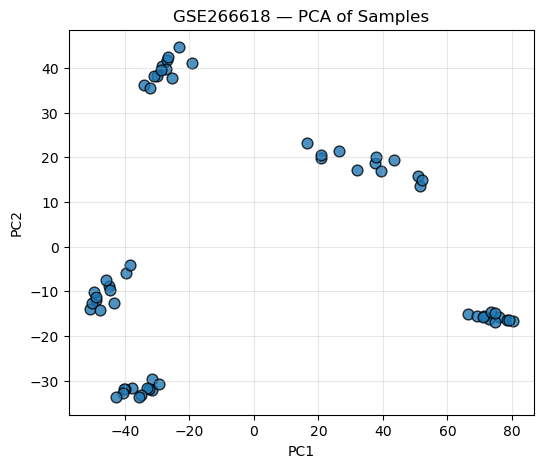

In [443]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=60, alpha=0.8, edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GSE266618 — PCA of Samples")
plt.grid(alpha=0.3)
plt.show()


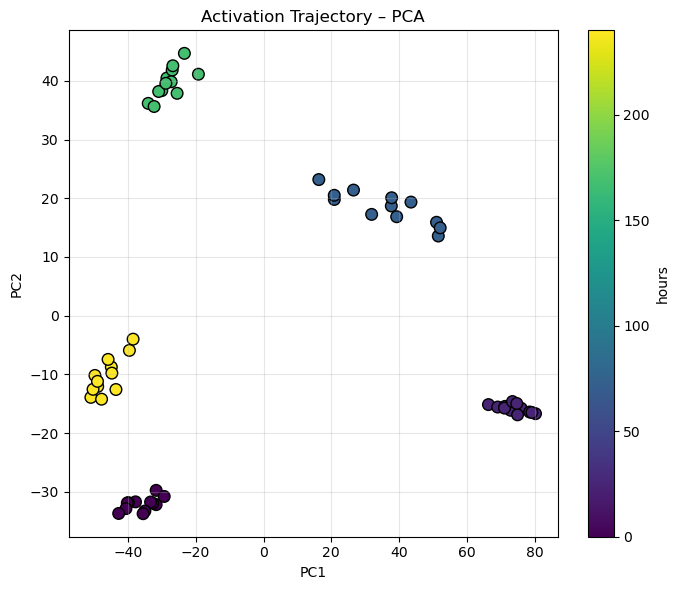

In [444]:
hours = metadata.loc[X.index, "hours"].values

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                 c=hours, cmap="viridis",
                 s=70, edgecolor="k")
plt.colorbar(sc, label="hours")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Activation Trajectory – PCA")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


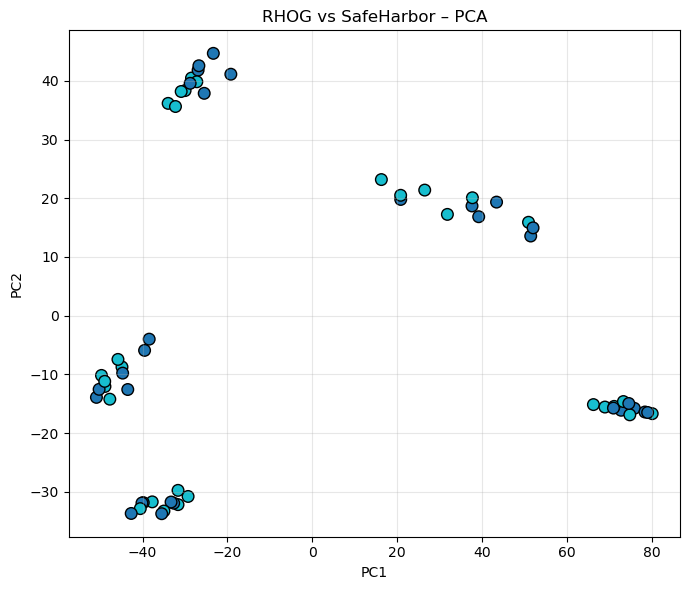

In [445]:
guides = metadata.loc[X.index, "guide"]
guide_to_int = {g:i for i,g in enumerate(sorted(guides.unique()))}
colors = [guide_to_int[g] for g in guides]

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=colors, cmap="tab10",
            s=70, edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("RHOG vs SafeHarbor – PCA")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [446]:
len(up_late), len(down_late)
enr_late_up.results.shape, enr_late_down.results.shape
up_late[:5]


['ENSG00000066056',
 'ENSG00000004468',
 'ENSG00000166016',
 'ENSG00000102962',
 'ENSG00000115523']

In [447]:
from gseapy import Biomart

bm = Biomart()

res = bm.query(
    dataset='hsapiens_gene_ensembl',
    attributes=['ensembl_gene_id', 'hgnc_symbol']
)

# Clean and make dict
res = (
    res
    .dropna(subset=['hgnc_symbol'])
    .drop_duplicates(subset=['ensembl_gene_id'])
)

ensg_to_symbol = res.set_index('ensembl_gene_id')['hgnc_symbol'].to_dict()
len(ensg_to_symbol)


46920

In [448]:
def ensg_list_to_symbols(gene_list, mapping):
    syms = [mapping.get(g) for g in gene_list]
    # drop missing / empty
    syms = [g for g in syms if isinstance(g, str) and g != ""]
    # remove duplicates but keep order
    return list(dict.fromkeys(syms))

up_late_sym   = ensg_list_to_symbols(up_late,   ensg_to_symbol)
down_late_sym = ensg_list_to_symbols(down_late, ensg_to_symbol)

len(up_late), len(up_late_sym), up_late_sym[:5]


(2521, 2373, ['TIE1', 'CD38', 'ABTB2', 'CCL22', 'GNLY'])

In [457]:
import gseapy as gp

enr_late_up = gp.enrichr(
    gene_list=up_late_sym,
    gene_sets=['MSigDB_Hallmark_2020'],
    organism='Human',
    outdir=None
)

enr_late_down = gp.enrichr(
    gene_list=down_late_sym,
    gene_sets=['MSigDB_Hallmark_2020'],
    organism='Human',
    outdir=None
)

enr_late_up.results.head()
enr_late_down.results.head()


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,E2F Targets,118/200,3.074139e-54,1.506328e-52,0,0,10.238305,1261.528788,DCLRE1B;POP7;TFRC;DSCC1;CSE1L;SMC6;MKI67;SMC4;...
1,MSigDB_Hallmark_2020,G2-M Checkpoint,93/200,9.049954e-32,2.217239e-30,0,0,6.112320,436.908419,TOP2A;H2AX;SUV39H1;AMD1;HNRNPU;HMGB3;KIF11;CTC...
2,MSigDB_Hallmark_2020,Myc Targets V1,84/200,4.902246e-25,8.007001e-24,0,0,5.071307,283.866081,YWHAE;EIF4A1;HSP90AB1;MCM7;HNRNPU;HNRNPR;PWP1;...
3,MSigDB_Hallmark_2020,Myc Targets V2,28/58,5.048585e-11,6.184517e-10,0,0,6.423399,152.294478,NIP7;NOLC1;NOC4L;TMEM97;RABEPK;RRP9;SRM;UNG;TC...
4,MSigDB_Hallmark_2020,mTORC1 Signaling,58/200,8.660743e-10,8.487528e-09,0,0,2.826479,58.980277,TES;TFRC;ARPC5L;SLC2A1;SLA;ATP2A2;TMEM97;ENO1;...


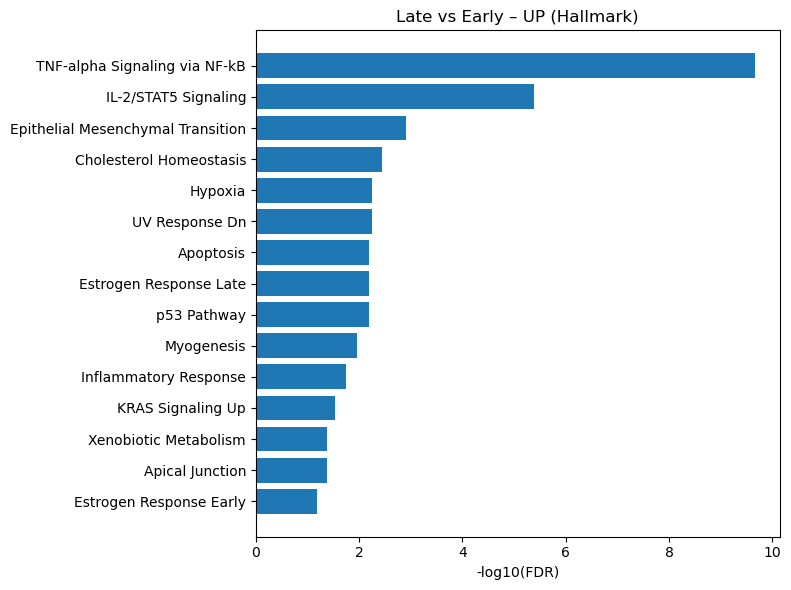

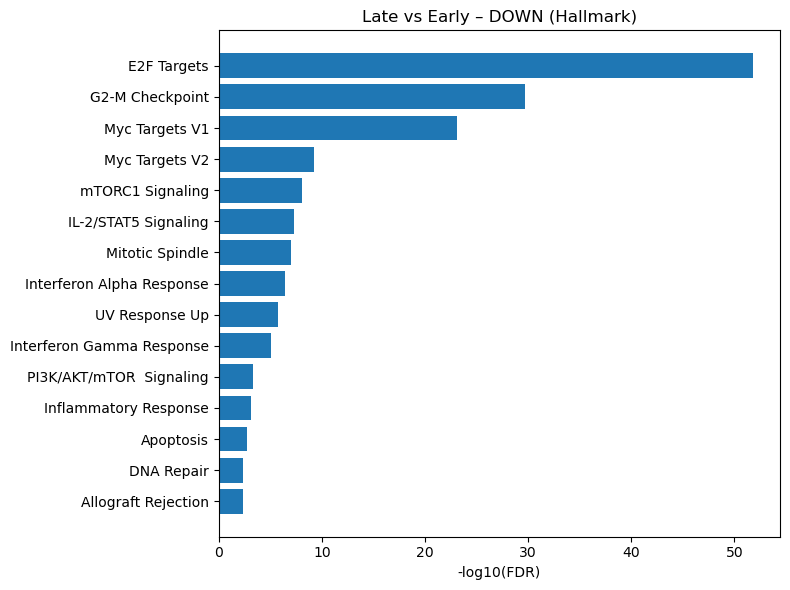

In [458]:
plot_top_terms(enr_late_up,   "Late vs Early – UP (Hallmark)")
plot_top_terms(enr_late_down, "Late vs Early – DOWN (Hallmark)")


In [459]:
annot_df = pd.DataFrame({
    "ensembl": list(ensg_to_symbol.keys()),
    "symbol": list(ensg_to_symbol.values())
})

os.makedirs("data/processed", exist_ok=True)
annot_df.to_csv("data/processed/ensg_to_symbol.csv", index=False)


In [460]:
annot_df = pd.read_csv("data/processed/ensg_to_symbol.csv")
ensg_to_symbol = annot_df.set_index("ensembl")["symbol"].to_dict()


In [461]:
df = de_late_vs_early.dropna(subset=["pval_adj"]).copy()


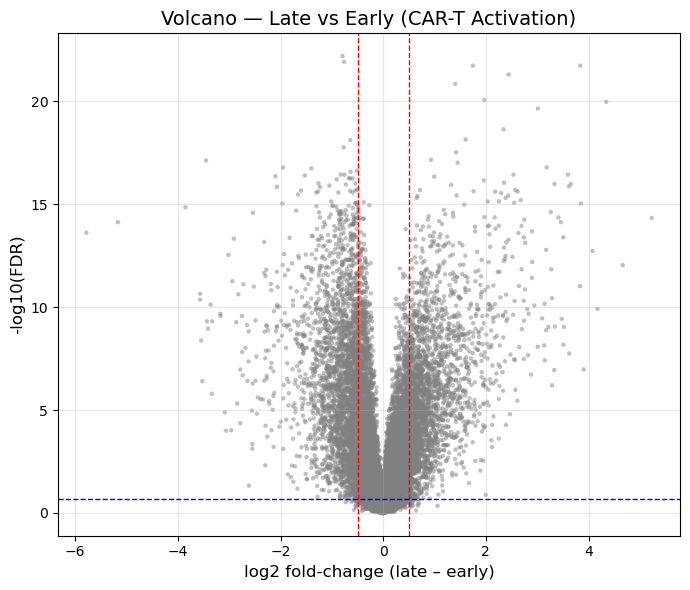

In [462]:
df = de_late_vs_early.dropna(subset=["pval_adj"]).copy()

# Coordinates
x = df["log2_fc"].values
y = -np.log10(df["pval_adj"].values + 1e-300)

plt.figure(figsize=(7, 6))
plt.scatter(
    x, y, 
    s=10, alpha=0.5, 
    c="gray", edgecolor="none"
)

# Thresholds
plt.axvline( 0.5, color="red", linestyle="--", linewidth=1)
plt.axvline(-0.5, color="red", linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.2), color="blue", linestyle="--", linewidth=1)

plt.xlabel("log2 fold-change (late – early)", fontsize=12)
plt.ylabel("-log10(FDR)", fontsize=12)
plt.title("Volcano — Late vs Early (CAR-T Activation)", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [463]:
# Only significant genes
sig = df[df["pval_adj"] <= 0.2]

# Strongest FC among significant
top = sig.reindex(
    sig["log2_fc"].abs().sort_values(ascending=False).head(15).index
)
top


,mean_early_0h,mean_late_168hplus,log2_fc,pval,pval_adj
gene,,,,,
ENSG00000164530,7.024783,1.240219,-5.784564,1.063724e-16,2.402808e-14
ENSG00000066056,1.385660,6.615974,5.230314,1.399128e-17,4.635310e-15
ENSG00000171246,6.627651,1.460437,-5.167214,2.531358e-17,7.399755e-15
ENSG00000004468,2.374784,7.038466,4.663682,8.041186e-15,9.005222e-13
ENSG00000166016,1.457309,5.801063,4.343754,2.134509e-24,1.060744e-20
ENSG00000102962,0.684304,4.857946,4.173642,2.429260e-12,1.214813e-10
ENSG00000115523,7.415668,11.491530,4.075862,1.283561e-15,1.869203e-13
ENSG00000118257,2.336634,6.240640,3.904005,6.232313e-09,1.074466e-07
ENSG00000120949,6.792085,2.939148,-3.852937,3.054377e-18,1.411974e-15


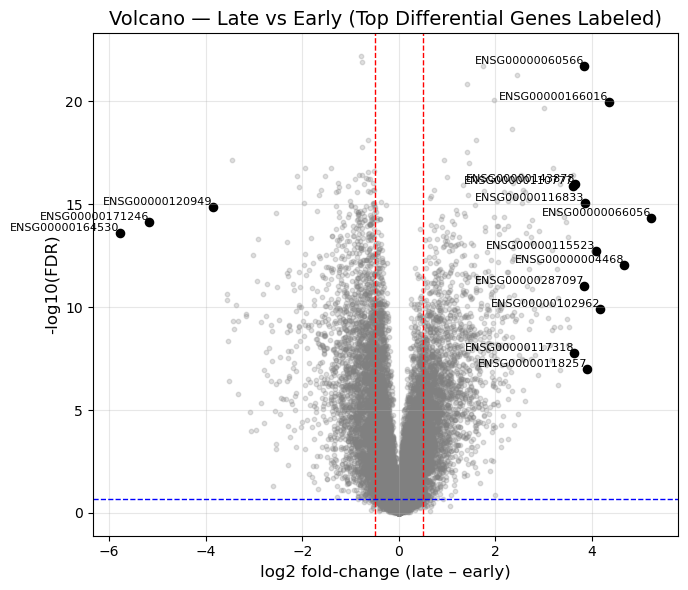

In [464]:
plt.figure(figsize=(7, 6))

# Background points
plt.scatter(x, y, s=10, alpha=0.25, color="gray")

# Thresholds
plt.axvline( 0.5, color="red", linestyle="--", linewidth=1)
plt.axvline(-0.5, color="red", linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.2), color="blue", linestyle="--", linewidth=1)

# Highlight top genes
for gene, row in top.iterrows():
    gx = row["log2_fc"]
    gy = -np.log10(row["pval_adj"] + 1e-300)
    plt.scatter(gx, gy, s=35, color="black")
    plt.text(gx, gy, gene, fontsize=8, ha="right", va="bottom")

plt.xlabel("log2 fold-change (late – early)", fontsize=12)
plt.ylabel("-log10(FDR)", fontsize=12)
plt.title("Volcano — Late vs Early (Top Differential Genes Labeled)", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [465]:
# Map ENSG → symbol, fall back to ENSG if missing
de_late_vs_early["symbol"] = [
    ensg_to_symbol.get(gene, gene)   # if no symbol, keep ENSG
    for gene in de_late_vs_early.index
]

de_late_vs_early[["log2_fc", "pval_adj", "symbol"]].head()


,log2_fc,pval_adj,symbol
gene,,,
ENSG00000223972,-0.005689,0.870327,DDX11L1
ENSG00000227232,0.203658,0.349364,WASH7P
ENSG00000278267,0.124411,0.075007,MIR6859-1
ENSG00000243485,-0.005163,0.862357,MIR1302-2HG
ENSG00000284332,0.000000,NaN,MIR1302-2


In [466]:
print(list(df.columns))

['mean_early_0h', 'mean_late_168hplus', 'log2_fc', 'pval', 'pval_adj']


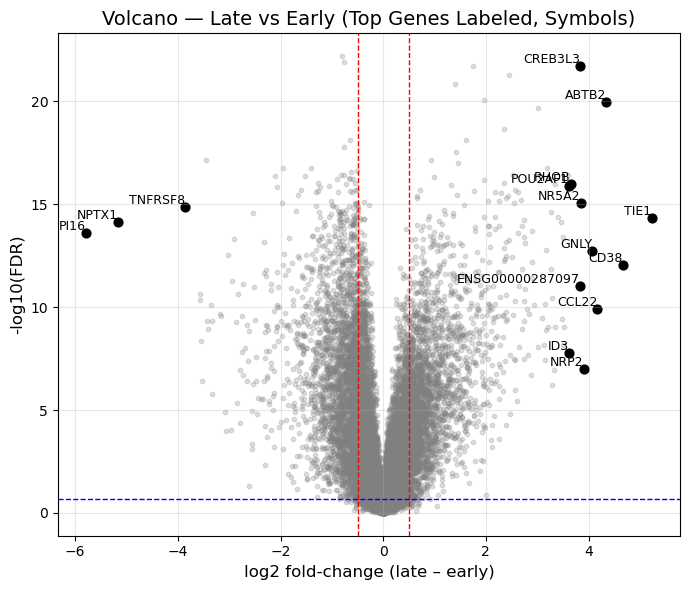

In [467]:
from pathlib import Path
df = de_late_vs_early.dropna(subset=["pval_adj"]).copy()

x = df["log2_fc"].values
y = -np.log10(df["pval_adj"].values + 1e-300)

plt.figure(figsize=(7, 6))
plt.scatter(x, y, s=10, alpha=0.25, color="gray")

plt.axvline( 0.5, color="red", linestyle="--", linewidth=1)
plt.axvline(-0.5, color="red", linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.2), color="blue", linestyle="--", linewidth=1)

sig = df[df["pval_adj"] <= 0.2]
top = sig.reindex(
    sig["log2_fc"].abs().sort_values(ascending=False).head(15).index
)

for gene, row in top.iterrows():
    gx = row["log2_fc"]
    gy = -np.log10(row["pval_adj"] + 1e-300)
    plt.scatter([gx], [gy], s=40, color="black")
    plt.text(
        gx, gy,
        row["symbol"],        # ← now shows TP53 / GZMB / etc.
        fontsize=9,
        ha="right", va="bottom"
    )

plt.xlabel("log2 fold-change (late – early)", fontsize=12)
plt.ylabel("-log10(FDR)", fontsize=12)
plt.title("Volcano — Late vs Early (Top Genes Labeled, Symbols)", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

outdir = Path("figures/fig3_DE_pathways")
outdir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    outdir / "Fig3C1_volcano_late_vs_early_labeled.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


In [468]:
de_late_vs_early_symbol = de_late_vs_early.copy()
de_late_vs_early_symbol.set_index("symbol", inplace=True)


Saved: figures/fig3_DE_pathways/Fig3C1_volcano_late_vs_early_colored_topLabeled.png


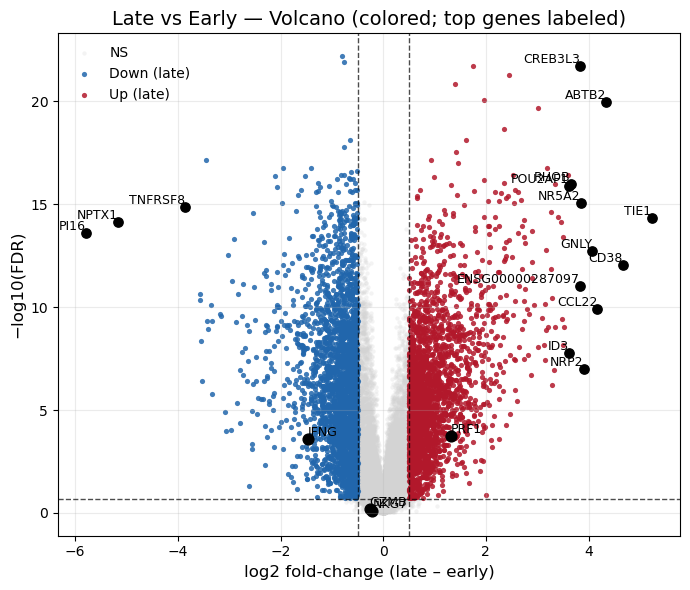

In [470]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

df = de_late_vs_early.dropna(subset=["pval_adj", "log2_fc"]).copy()

fc_thr  = 0.5
fdr_thr = 0.2
topN = 15

x = df["log2_fc"].values
y = -np.log10(df["pval_adj"].values + 1e-300)

# --- define categories for coloring ---
sig = (df["pval_adj"] <= fdr_thr) & (df["log2_fc"].abs() >= fc_thr)
up  = sig & (df["log2_fc"] >= fc_thr)
dn  = sig & (df["log2_fc"] <= -fc_thr)
ns  = ~sig

# --- create figure explicitly (so we can save it) ---
fig, ax = plt.subplots(figsize=(7, 6))

# background
ax.scatter(df.loc[ns, "log2_fc"], -np.log10(df.loc[ns, "pval_adj"] + 1e-300),
           s=10, alpha=0.25, color="lightgray", linewidths=0, label="NS")

# significant
ax.scatter(df.loc[dn, "log2_fc"], -np.log10(df.loc[dn, "pval_adj"] + 1e-300),
           s=14, alpha=0.85, color="#2166ac", linewidths=0, label="Down (late)")
ax.scatter(df.loc[up, "log2_fc"], -np.log10(df.loc[up, "pval_adj"] + 1e-300),
           s=14, alpha=0.85, color="#b2182b", linewidths=0, label="Up (late)")

# thresholds
ax.axvline( fc_thr, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(-fc_thr, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(-np.log10(fdr_thr), color="black", linestyle="--", linewidth=1, alpha=0.7)

# --- label only topN significant genes by |log2FC| (same logic as you had) ---
sig_df = df.loc[df["pval_adj"] <= fdr_thr].copy()
top = sig_df.reindex(sig_df["log2_fc"].abs().sort_values(ascending=False).head(topN).index)

for _, row in top.iterrows():
    gx = row["log2_fc"]
    gy = -np.log10(row["pval_adj"] + 1e-300)
    ax.scatter([gx], [gy], s=45, color="black", zorder=3)
    ax.text(gx, gy, str(row["symbol"]), fontsize=9, ha="right", va="bottom")

ax.set_xlabel("log2 fold-change (late – early)", fontsize=12)
ax.set_ylabel("−log10(FDR)", fontsize=12)
ax.set_title("Late vs Early — Volcano (colored; top genes labeled)", fontsize=14)
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
force_labels = {"GZMB", "IFNG", "PRF1", "NKG7"}

for gene, row in df.iterrows():
    if row["symbol"] in force_labels:
        plt.scatter(row["log2_fc"], -np.log10(row["pval_adj"]), s=60, color="black")
        plt.text(
            row["log2_fc"],
            -np.log10(row["pval_adj"]),
            row["symbol"],
            fontsize=9,
            ha="left",
            va="bottom",
        )

# --- save (this is the important part) ---
outdir = Path("figures/fig3_DE_pathways")
outdir.mkdir(parents=True, exist_ok=True)
outpath = outdir / "Fig3C1_volcano_late_vs_early_colored_topLabeled.png"
fig.savefig(outpath, dpi=300, bbox_inches="tight")
print("Saved:", outpath)

plt.show()

In [ ]:
de_late_vs_early = pd.read_csv("results/de_late_vs_early.csv", index_col=0)

In [474]:
from pathlib import Path

fc_thr  = 0.5
fdr_thr = 0.2

df = de_late_vs_early.dropna(subset=["pval_adj", "symbol"]).copy()

sig = df[
    (df["pval_adj"] <= fdr_thr) &
    (df["log2_fc"].abs() >= fc_thr)
].copy()

sig["direction"] = np.where(
    sig["log2_fc"] > 0, "Up (late)", "Down (late)"
)

sig = sig.sort_values("log2_fc", ascending=False)

up_genes   = sig[sig["direction"] == "Up (late)"]
down_genes = sig[sig["direction"] == "Down (late)"]

outdir = Path("figures/fig3_DE_pathways")
outdir.mkdir(parents=True, exist_ok=True)

up_genes[["symbol", "log2_fc", "pval_adj"]].to_csv(
    outdir / "Fig3C1_upregulated_genes_late_vs_early.csv",
    index=False
)

down_genes[["symbol", "log2_fc", "pval_adj"]].to_csv(
    outdir / "Fig3C1_downregulated_genes_late_vs_early.csv",
    index=False
)

print(f"Upregulated genes: {len(up_genes)}")
print(f"Downregulated genes: {len(down_genes)}")

Upregulated genes: 2521
Downregulated genes: 2669


In [475]:
from pathlib import Path

fc_thr  = 0.5
fdr_thr = 0.2

df = de_late_vs_early.copy()
df = df.dropna(subset=["pval_adj", "symbol"])

sig = df[
    (df["pval_adj"] <= fdr_thr) &
    (df["log2_fc"].abs() >= fc_thr)
].copy()

sig["direction"] = np.where(
    sig["log2_fc"] > 0, "Up (late)", "Down (late)"
)

# Order by effect size
sig = sig.sort_values("log2_fc", ascending=False)

# Split tables
up_genes   = sig[sig["direction"] == "Up (late)"]
down_genes = sig[sig["direction"] == "Down (late)"]

# Save
outdir = Path("figures/fig3_DE_pathways")
outdir.mkdir(parents=True, exist_ok=True)

up_genes[["symbol", "log2_fc", "pval_adj"]].to_csv(
    outdir / "Fig3C1_upregulated_genes_late_vs_early.csv",
    index=False
)

down_genes[["symbol", "log2_fc", "pval_adj"]].to_csv(
    outdir / "Fig3C1_downregulated_genes_late_vs_early.csv",
    index=False
)

In [476]:
from IPython.display import display

display(
    up_genes[["symbol", "log2_fc", "pval_adj"]]
    .head(20)
    .round(3)
)

,symbol,log2_fc,pval_adj
gene,,,
ENSG00000066056,TIE1,5.230,0.0
ENSG00000004468,CD38,4.664,0.0
ENSG00000166016,ABTB2,4.344,0.0
ENSG00000102962,CCL22,4.174,0.0
ENSG00000115523,GNLY,4.076,0.0
ENSG00000118257,NRP2,3.904,0.0
ENSG00000116833,NR5A2,3.849,0.0
ENSG00000060566,CREB3L3,3.839,0.0
ENSG00000287097,ENSG00000287097,3.834,0.0


In [477]:
display(
    down_genes[["symbol", "log2_fc", "pval_adj"]]
    .head(20)
    .round(3)
)

,symbol,log2_fc,pval_adj
gene,,,
ENSG00000186792,HYAL3,-0.500,0.083
ENSG00000168575,SLC20A2,-0.500,0.000
ENSG00000159363,ATP13A2,-0.501,0.000
ENSG00000178980,SELENOW,-0.501,0.000
ENSG00000148110,MFSD14B,-0.501,0.000
ENSG00000239789,MRPS17,-0.501,0.000
ENSG00000142347,MYO1F,-0.501,0.004
ENSG00000178075,GRAMD1C,-0.501,0.000
ENSG00000159792,PSKH1,-0.501,0.000


In [478]:
import matplotlib.pyplot as plt

def plot_gene_table(df, title, outpath, n=10):
    dfp = df[["symbol", "log2_fc", "pval_adj"]].head(n).copy()
    dfp["log2_fc"]  = dfp["log2_fc"].round(2)
    dfp["pval_adj"] = dfp["pval_adj"].apply(lambda x: f"{x:.2e}")

    fig, ax = plt.subplots(figsize=(6, 0.4 * (n + 2)))
    ax.axis("off")

    table = ax.table(
        cellText=dfp.values,
        colLabels=dfp.columns,
        loc="center",
        cellLoc="left"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.3)

    ax.set_title(title, fontsize=12, pad=10)
    fig.tight_layout()
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close(fig)

In [480]:
plot_gene_table(
    up_genes.sort_values("log2_fc", ascending=False),
    title="Top up-regulated genes (Late vs Early)",
    outpath="figures/fig3_DE_pathways/Fig3C1_up_genes_table.png"
)

plot_gene_table(
    down_genes.sort_values("log2_fc"),
    title="Top down-regulated genes (Late vs Early)",
    outpath="figures/fig3_DE_pathways/Fig3C1_down_genes_table.png"
)

In [300]:
#Helper: get genes from a Hallmark term and plot heatmap
import numpy as np
import matplotlib.pyplot as plt

def get_hallmark_genes(enr_results, term):
    """Return list of gene symbols for a specific Hallmark term."""
    row = enr_results.results.set_index("Term").loc[term]
    genes_str = row["Genes"]
    genes = genes_str.split(";")
    return genes

def plot_hallmark_heatmap(term, enr_results, expr_symbol, metadata,
                          zscore_rows=True, figsize=(10, 8),
                          title_suffix=""):
    # 1) Get Hallmark gene symbols
    genes = get_hallmark_genes(enr_results, term)
    
    # 2) Keep only genes that exist in expression matrix
    genes_present = [g for g in genes if g in expr_symbol.index]
    if len(genes_present) == 0:
        print(f"No genes from {term} found in expression matrix.")
        return
    
    # 3) Order samples by time (hours)
    order = metadata.sort_values("hours").index
    X = expr_symbol.loc[genes_present, order]
    
    # 4) Row-wise z-score (per gene) to show patterns
    if zscore_rows:
        mu = X.mean(axis=1).values[:, None]
        sd = X.std(axis=1).values[:, None] + 1e-9
        X_plot = (X - mu) / sd
    else:
        X_plot = X
    
    # 5) Make heatmap
    plt.figure(figsize=figsize)
    im = plt.imshow(X_plot, aspect="auto", interpolation="nearest")
    plt.colorbar(im, label="Z-score (per gene)" if zscore_rows else "log2CPM")
    
    # Y-axis = gene symbols
    plt.yticks(range(len(genes_present)), genes_present, fontsize=6)
    
    # X-axis = time (hours)
    plt.xticks(
        range(len(order)),
        metadata.loc[order, "hours"].astype(str).values,
        rotation=90,
        fontsize=6
    )
    
    plt.title(f"{term} – expression across time {title_suffix}")
    plt.tight_layout()
    plt.show()


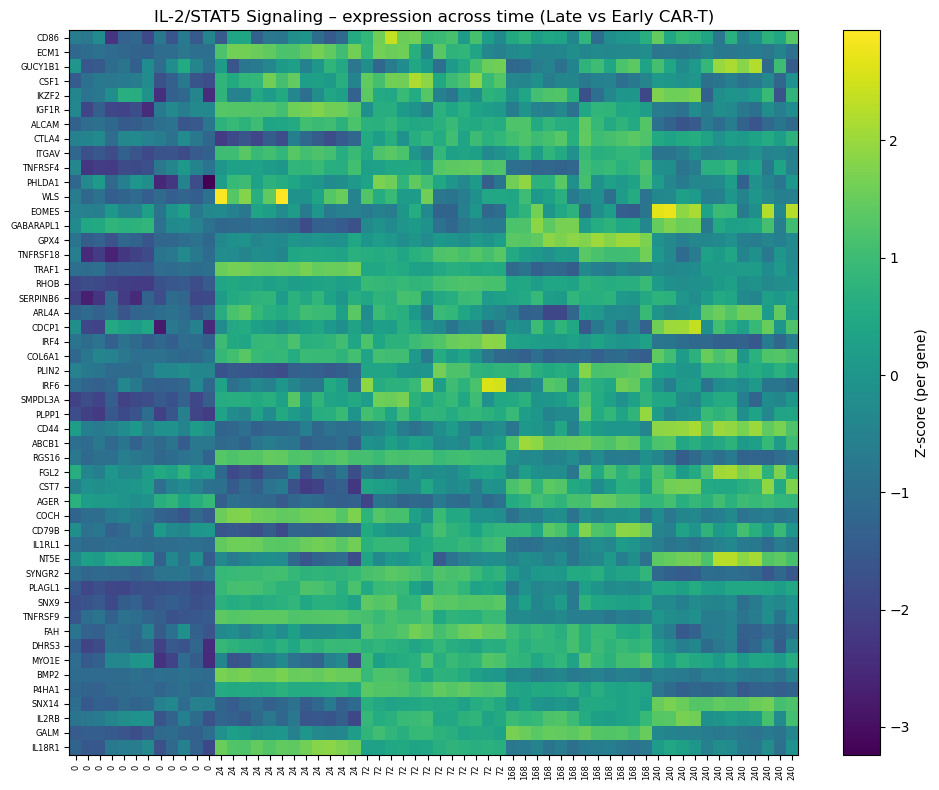

In [301]:
plot_hallmark_heatmap(
    term="IL-2/STAT5 Signaling",
    enr_results=enr_late_up,
    expr_symbol=expr_symbol,
    metadata=metadata,
    title_suffix="(Late vs Early CAR-T)"
)


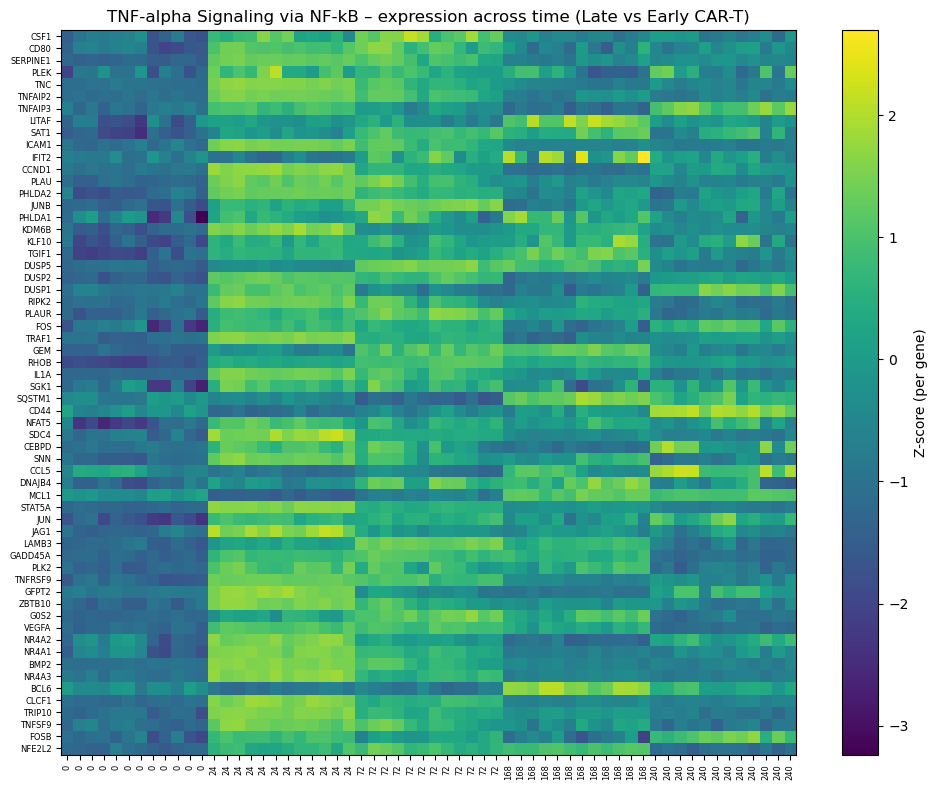

In [302]:
plot_hallmark_heatmap(
    term="TNF-alpha Signaling via NF-kB",
    enr_results=enr_late_up,
    expr_symbol=expr_symbol,
    metadata=metadata,
    title_suffix="(Late vs Early CAR-T)"
)


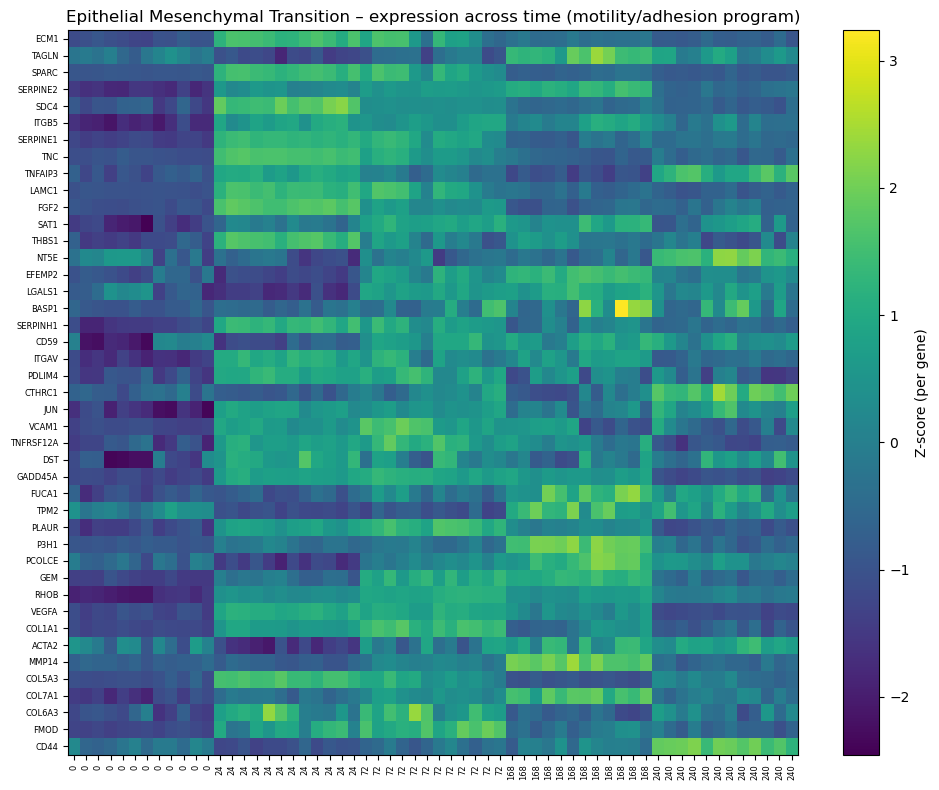

In [303]:
plot_hallmark_heatmap(
    term="Epithelial Mesenchymal Transition",
    enr_results=enr_late_up,
    expr_symbol=expr_symbol,
    metadata=metadata,
    title_suffix="(motility/adhesion program)"
)


In [304]:
def plot_hallmark_heatmap(
    term,
    enr_results,
    expr_symbol,
    metadata,
    subset_mask=None,       # optional: CD4-only, CD8-only, donor filter, etc.
    zscore_rows=True,
    figsize=(10,8),
    title_suffix=""
):
    """
    Plot a Hallmark gene-set heatmap across samples ordered by time.
    """

    # 1) Get Hallmark genes
    row = enr_results.results.set_index("Term").loc[term]
    genes = row["Genes"].split(";")

    # 2) Keep only genes available in the expression matrix
    genes_present = [g for g in genes if g in expr_symbol.index]
    if len(genes_present) == 0:
        print(f"No genes from {term} found in matrix.")
        return

    # 3) Choose sample ordering (with optional subset)
    if subset_mask is not None:
        order = metadata[subset_mask].sort_values("hours").index
    else:
        order = metadata.sort_values("hours").index

    X = expr_symbol.loc[genes_present, order]

    # 4) Z-score rows
    if zscore_rows:
        mu = X.mean(axis=1).values[:, None]
        sd = X.std(axis=1).values[:, None] + 1e-9
        Xz = (X - mu) / sd
    else:
        Xz = X

    # 5) Plot heatmap
    plt.figure(figsize=figsize)
    im = plt.imshow(Xz, aspect="auto", interpolation="nearest")
    plt.colorbar(im, label="Z-score (per gene)" if zscore_rows else "log2CPM")

    plt.yticks(range(len(genes_present)), genes_present, fontsize=6)
    plt.xticks(
        range(len(order)),
        metadata.loc[order, "hours"].astype(str).values,
        fontsize=6,
        rotation=90
    )

    plt.title(f"{term} – expression across time {title_suffix}")
    plt.tight_layout()
    plt.show()


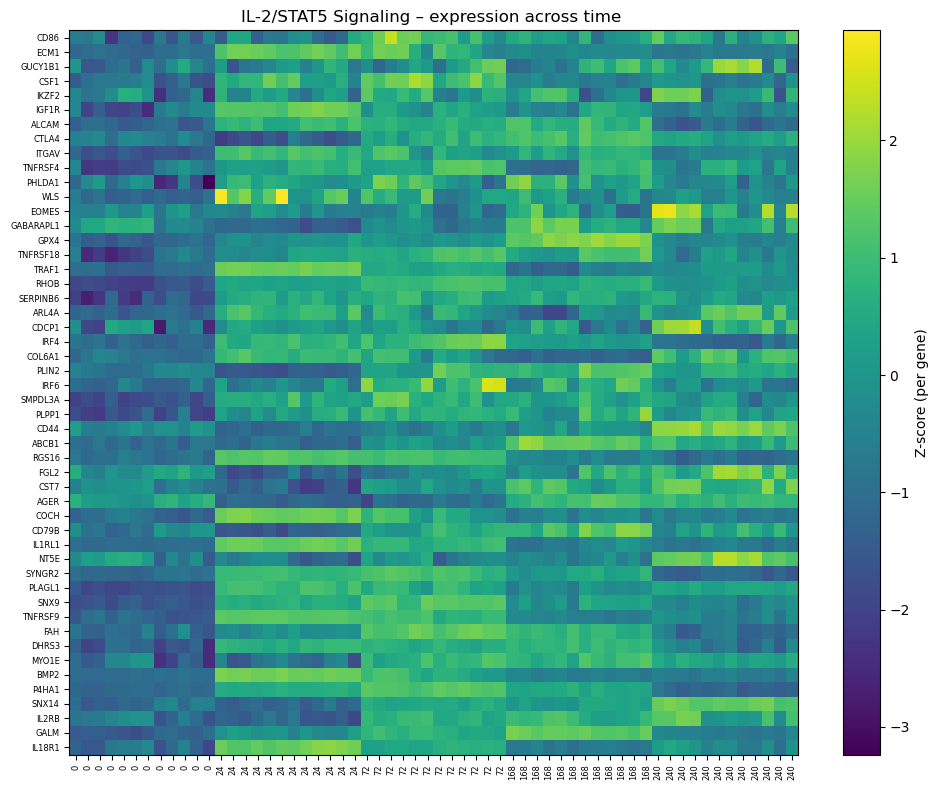

In [305]:
plot_hallmark_heatmap(
    "IL-2/STAT5 Signaling", enr_late_up, expr_symbol, metadata
)


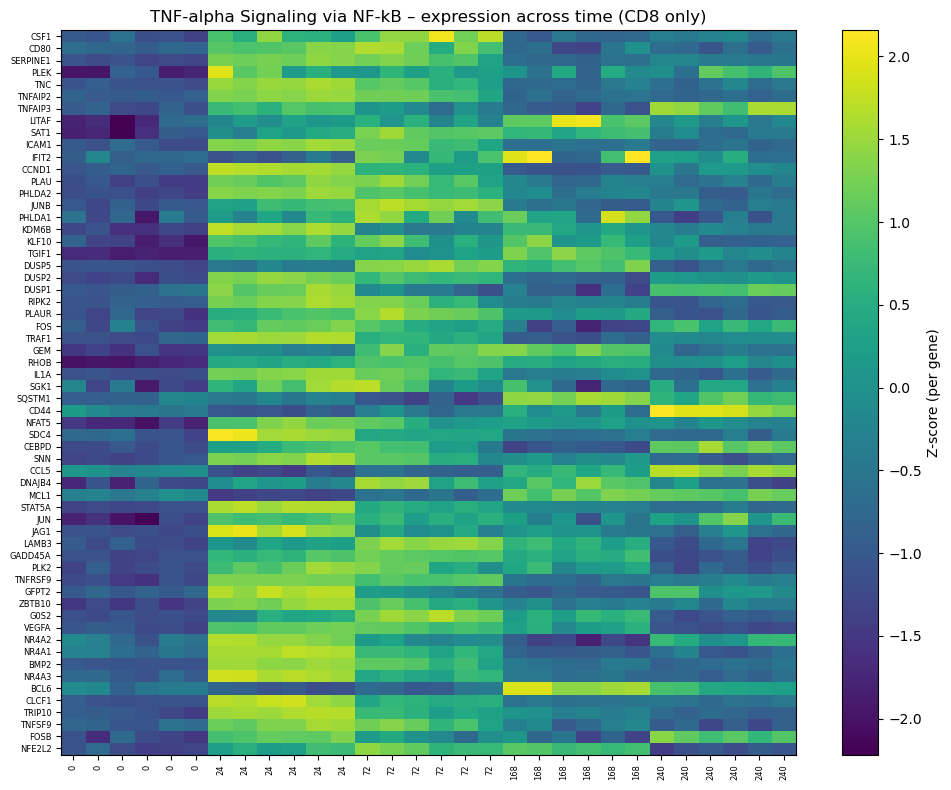

In [306]:
subset_cd8 = metadata["cell_type"] == "CD8"

plot_hallmark_heatmap(
    "TNF-alpha Signaling via NF-kB",
    enr_late_up,
    expr_symbol,
    metadata,
    subset_mask=subset_cd8,
    title_suffix="(CD8 only)"
)


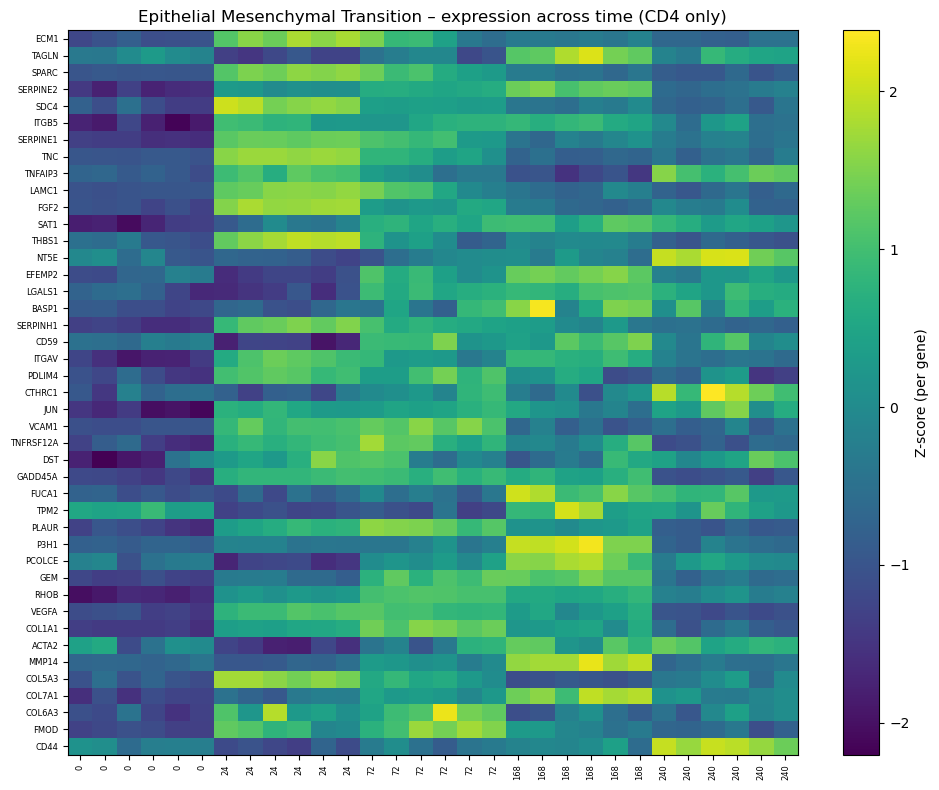

In [307]:
subset_cd4 = metadata["cell_type"] == "CD4"

plot_hallmark_heatmap(
    "Epithelial Mesenchymal Transition",
    enr_late_up,
    expr_symbol,
    metadata,
    subset_mask=subset_cd4,
    title_suffix="(CD4 only)"
)


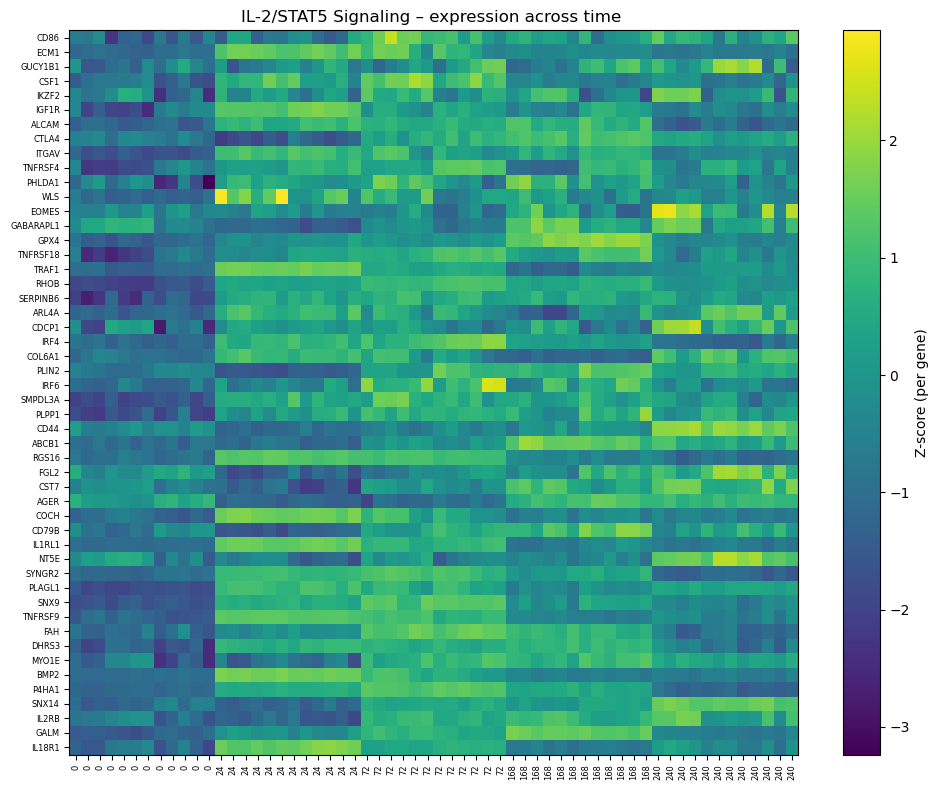

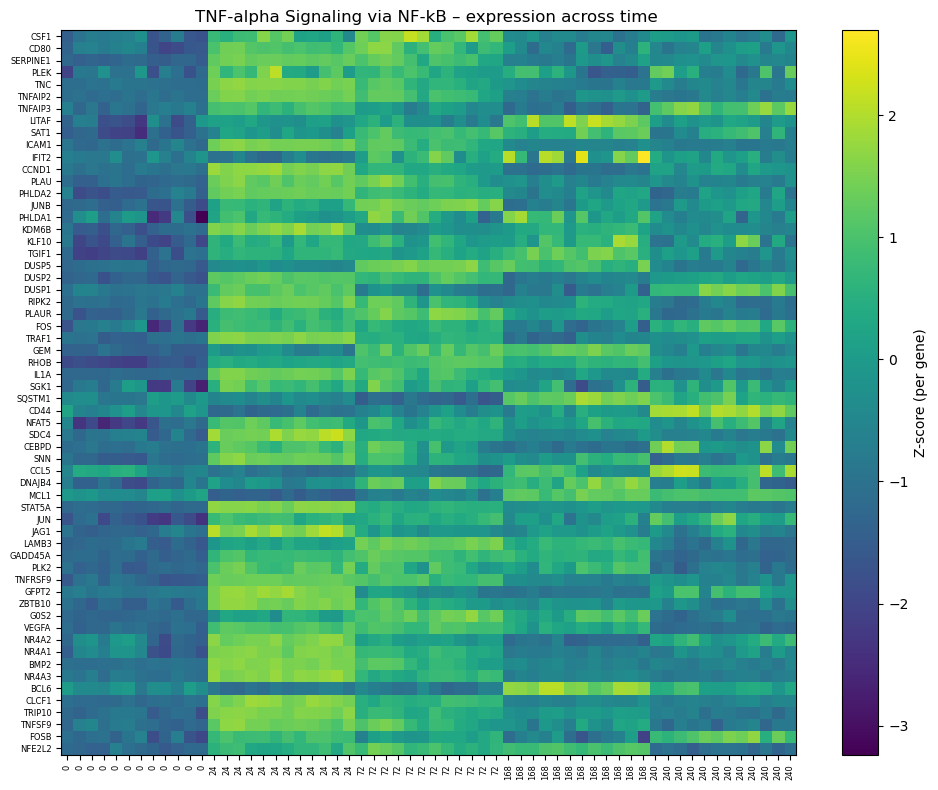

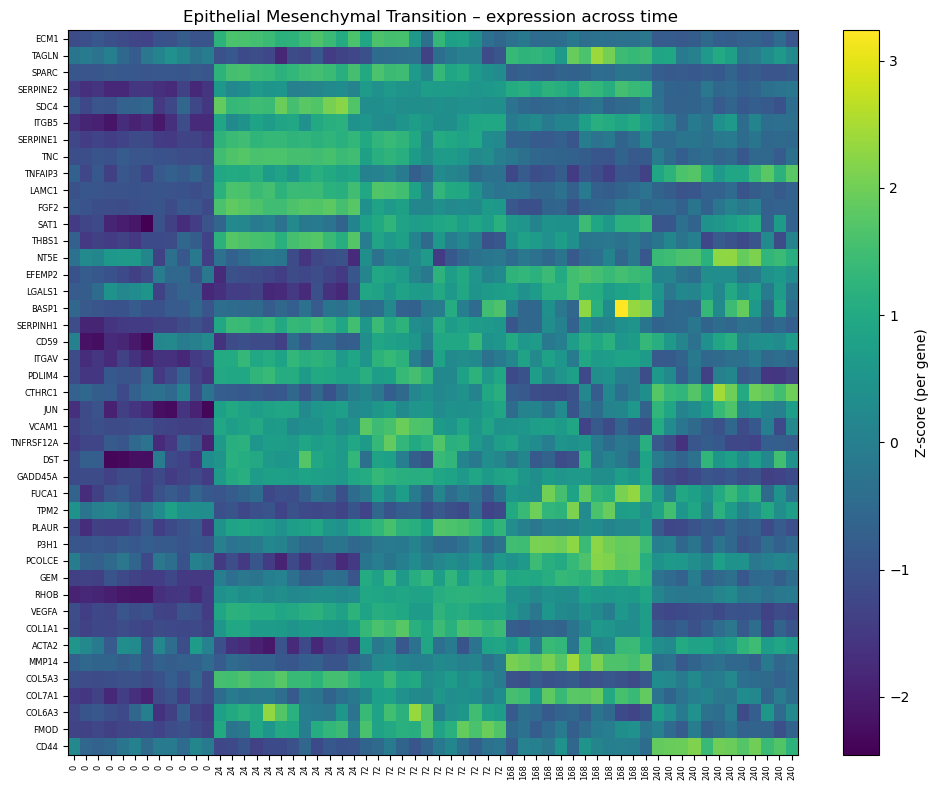

In [308]:
plot_hallmark_heatmap("IL-2/STAT5 Signaling", enr_late_up, expr_symbol, metadata)
plot_hallmark_heatmap("TNF-alpha Signaling via NF-kB", enr_late_up, expr_symbol, metadata)
plot_hallmark_heatmap("Epithelial Mesenchymal Transition", enr_late_up, expr_symbol, metadata)


In [309]:
# 1) Add symbol column to RHOG DE table (same trick as before)
de_rhog_vs_safe_0h["symbol"] = [
    ensg_to_symbol.get(gene, gene) for gene in de_rhog_vs_safe_0h.index
]

# 2) Collapse any duplicated symbols by mean log2_fc
rnk_rhog_series = (
    de_rhog_vs_safe_0h
    .groupby("symbol")["log2_fc"]
    .mean()
    .sort_values(ascending=False)
)

# 3) Convert to the (gene, score) DataFrame format GSEApy likes
rnk_rhog = (
    rnk_rhog_series
    .reset_index()
    .rename(columns={"symbol": "gene", "log2_fc": "score"})
)

rnk_rhog.head(), rnk_rhog.shape


(         gene     score
 0        RORC  0.822264
 1  MIR124-1HG  0.736751
 2       EPAS1  0.578619
 3       FMNL2  0.528122
 4       EPHA4  0.514611,
 (60656, 2))

In [310]:
# Reindex by Term so the index is the gene-set name
res_terms = gsea_rhog.res2d.set_index("Term")
res_terms.head()


NameError: name 'gsea_rhog' is not defined

In [311]:
gsea_rhog.res2d.head()
list(gsea_rhog.res2d.columns)


NameError: name 'gsea_rhog' is not defined

In [312]:
cols = list(gsea_rhog.res2d.columns)
print("Columns:", cols)

# Try to find the FDR-like column automatically
fdr_candidates = [c for c in cols if "fdr" in c.lower()]
print("FDR candidates:", fdr_candidates)

fdr_col = fdr_candidates[0]  # take the first match
print("Using FDR column:", fdr_col)

gsea_rhog.res2d.sort_values(fdr_col).head(15)


NameError: name 'gsea_rhog' is not defined

In [313]:
# Example if the column name turns out to be exactly "fdr
gsea_rhog.res2d.sort_values(['Name',
 'Term',
 'ES',
 'NES',
 'NOM p-val',
 'FDR q-val',
 'FWER p-val',
 'Tag %',
 'Gene %',
 'Lead_genes']).head(15)


NameError: name 'gsea_rhog' is not defined

In [314]:
# 1) Add symbol column to RHOG DE table
de_rhog_vs_safe_0h["symbol"] = [
    ensg_to_symbol.get(g, g) for g in de_rhog_vs_safe_0h.index
]

# 2) Collapse duplicates by symbol, take mean log2_fc
rnk_rhog_series = (
    de_rhog_vs_safe_0h
    .groupby("symbol")["log2_fc"]
    .mean()
    .sort_values(ascending=False)
)

# 3) Convert to (gene, score) DataFrame
rnk_rhog = (
    rnk_rhog_series
    .reset_index()
    .rename(columns={"symbol": "gene", "log2_fc": "score"})
)


In [315]:
import gseapy as gp

gsea_rhog = gp.prerank(
    rnk=rnk_rhog,
    gene_sets="MSigDB_Hallmark_2020",
    min_size=10,
    max_size=5000,
    outdir=None
)


2025-12-18 14:43:45,255 [WARNING] Duplicated values found in preranked stats: 55.26% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [316]:
# Reindex by Term so the index holds the pathway name
res_terms = gsea_rhog.res2d.set_index("Term")
res_terms.head()


,Name,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
Term,,,,,,,,,
E2F Targets,prerank,-0.76804,-2.152391,0.0,0.0,0.0,150/200,11.55%,NME1;CDKN1A;CDC25A;MTHFD2;TIPIN;CCNE1;ORC6;CTP...
G2-M Checkpoint,prerank,-0.761105,-2.131521,0.0,0.0,0.0,133/199,11.39%,MT2A;SLC7A5;DMD;CDC25A;MARCKS;CDC45;ORC6;EXO1;...
mTORC1 Signaling,prerank,-0.746679,-2.087565,0.0,0.0,0.0,130/199,11.42%,SLC7A11;SLC7A5;BCAT1;AK4;CDKN1A;CDC25A;MTHFD2;...
Myc Targets V1,prerank,-0.702462,-1.948816,0.0,0.0,0.0,123/199,11.08%,NME1;CDC45;CTPS1;MCM2;CDK4;HSP90AB1;RANBP1;RFC...
Myc Targets V2,prerank,-0.781683,-1.865339,0.0,0.0,0.0,43/57,10.06%,DUSP2;RRP12;HK2;MRTO4;PRMT3;CDK4;HSPD1;RRP9;SU...


In [317]:
list(res_terms.index[:10])


['E2F Targets',
 'G2-M Checkpoint',
 'mTORC1 Signaling',
 'Myc Targets V1',
 'Myc Targets V2',
 'TNF-alpha Signaling via NF-kB',
 'IL-6/JAK/STAT3 Signaling',
 'IL-2/STAT5 Signaling',
 'Inflammatory Response',
 'Unfolded Protein Response']

In [318]:
list(gsea_rhog.res2d.columns)


['Name',
 'Term',
 'ES',
 'NES',
 'NOM p-val',
 'FDR q-val',
 'FWER p-val',
 'Tag %',
 'Gene %',
 'Lead_genes']

In [319]:
gsea_rhog.res2d.sort_values("FDR q-val").head(15)



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,-0.76804,-2.152391,0.0,0.0,0.0,150/200,11.55%,NME1;CDKN1A;CDC25A;MTHFD2;TIPIN;CCNE1;ORC6;CTP...
1,prerank,G2-M Checkpoint,-0.761105,-2.131521,0.0,0.0,0.0,133/199,11.39%,MT2A;SLC7A5;DMD;CDC25A;MARCKS;CDC45;ORC6;EXO1;...
2,prerank,mTORC1 Signaling,-0.746679,-2.087565,0.0,0.0,0.0,130/199,11.42%,SLC7A11;SLC7A5;BCAT1;AK4;CDKN1A;CDC25A;MTHFD2;...
3,prerank,Myc Targets V1,-0.702462,-1.948816,0.0,0.0,0.0,123/199,11.08%,NME1;CDC45;CTPS1;MCM2;CDK4;HSP90AB1;RANBP1;RFC...
4,prerank,Myc Targets V2,-0.781683,-1.865339,0.0,0.0,0.0,43/57,10.06%,DUSP2;RRP12;HK2;MRTO4;PRMT3;CDK4;HSPD1;RRP9;SU...
5,prerank,TNF-alpha Signaling via NF-kB,-0.655884,-1.835051,0.0,0.0,0.0,90/198,6.79%,EGR3;CSF2;FOS;CCL4;SGK1;PTGS2;TRIB1;EGR1;SOCS3...
6,prerank,IL-6/JAK/STAT3 Signaling,-0.710276,-1.75931,0.0,0.000411,0.001,25/87,5.77%,CSF2RB;CSF2;CCR1;HMOX1;IL17RB;SOCS3;TNF;CSF1;I...
7,prerank,IL-2/STAT5 Signaling,-0.62157,-1.749333,0.0,0.000718,0.002,86/198,6.70%,NRP1;CSF2;IL13;ETV4;TNFRSF18;CKAP4;CTLA4;MYO1E...
8,prerank,Inflammatory Response,-0.615785,-1.716199,0.0,0.001597,0.005,62/200,5.55%,CCL22;CHST2;PTGIR;LTA;ICAM1;HBEGF;SERPINE1;IRA...
11,prerank,Allograft Rejection,-0.597793,-1.658202,0.0,0.002155,0.009,78/200,9.17%,CCR1;CCL22;IL13;CRTAM;GZMB;CCL4;ICAM1;FASLG;IF...


In [320]:
# Sort by FDR
res_sorted = gsea_rhog.res2d.sort_values("FDR q-val")

# Look at the top few rows to sanity check
res_sorted.head(5)


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,-0.76804,-2.152391,0.0,0.0,0.0,150/200,11.55%,NME1;CDKN1A;CDC25A;MTHFD2;TIPIN;CCNE1;ORC6;CTP...
1,prerank,G2-M Checkpoint,-0.761105,-2.131521,0.0,0.0,0.0,133/199,11.39%,MT2A;SLC7A5;DMD;CDC25A;MARCKS;CDC45;ORC6;EXO1;...
2,prerank,mTORC1 Signaling,-0.746679,-2.087565,0.0,0.0,0.0,130/199,11.42%,SLC7A11;SLC7A5;BCAT1;AK4;CDKN1A;CDC25A;MTHFD2;...
3,prerank,Myc Targets V1,-0.702462,-1.948816,0.0,0.0,0.0,123/199,11.08%,NME1;CDC45;CTPS1;MCM2;CDK4;HSP90AB1;RANBP1;RFC...
4,prerank,Myc Targets V2,-0.781683,-1.865339,0.0,0.0,0.0,43/57,10.06%,DUSP2;RRP12;HK2;MRTO4;PRMT3;CDK4;HSPD1;RRP9;SU...


In [321]:
# Take the first row
best_row = res_sorted.iloc[0]

# The term name is stored in the "Term" column
best_term = best_row["Term"]
best_term


'E2F Targets'

In [322]:
list(gsea_rhog.results.keys())[:10]


['UV Response Dn',
 'Reactive Oxygen Species Pathway',
 'Wnt-beta Catenin Signaling',
 'Adipogenesis',
 'TNF-alpha Signaling via NF-kB',
 'Complement',
 'Fatty Acid Metabolism',
 'PI3K/AKT/mTOR  Signaling',
 'KRAS Signaling Dn',
 'heme Metabolism']

In [323]:
best_term = best_row["Name"]


In [324]:
gsea_rhog.res2d.head()


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,-0.76804,-2.152391,0.0,0.0,0.0,150/200,11.55%,NME1;CDKN1A;CDC25A;MTHFD2;TIPIN;CCNE1;ORC6;CTP...
1,prerank,G2-M Checkpoint,-0.761105,-2.131521,0.0,0.0,0.0,133/199,11.39%,MT2A;SLC7A5;DMD;CDC25A;MARCKS;CDC45;ORC6;EXO1;...
2,prerank,mTORC1 Signaling,-0.746679,-2.087565,0.0,0.0,0.0,130/199,11.42%,SLC7A11;SLC7A5;BCAT1;AK4;CDKN1A;CDC25A;MTHFD2;...
3,prerank,Myc Targets V1,-0.702462,-1.948816,0.0,0.0,0.0,123/199,11.08%,NME1;CDC45;CTPS1;MCM2;CDK4;HSP90AB1;RANBP1;RFC...
4,prerank,Myc Targets V2,-0.781683,-1.865339,0.0,0.0,0.0,43/57,10.06%,DUSP2;RRP12;HK2;MRTO4;PRMT3;CDK4;HSPD1;RRP9;SU...


In [325]:
# Sort by FDR
res_sorted = gsea_rhog.res2d.sort_values("FDR q-val")

# Check top few
res_sorted.head()


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,-0.76804,-2.152391,0.0,0.0,0.0,150/200,11.55%,NME1;CDKN1A;CDC25A;MTHFD2;TIPIN;CCNE1;ORC6;CTP...
1,prerank,G2-M Checkpoint,-0.761105,-2.131521,0.0,0.0,0.0,133/199,11.39%,MT2A;SLC7A5;DMD;CDC25A;MARCKS;CDC45;ORC6;EXO1;...
2,prerank,mTORC1 Signaling,-0.746679,-2.087565,0.0,0.0,0.0,130/199,11.42%,SLC7A11;SLC7A5;BCAT1;AK4;CDKN1A;CDC25A;MTHFD2;...
3,prerank,Myc Targets V1,-0.702462,-1.948816,0.0,0.0,0.0,123/199,11.08%,NME1;CDC45;CTPS1;MCM2;CDK4;HSP90AB1;RANBP1;RFC...
4,prerank,Myc Targets V2,-0.781683,-1.865339,0.0,0.0,0.0,43/57,10.06%,DUSP2;RRP12;HK2;MRTO4;PRMT3;CDK4;HSPD1;RRP9;SU...


In [326]:
best_term = res_sorted.index[0]   # this is something like 'HALLMARK_TNFA_SIGNALING_VIA_NFKB'
best_term


np.int64(0)

In [327]:
best_term = res_sorted.iloc[0]["Term"]


In [328]:
from gseapy.plot import gseaplot


[<Axes: xlabel='Gene Rank', ylabel='Ranked metric'>,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>]

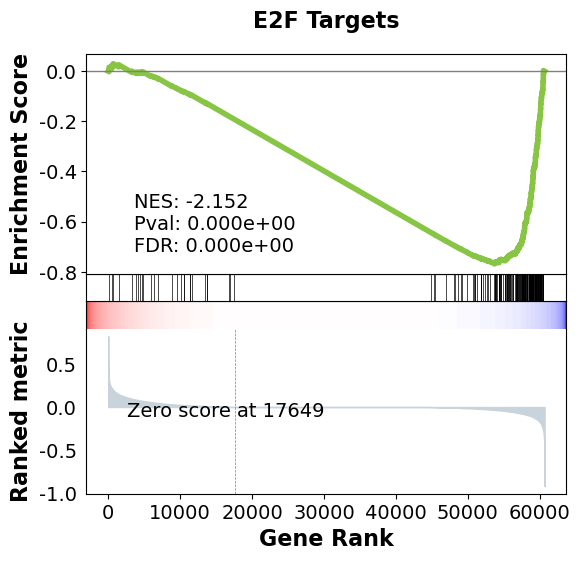

In [329]:
gseaplot(
    rank_metric=gsea_rhog.ranking,
    term=best_term,
    **gsea_rhog.results[best_term]
)


In [330]:
# Reindex by Term so the index is the gene-set name
res_terms = gsea_rhog.res2d.set_index("Term")
res_terms.head()


,Name,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
Term,,,,,,,,,
E2F Targets,prerank,-0.76804,-2.152391,0.0,0.0,0.0,150/200,11.55%,NME1;CDKN1A;CDC25A;MTHFD2;TIPIN;CCNE1;ORC6;CTP...
G2-M Checkpoint,prerank,-0.761105,-2.131521,0.0,0.0,0.0,133/199,11.39%,MT2A;SLC7A5;DMD;CDC25A;MARCKS;CDC45;ORC6;EXO1;...
mTORC1 Signaling,prerank,-0.746679,-2.087565,0.0,0.0,0.0,130/199,11.42%,SLC7A11;SLC7A5;BCAT1;AK4;CDKN1A;CDC25A;MTHFD2;...
Myc Targets V1,prerank,-0.702462,-1.948816,0.0,0.0,0.0,123/199,11.08%,NME1;CDC45;CTPS1;MCM2;CDK4;HSP90AB1;RANBP1;RFC...
Myc Targets V2,prerank,-0.781683,-1.865339,0.0,0.0,0.0,43/57,10.06%,DUSP2;RRP12;HK2;MRTO4;PRMT3;CDK4;HSPD1;RRP9;SU...


In [331]:
list(res_terms.index[:10])


['E2F Targets',
 'G2-M Checkpoint',
 'mTORC1 Signaling',
 'Myc Targets V1',
 'Myc Targets V2',
 'TNF-alpha Signaling via NF-kB',
 'IL-6/JAK/STAT3 Signaling',
 'IL-2/STAT5 Signaling',
 'Inflammatory Response',
 'Unfolded Protein Response']

In [332]:
def find_terms(pattern):
    pattern = pattern.lower()
    return [t for t in res_terms.index if pattern in t.lower()]

print("TNF-like terms:", find_terms("tnf"))
print("nf-kb-like terms:", find_terms("nf-kb"))
print("IL2/STAT5-like terms:", find_terms("stat5"))
print("IFN-like terms:", find_terms("interferon"))
print("apoptosis-like terms:", find_terms("apoptosis"))


TNF-like terms: ['TNF-alpha Signaling via NF-kB']
nf-kb-like terms: ['TNF-alpha Signaling via NF-kB']
IL2/STAT5-like terms: ['IL-2/STAT5 Signaling']
IFN-like terms: ['Interferon Gamma Response', 'Interferon Alpha Response']
apoptosis-like terms: ['Apoptosis']



=== TNF-alpha Signaling via NF-kB ===
NES: -1.8350506865060423  | FDR q-val: 0.0

=== IL-2/STAT5 Signaling ===
NES: -1.7493328327035125  | FDR q-val: 0.0007184825648230937

=== Interferon Gamma Response ===
NES: -1.6687775804696903  | FDR q-val: 0.0023513974848755792

=== Inflammatory Response ===
NES: -1.716198982842265  | FDR q-val: 0.0015966279218290968

=== Apoptosis ===
NES: -1.206355105951115  | FDR q-val: 0.1453387588270715


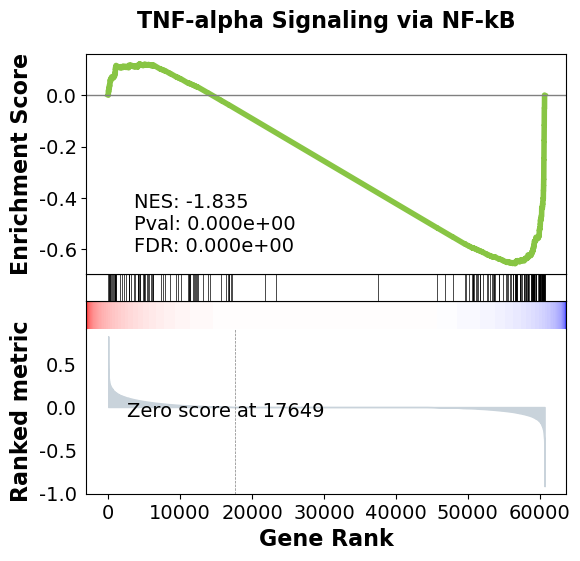

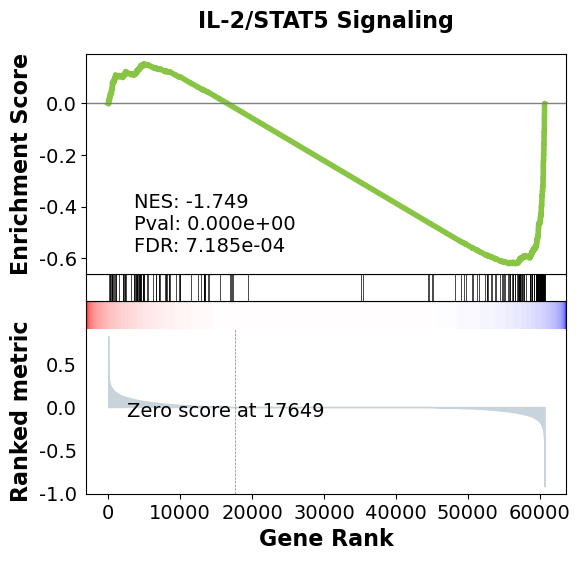

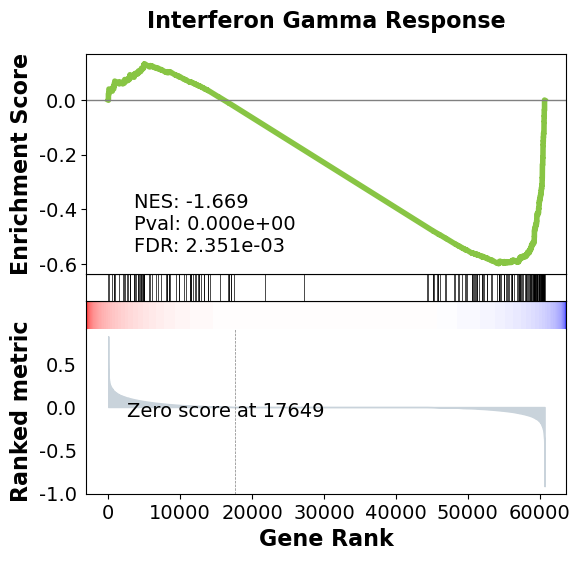

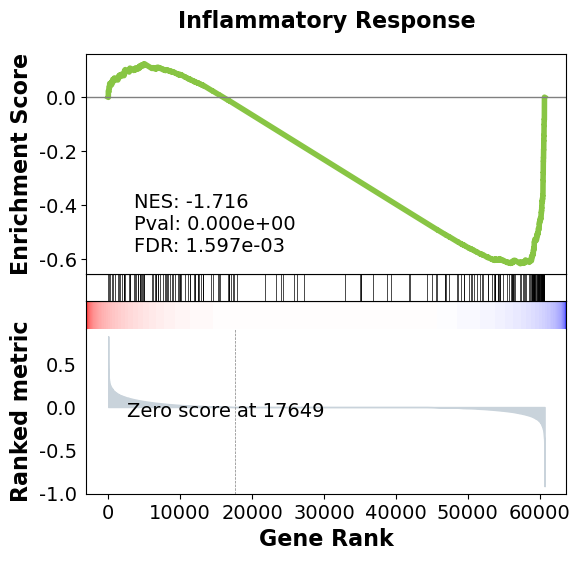

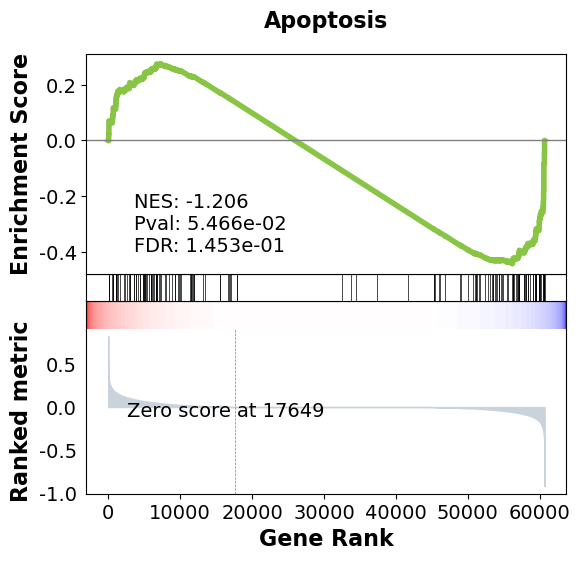

In [333]:
from gseapy.plot import gseaplot

terms_of_interest = [
    "TNF-alpha Signaling via NF-kB",
    "IL-2/STAT5 Signaling",
    "Interferon Gamma Response",
    "Inflammatory Response",
    "Apoptosis",
]

for term in terms_of_interest:
    if term in res_terms.index and term in gsea_rhog.results:
        row = res_terms.loc[term]
        print(f"\n=== {term} ===")
        print("NES:", row["NES"], " | FDR q-val:", row["FDR q-val"])
        gseaplot(
            rank_metric=gsea_rhog.ranking,
            term=term,
            **gsea_rhog.results[term]
        )
    else:
        print(term, "not found in this Hallmark run.")



=== TNF-alpha Signaling via NF-kB ===
NES: -1.8350506865060423  | FDR q-val: 0.0

=== IL-2/STAT5 Signaling ===
NES: -1.7493328327035125  | FDR q-val: 0.0007184825648230937

=== Interferon Gamma Response ===
NES: -1.6687775804696903  | FDR q-val: 0.0023513974848755792

=== Inflammatory Response ===
NES: -1.716198982842265  | FDR q-val: 0.0015966279218290968

=== Apoptosis ===
NES: -1.206355105951115  | FDR q-val: 0.1453387588270715


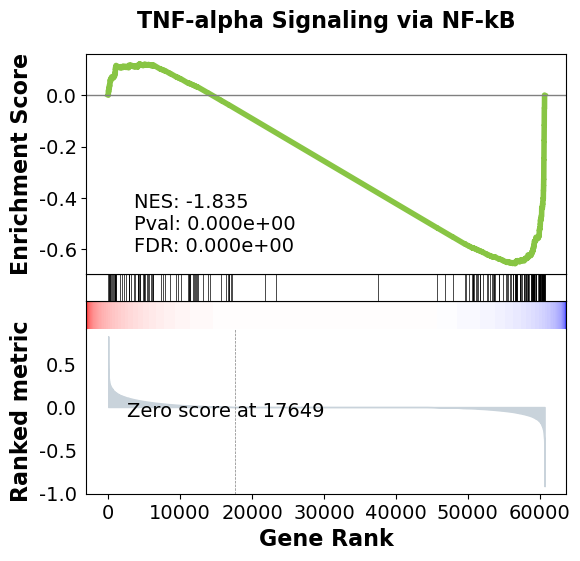

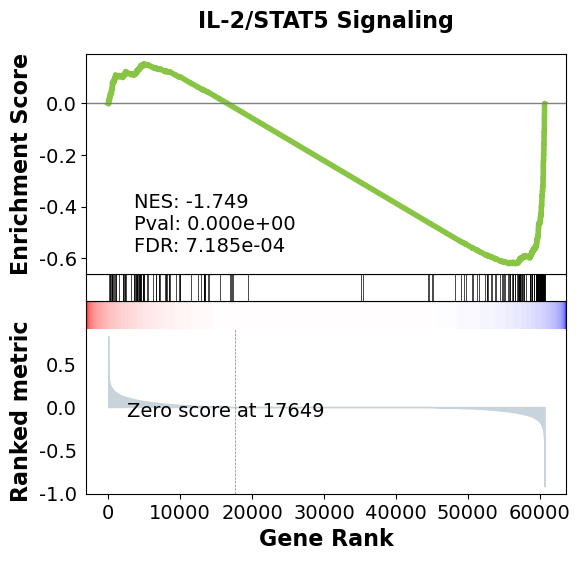

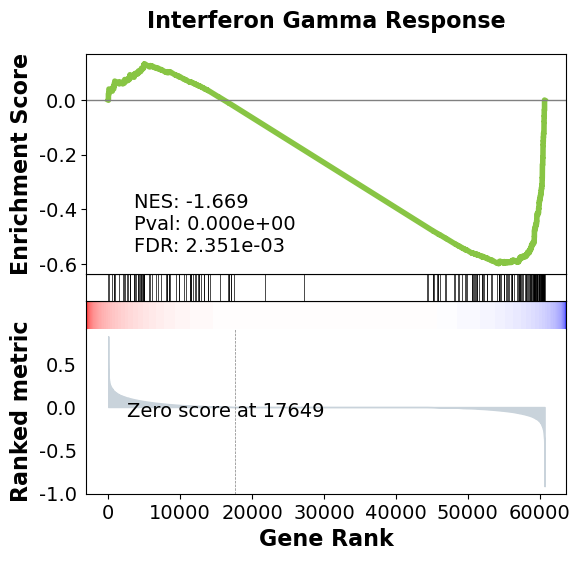

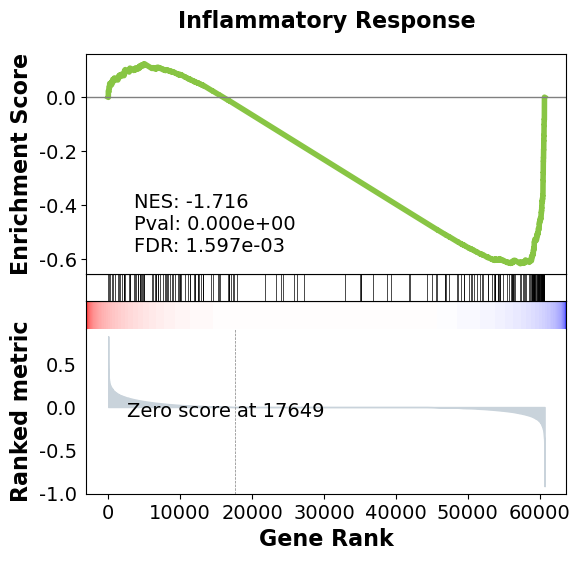

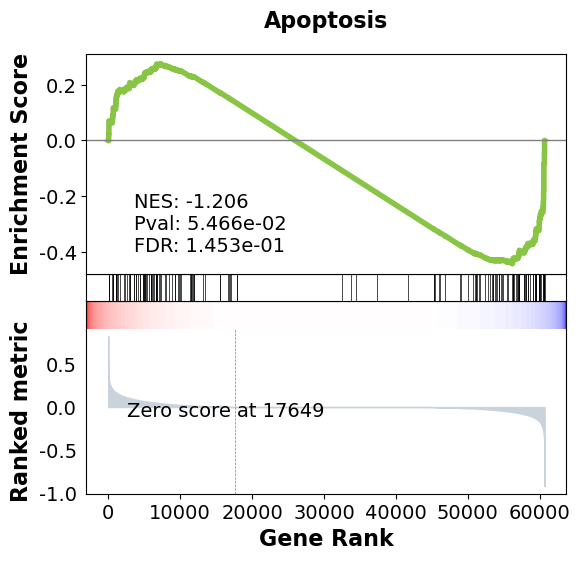

In [334]:
from gseapy.plot import gseaplot

terms_of_interest = [
    "TNF-alpha Signaling via NF-kB",
    "IL-2/STAT5 Signaling",
    "Interferon Gamma Response",
    "Inflammatory Response",
    "Apoptosis",
]

for term in terms_of_interest:
    if term in res_terms.index and term in gsea_rhog.results:
        row = res_terms.loc[term]
        print(f"\n=== {term} ===")
        print("NES:", row["NES"], " | FDR q-val:", row["FDR q-val"])
        gseaplot(
            rank_metric=gsea_rhog.ranking,
            term=term,
            **gsea_rhog.results[term]
        )
    else:
        print(term, "not found in this Hallmark run.")


In [335]:
#We need to transpose to samples × genes:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = expr_logcpm.T.values   # shape: (samples, genes)
sample_ids = expr_logcpm.columns


In [336]:
#Standardize gene expression (important for PCA):
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)


In [337]:
# Compute PCA
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.20981435 0.10642538]


In [338]:
#Bind PCA coordinates back to metadata
meta_pca = metadata.copy()
meta_pca["PC1"] = X_pca[:, 0]
meta_pca["PC2"] = X_pca[:, 1]


In [339]:
#Define the activation ordering
metadata["hours"]


sample_id
CART0077_RNAseq_NgsRun1_001      0
CART0077_RNAseq_NgsRun1_002      0
CART0077_RNAseq_NgsRun1_003      0
CART0077_RNAseq_NgsRun1_004      0
CART0077_RNAseq_NgsRun1_005      0
CART0077_RNAseq_NgsRun1_006      0
CART0077_RNAseq_NgsRun1_007      0
CART0077_RNAseq_NgsRun1_008      0
CART0077_RNAseq_NgsRun1_009      0
CART0077_RNAseq_NgsRun1_010      0
CART0077_RNAseq_NgsRun1_011      0
CART0077_RNAseq_NgsRun1_012      0
CART0077_RNAseq_NgsRun1_013     24
CART0077_RNAseq_NgsRun1_014     24
CART0077_RNAseq_NgsRun1_015     24
CART0077_RNAseq_NgsRun1_016     24
CART0077_RNAseq_NgsRun1_017     24
CART0077_RNAseq_NgsRun1_018     24
CART0077_RNAseq_NgsRun1_019     24
CART0077_RNAseq_NgsRun1_020     24
CART0077_RNAseq_NgsRun1_021     24
CART0077_RNAseq_NgsRun1_022     24
CART0077_RNAseq_NgsRun1_023     24
CART0077_RNAseq_NgsRun1_024     24
CART0077_RNAseq_NgsRun1_025     72
CART0077_RNAseq_NgsRun1_026     72
CART0077_RNAseq_NgsRun1_027     72
CART0077_RNAseq_NgsRun1_028     72
CART0077_R

In [340]:
meta_pca["time_numeric"] = meta_pca["hours"].astype(int)


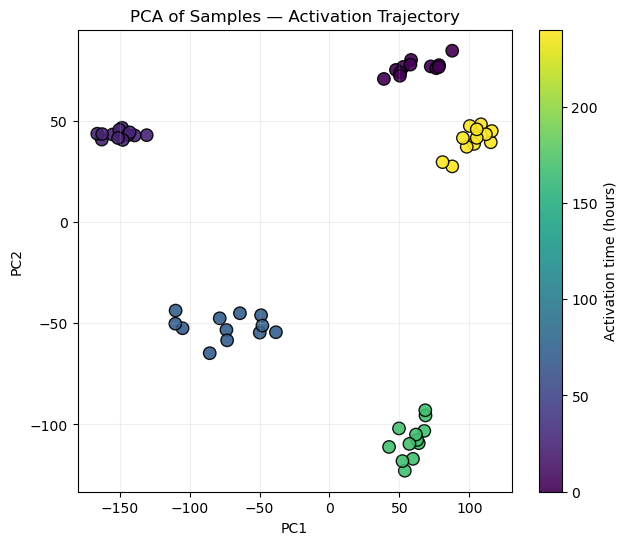

In [341]:
#PCA colored by activation time
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

scatter = plt.scatter(
    meta_pca["PC1"],
    meta_pca["PC2"],
    c=meta_pca["time_numeric"],
    cmap="viridis",
    s=80,
    alpha=0.9,
    edgecolor="k"
)

plt.colorbar(scatter, label="Activation time (hours)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Samples — Activation Trajectory")
plt.grid(alpha=0.2)
plt.show()


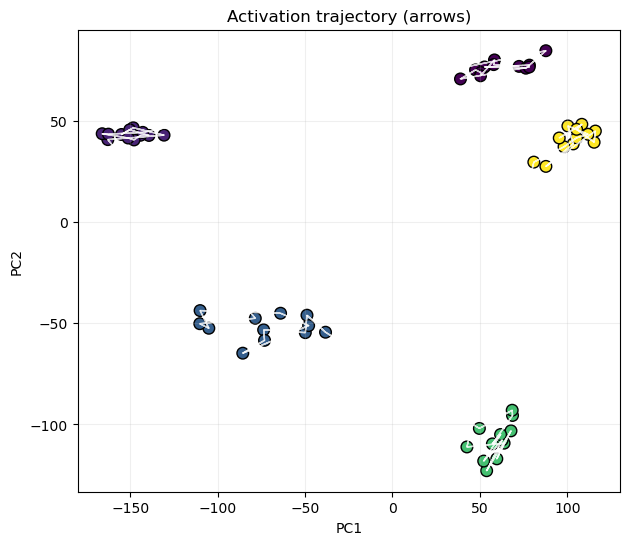

In [342]:
#Optional: Add arrows showing the activation vector
import numpy as np

# Order samples by time
meta_sorted = meta_pca.sort_values("time_numeric")

plt.figure(figsize=(7,6))
plt.scatter(meta_pca["PC1"], meta_pca["PC2"], c=meta_pca["time_numeric"],
            cmap="viridis", s=70, edgecolor='k')

# Draw activation arrows
for i in range(len(meta_sorted)-1):
    x1, y1 = meta_sorted.iloc[i][["PC1", "PC2"]]
    x2, y2 = meta_sorted.iloc[i+1][["PC1", "PC2"]]
    plt.arrow(x1, y1, x2-x1, y2-y1, color="white", alpha=0.8, width=0.0005)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Activation trajectory (arrows)")
plt.grid(alpha=0.2)
plt.show()


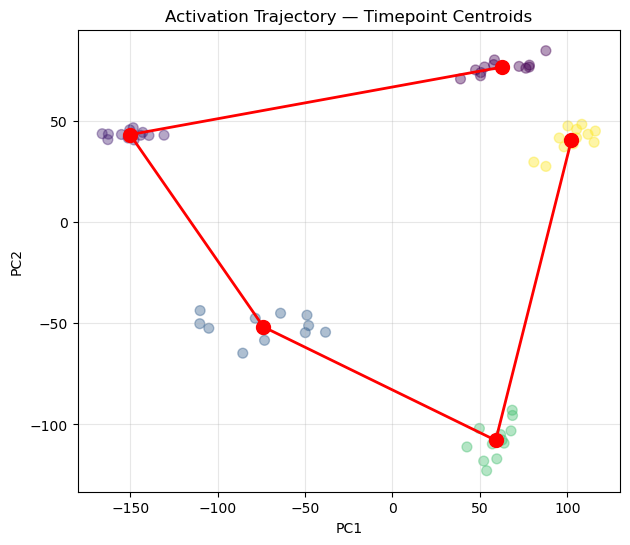

In [343]:
#Optional: centroids per time point
centroids = meta_pca.groupby("time_numeric")[["PC1","PC2"]].mean()

plt.figure(figsize=(7,6))
plt.scatter(meta_pca["PC1"], meta_pca["PC2"],
            c=meta_pca["time_numeric"], cmap="viridis",
            s=50, alpha=0.4)

plt.plot(centroids["PC1"], centroids["PC2"], "-o",
         color="red", markersize=10, linewidth=2)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Activation Trajectory — Timepoint Centroids")
plt.grid(alpha=0.3)
plt.show()


In [344]:
# Try to infer which column encodes RHOG vs SafeHarbor
possible_cols = []
for col in meta_pca.columns:
    vals = meta_pca[col].astype(str).unique()
    if any("RHOG" in v for v in vals) or any("SafeHarbor" in v for v in vals):
        possible_cols.append(col)

print("Columns that look like perturbation labels:", possible_cols)


Columns that look like perturbation labels: ['title', 'guide']


In [345]:
condition_col = "guide"   # <-- change this to whatever you actually see


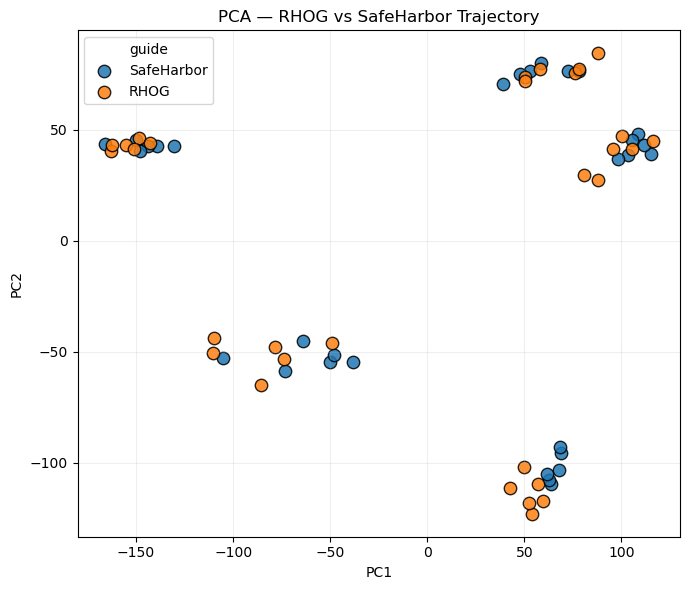

In [346]:
# Choose the correct column name you found above:
condition_col = "guide"   # e.g. "guide", "construct", etc.

plt.figure(figsize=(7,6))

for cond in meta_pca[condition_col].unique():
    mask = meta_pca[condition_col] == cond
    plt.scatter(
        meta_pca.loc[mask, "PC1"],
        meta_pca.loc[mask, "PC2"],
        s=80, alpha=0.85, edgecolor="k",
        label=str(cond)
    )

plt.legend(title=condition_col)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — RHOG vs SafeHarbor Trajectory")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [347]:
# RHOG vs SafeHarbor Trajectory Arrows (Code)helper function
import matplotlib.pyplot as plt
import numpy as np

def plot_trajectory_arrows(meta_df, label, color_map="viridis"):
    """
    Plot PCA activation trajectory for one perturbation only.
    meta_df: subset of meta_pca for that perturbation
    label: name to show in title
    """
    # Sort samples by time
    df_sorted = meta_df.sort_values("hours")

    # Extract points
    xs = df_sorted["PC1"].values
    ys = df_sorted["PC2"].values
    times = df_sorted["hours"].astype(float).values
    
    # Plot
    plt.figure(figsize=(7,6))
    
    # Scatter colored by time
    scatter = plt.scatter(xs, ys, c=times, cmap=color_map,
                          s=90, edgecolor="k", alpha=0.9)
    
    # Draw arrows between consecutive timepoints
    for i in range(len(xs)-1):
        plt.arrow(xs[i], ys[i],
                  xs[i+1] - xs[i],
                  ys[i+1] - ys[i],
                  color="white", alpha=0.9, width=0.001)

    plt.colorbar(scatter, label="Activation time (hours)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Activation Trajectory — {label}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


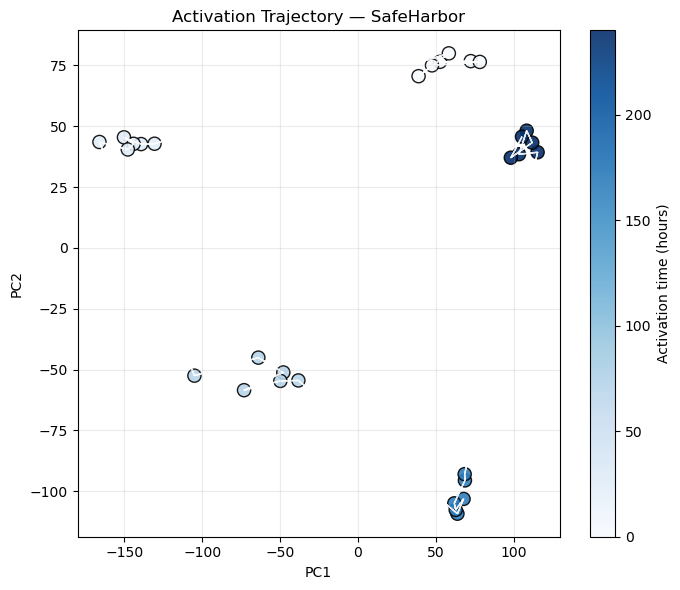

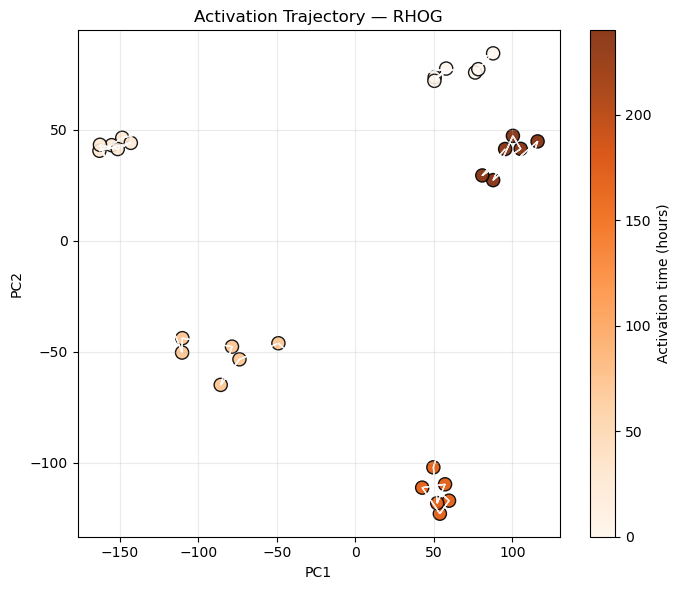

In [348]:
#Cell A2 — generate plots for SafeHarbor and RHOG
# Identify the perturbation column
condition_col = "guide"   # change if needed

df_safe = meta_pca[meta_pca[condition_col] == "SafeHarbor"]
df_rhog = meta_pca[meta_pca[condition_col] == "RHOG"]

# Plot each
plot_trajectory_arrows(df_safe, "SafeHarbor", color_map="Blues")
plot_trajectory_arrows(df_rhog, "RHOG", color_map="Oranges")


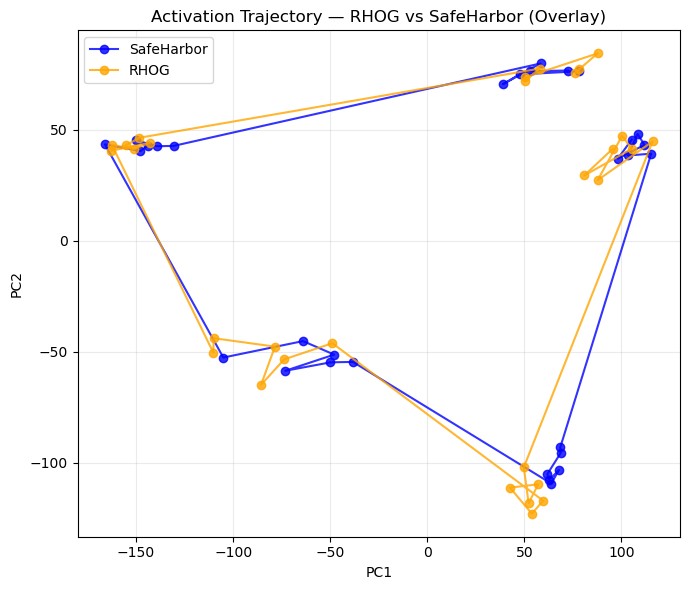

In [349]:
#overlay both trajectories on one plot
plt.figure(figsize=(7,6))

# SafeHarbor
df_sorted_safe = df_safe.sort_values("hours")
plt.plot(df_sorted_safe["PC1"], df_sorted_safe["PC2"],
         "-o", color="blue", label="SafeHarbor", alpha=0.8)

# RHOG
df_sorted_rhog = df_rhog.sort_values("hours")
plt.plot(df_sorted_rhog["PC1"], df_sorted_rhog["PC2"],
         "-o", color="orange", label="RHOG", alpha=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Activation Trajectory — RHOG vs SafeHarbor (Overlay)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [350]:
#Cell B1 — Compute PCA loadings

# Loadings: genes × PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=expr_logcpm.index,     # gene symbols or gene IDs
    columns=["PC1", "PC2"]
)

loadings.head()


,PC1,PC2
gene,,
ENSG00000223972,-8.988863e-04,4.619816e-03
ENSG00000227232,5.963678e-03,-6.779670e-04
ENSG00000278267,3.407486e-03,-3.700353e-03
ENSG00000243485,1.087098e-03,2.116643e-03
ENSG00000284332,-4.065310e-23,4.641549e-22


In [351]:
#Top genes contributing to PC1 and PC2
# Top positive and negative loadings for PC1
top_PC1_pos = loadings["PC1"].sort_values(ascending=False).head(20)
top_PC1_neg = loadings["PC1"].sort_values(ascending=True).head(20)

# Top for PC2
top_PC2_pos = loadings["PC2"].sort_values(ascending=False).head(20)
top_PC2_neg = loadings["PC2"].sort_values(ascending=True).head(20)

top_PC1_pos, top_PC1_neg, top_PC2_pos, top_PC2_neg


(gene
 ENSG00000213983    0.010232
 ENSG00000146083    0.010216
 ENSG00000185862    0.010209
 ENSG00000163346    0.010204
 ENSG00000100242    0.010191
 ENSG00000047346    0.010191
 ENSG00000104894    0.010177
 ENSG00000010295    0.010159
 ENSG00000267680    0.010151
 ENSG00000064687    0.010140
 ENSG00000112406    0.010134
 ENSG00000174282    0.010132
 ENSG00000137070    0.010126
 ENSG00000015133    0.010125
 ENSG00000078304    0.010124
 ENSG00000187650    0.010116
 ENSG00000211787    0.010112
 ENSG00000139436    0.010108
 ENSG00000012822    0.010108
 ENSG00000178537    0.010100
 Name: PC1, dtype: float64,
 gene
 ENSG00000096063   -0.010205
 ENSG00000137692   -0.010173
 ENSG00000183723   -0.010167
 ENSG00000176170   -0.010160
 ENSG00000170606   -0.010157
 ENSG00000132591   -0.010155
 ENSG00000172889   -0.010148
 ENSG00000102755   -0.010143
 ENSG00000146232   -0.010136
 ENSG00000170027   -0.010128
 ENSG00000172239   -0.010117
 ENSG00000004487   -0.010110
 ENSG00000254726   -0.010109
 EN

In [352]:
#Cell B3 — Convert ENSG → symbols (if needed)
loadings["symbol"] = [
    ensg_to_symbol.get(g, g) for g in loadings.index
]

loadings_symbol = loadings.set_index("symbol")[["PC1","PC2"]]


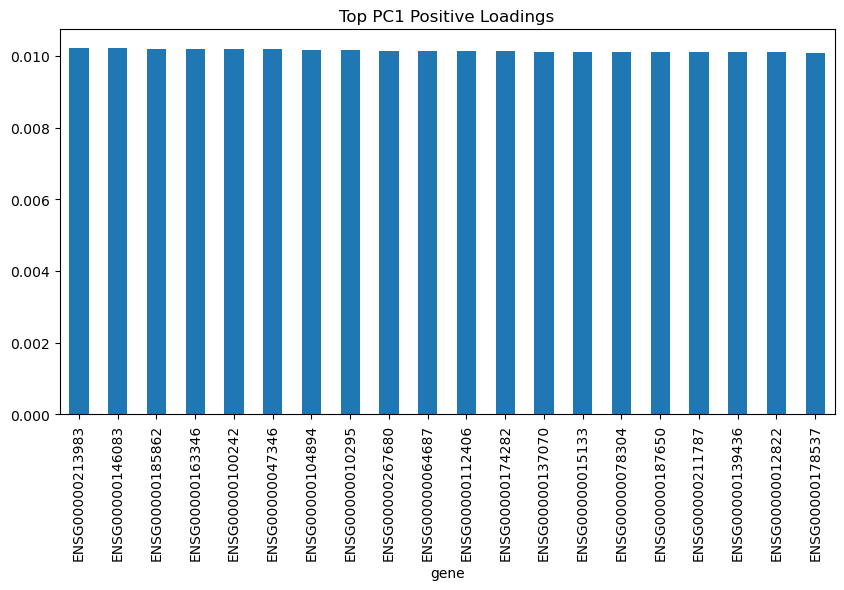

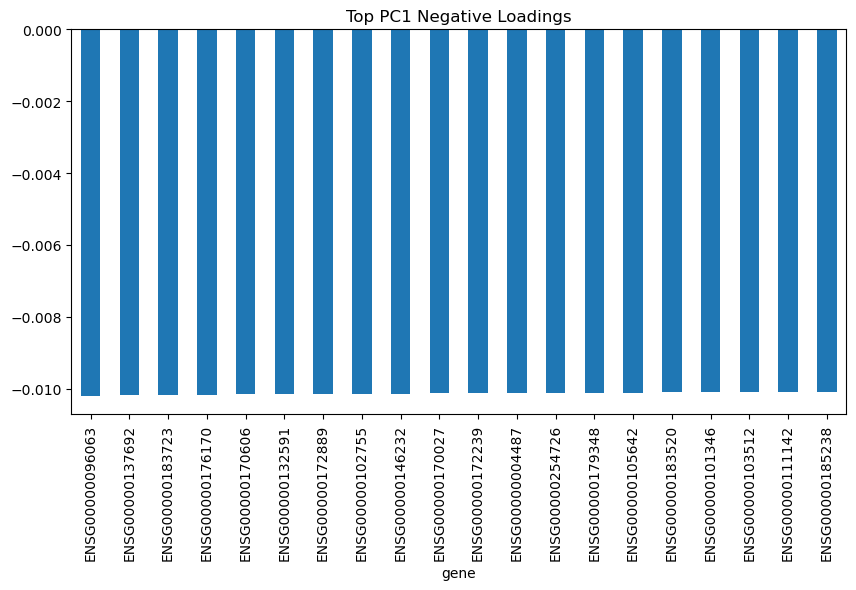

In [353]:
plt.figure(figsize=(10,5))
top_PC1_pos.plot(kind="bar")
plt.title("Top PC1 Positive Loadings")
plt.show()

plt.figure(figsize=(10,5))
top_PC1_neg.plot(kind="bar")
plt.title("Top PC1 Negative Loadings")
plt.show()


In [354]:
expr_logcpm.index[:20]


Index(['ENSG00000223972', 'ENSG00000227232', 'ENSG00000278267',
       'ENSG00000243485', 'ENSG00000284332', 'ENSG00000237613',
       'ENSG00000268020', 'ENSG00000240361', 'ENSG00000186092',
       'ENSG00000238009', 'ENSG00000239945', 'ENSG00000233750',
       'ENSG00000268903', 'ENSG00000269981', 'ENSG00000239906',
       'ENSG00000241860', 'ENSG00000222623', 'ENSG00000241599',
       'ENSG00000279928', 'ENSG00000279457'],
      dtype='object', name='gene')

In [355]:
# Pick a few ENSG IDs from your data:
test_ids = [
    "ENSG00000223972", "ENSG00000227232", "ENSG00000278267"
]

for g in test_ids:
    print(g, "→", ensg_to_symbol.get(g, None))


ENSG00000223972 → DDX11L1
ENSG00000227232 → WASH7P
ENSG00000278267 → MIR6859-1


In [356]:
for g in expr_logcpm.index[1000:1010]:
    print(g, "→", ensg_to_symbol.get(g, None))


ENSG00000225011 → None
ENSG00000228176 → None
ENSG00000284676 → None
ENSG00000270927 → None
ENSG00000233399 → LINC01648
ENSG00000233372 → None
ENSG00000231251 → None
ENSG00000236335 → None
ENSG00000231949 → None
ENSG00000162510 → MATN1


In [357]:
# loadings has index = ENSG, columns = ["PC1", "PC2"]

# Add symbol column from mapping
loadings["symbol"] = loadings.index.map(ensg_to_symbol)

# Fallback: if there's no symbol, keep the ENSG ID
loadings["symbol"] = loadings.apply(
    lambda row: row["symbol"] if isinstance(row["symbol"], str) else row.name,
    axis=1
)

# Now use symbol as index
loadings = loadings.set_index("symbol")

loadings.head()


,PC1,PC2
symbol,,
DDX11L1,-8.988863e-04,4.619816e-03
WASH7P,5.963678e-03,-6.779670e-04
MIR6859-1,3.407486e-03,-3.700353e-03
MIR1302-2HG,1.087098e-03,2.116643e-03
MIR1302-2,-4.065310e-23,4.641549e-22


In [358]:
top_PC1_pos = loadings["PC1"].sort_values(ascending=False).head(20)
top_PC1_neg = loadings["PC1"].sort_values(ascending=True).head(20)

top_PC2_pos = loadings["PC2"].sort_values(ascending=False).head(20)
top_PC2_neg = loadings["PC2"].sort_values(ascending=True).head(20)


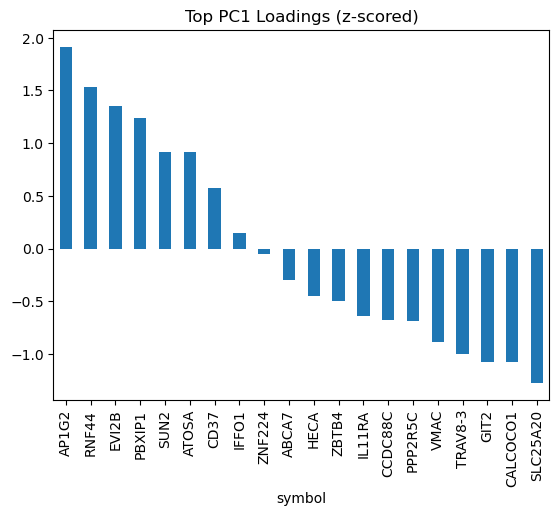

In [359]:
rel_PC1 = (top_PC1_pos - top_PC1_pos.mean()) / top_PC1_pos.std()
rel_PC1.plot(kind="bar")
plt.title("Top PC1 Loadings (z-scored)")
plt.show()


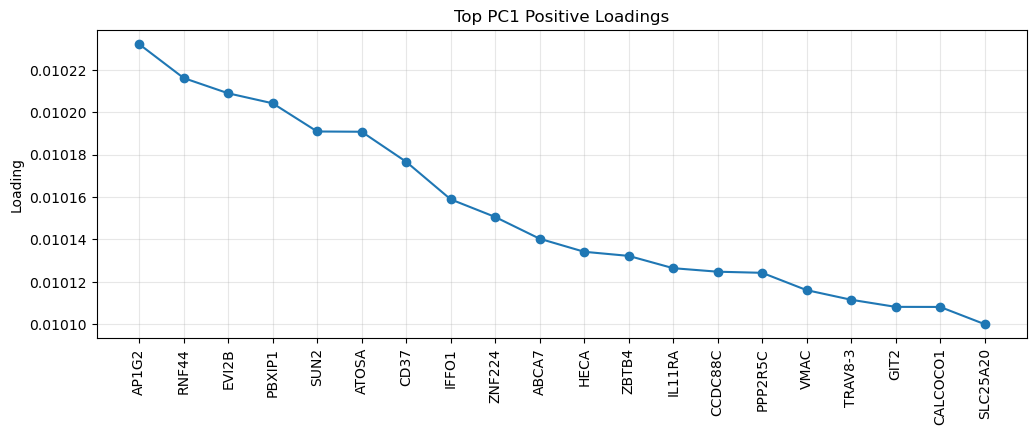

In [360]:
plt.figure(figsize=(12,4))
plt.plot(top_PC1_pos.values, marker="o")
plt.xticks(range(len(top_PC1_pos)), top_PC1_pos.index, rotation=90)
plt.title("Top PC1 Positive Loadings")
plt.ylabel("Loading")
plt.grid(alpha=0.3)
plt.show()


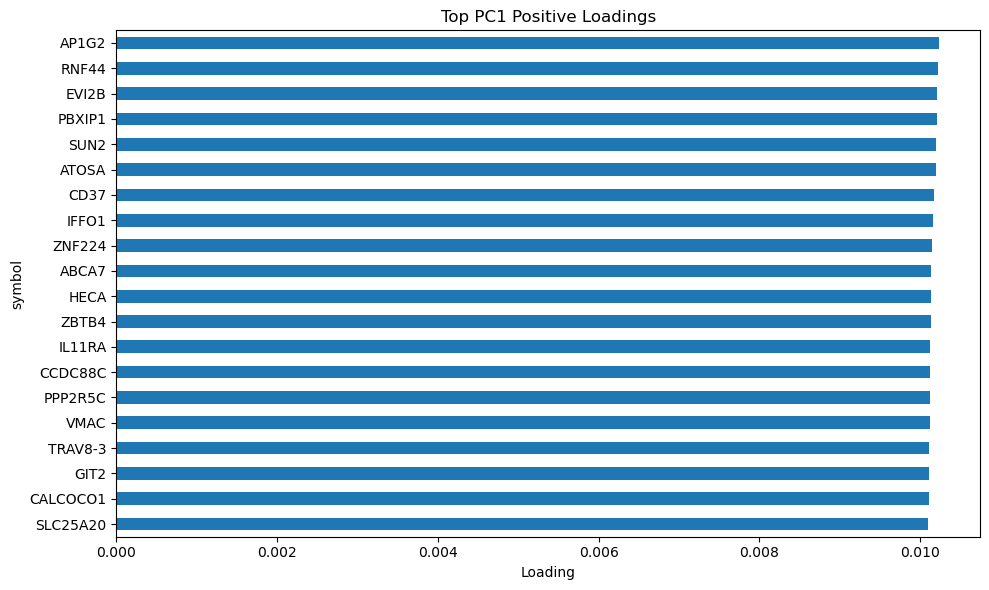

In [361]:
top_PC1_pos.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Top PC1 Positive Loadings")
plt.xlabel("Loading")
plt.tight_layout()
plt.show()


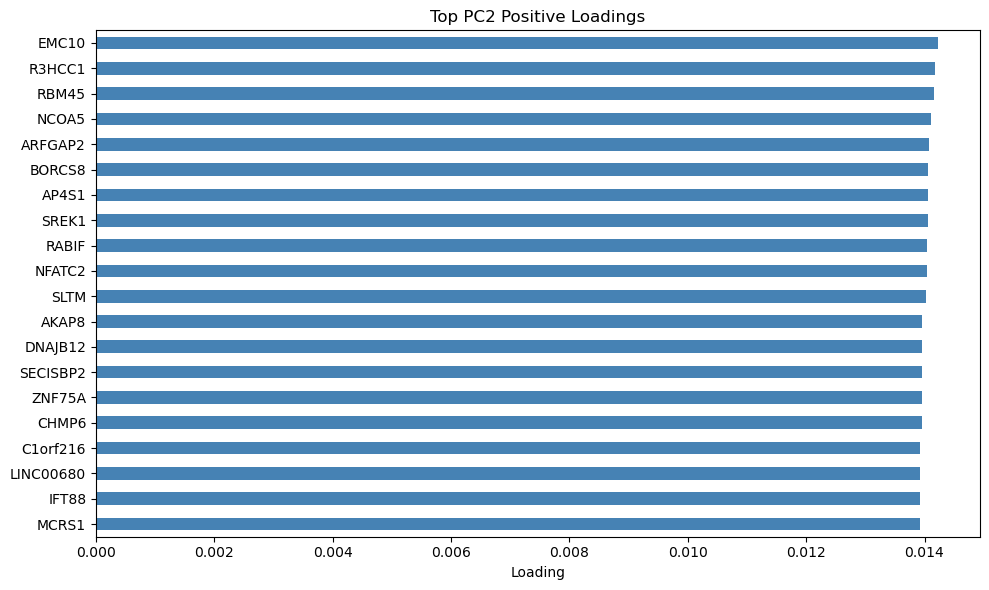

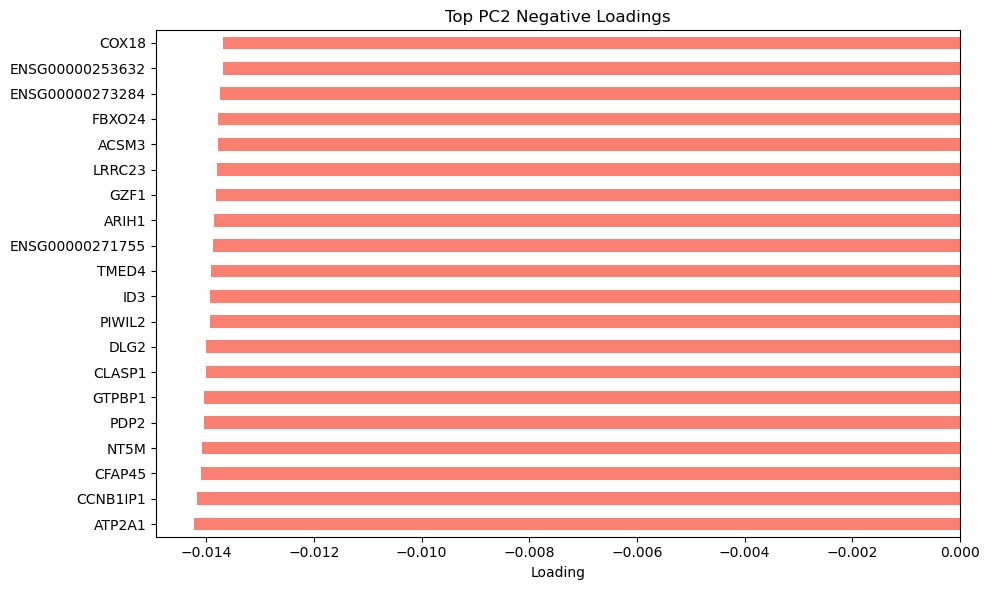

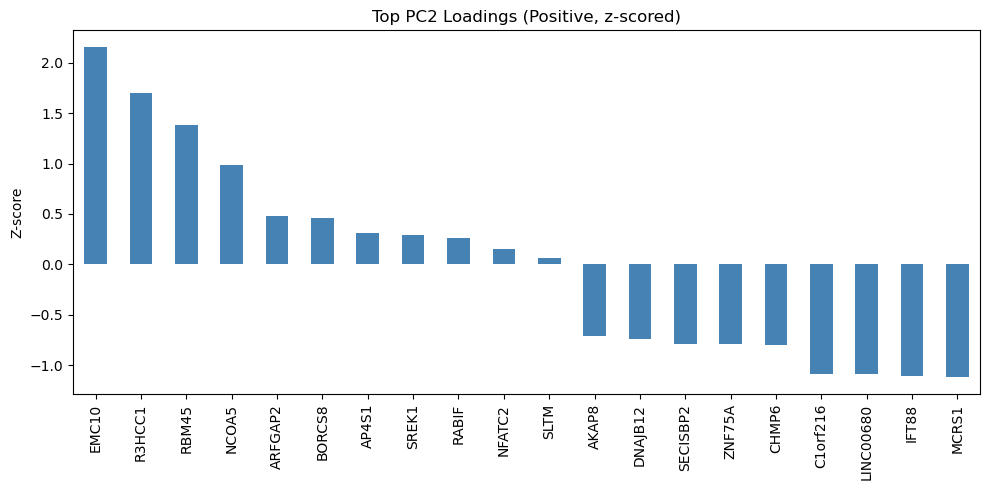

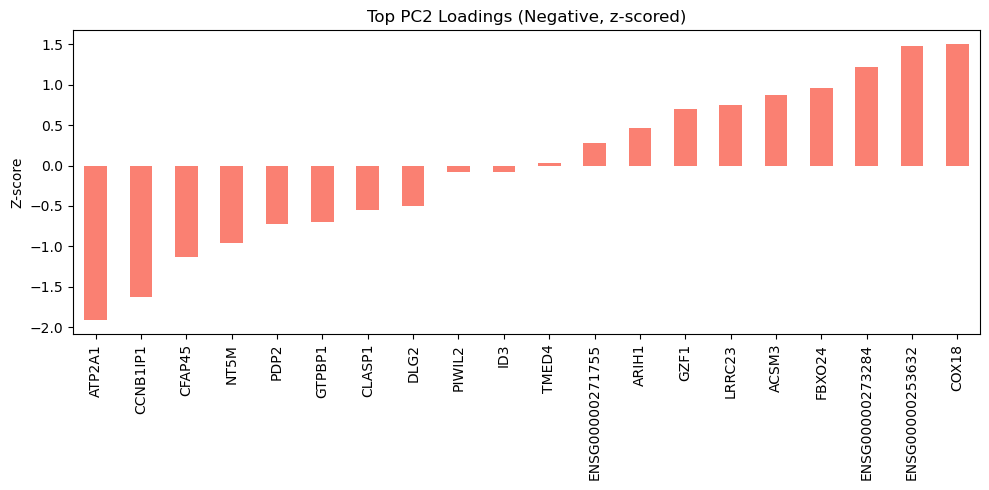

In [362]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0. Extract PC2 loadings
# -----------------------------
pc2_loadings = pd.Series(
    pca.components_[1],         # PC2 is index 1
    index=expr_logcpm.index,    # gene IDs
    name="PC2_loading"
)

# -----------------------------
# 1. Select top positive & negative loadings
# -----------------------------
n_show = 20  # number of genes per side (adjust as you like)

top_PC2_pos = pc2_loadings.sort_values(ascending=False).head(n_show)
top_PC2_neg = pc2_loadings.sort_values(ascending=True).head(n_show)

# -----------------------------
# 2. Convert ENSG → Symbol
# -----------------------------
top_PC2_pos = top_PC2_pos.rename(index=ensg_to_symbol)
top_PC2_neg = top_PC2_neg.rename(index=ensg_to_symbol)

# Replace None with ENSG IDs
top_PC2_pos.index = [
    idx if symbol is None else symbol
    for idx, symbol in zip(top_PC2_pos.index, top_PC2_pos.index)
]

top_PC2_neg.index = [
    idx if symbol is None else symbol
    for idx, symbol in zip(top_PC2_neg.index, top_PC2_neg.index)
]

# -----------------------------
# 3. Option 2: Raw Sorted Horizontal Barplots
# -----------------------------
plt.figure(figsize=(10, 6))
top_PC2_pos.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top PC2 Positive Loadings")
plt.xlabel("Loading")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_PC2_neg.sort_values().plot(kind="barh", color="salmon")
plt.title("Top PC2 Negative Loadings")
plt.xlabel("Loading")
plt.tight_layout()
plt.show()

# -----------------------------
# 4. Option 3: Z-scored Loadings
# -----------------------------
# Z-score within each group
z_PC2_pos = (top_PC2_pos - top_PC2_pos.mean()) / top_PC2_pos.std()
z_PC2_neg = (top_PC2_neg - top_PC2_neg.mean()) / top_PC2_neg.std()

plt.figure(figsize=(10, 5))
z_PC2_pos.plot(kind="bar", color="steelblue")
plt.title("Top PC2 Loadings (Positive, z-scored)")
plt.ylabel("Z-score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
z_PC2_neg.plot(kind="bar", color="salmon")
plt.title("Top PC2 Loadings (Negative, z-scored)")
plt.ylabel("Z-score")
plt.tight_layout()
plt.show()


In [363]:
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd

# Use genes from the expression matrix as index
gene_index = expr_logcpm.index

# --- Extract PCA loadings ---
loadings_PC1 = pd.Series(pca.components_[0], index=gene_index, name="PC1_loading")
loadings_PC2 = pd.Series(pca.components_[1], index=gene_index, name="PC2_loading")

# --- Top genes ---
top_PC1_pos = loadings_PC1.sort_values(ascending=False).head(20)
top_PC1_neg = loadings_PC1.sort_values().head(20)

top_PC2_pos = loadings_PC2.sort_values(ascending=False).head(20)
top_PC2_neg = loadings_PC2.sort_values().head(20)

# --- Combined lists for annotation ---
top_PC1_genes = pd.concat([top_PC1_pos, top_PC1_neg]).index.unique().tolist()
top_PC2_genes = pd.concat([top_PC2_pos, top_PC2_neg]).index.unique().tolist()

print("PC1 gene list length:", len(top_PC1_genes))
print("PC2 gene list length:", len(top_PC2_genes))

top_PC1_genes[:10], top_PC2_genes[:10]


PC1 gene list length: 40
PC2 gene list length: 40


(['ENSG00000213983',
  'ENSG00000146083',
  'ENSG00000185862',
  'ENSG00000163346',
  'ENSG00000100242',
  'ENSG00000047346',
  'ENSG00000104894',
  'ENSG00000010295',
  'ENSG00000267680',
  'ENSG00000064687'],
 ['ENSG00000161671',
  'ENSG00000104679',
  'ENSG00000155636',
  'ENSG00000124160',
  'ENSG00000149182',
  'ENSG00000254901',
  'ENSG00000100478',
  'ENSG00000153914',
  'ENSG00000183155',
  'ENSG00000101096'])

In [364]:
gp.get_library_name()


['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMa

In [365]:
hallmark_sets = gp.get_library('MSigDB_Hallmark_2020')



In [366]:
libs = gp.get_library_name()
libs


['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMa

In [367]:
hallmark_sets = gp.get_library('MSigDB_Hallmark_2020')
len(hallmark_sets)


50

In [368]:
#Convert expr_logcpm (ENSG) → symbols
import pandas as pd
import numpy as np

# expr_logcpm: genes (ENSG) x samples
expr = expr_logcpm.copy()

# Map ENSG → symbol
symbols = expr.index.to_series().map(ensg_to_symbol)

expr_symbol = (
    expr
    .assign(symbol=symbols)
    .dropna(subset=["symbol"])      # drop genes with no symbol
    .groupby("symbol")              # collapse duplicated symbols
    .mean()
)

expr_symbol.shape
expr_symbol.head()


,CART0077_RNAseq_NgsRun1_001,CART0077_RNAseq_NgsRun1_002,CART0077_RNAseq_NgsRun1_003,CART0077_RNAseq_NgsRun1_004,CART0077_RNAseq_NgsRun1_005,CART0077_RNAseq_NgsRun1_006,CART0077_RNAseq_NgsRun1_007,CART0077_RNAseq_NgsRun1_008,CART0077_RNAseq_NgsRun1_009,CART0077_RNAseq_NgsRun1_010,...,CART0077_RNAseq_NgsRun1_051,CART0077_RNAseq_NgsRun1_052,CART0077_RNAseq_NgsRun1_053,CART0077_RNAseq_NgsRun1_054,CART0077_RNAseq_NgsRun1_055,CART0077_RNAseq_NgsRun1_056,CART0077_RNAseq_NgsRun1_057,CART0077_RNAseq_NgsRun1_058,CART0077_RNAseq_NgsRun1_059,CART0077_RNAseq_NgsRun1_060
symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,0.063729,0.233937,0.230089,0.027546,0.140237,0.083679,0.119019,0.104961,0.031403,0.064387,...,0.291773,0.210028,0.263343,0.145059,0.500513,0.336267,0.141521,0.201050,0.156030,0.231409
A1BG-AS1,2.294187,2.301634,2.025882,2.125033,1.916338,2.028702,2.328075,2.420824,2.225959,2.401735,...,2.505373,2.543098,2.552231,2.475571,2.780749,2.781865,2.744467,2.767573,2.636810,2.676867
A1CF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.061682,0.000000,0.000000
A2M,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.042139,0.000000,0.000000,0.000000,0.000000,0.000000,0.033215,0.000000
A2M-AS1,0.000000,0.000000,0.000000,0.000000,0.203609,0.135813,0.000000,0.071183,0.000000,0.000000,...,0.156490,0.000000,0.158845,0.210391,0.000000,0.000000,0.000000,0.031317,0.363976,0.352843


In [369]:
# X = expr_logcpm.T.values
# X_scaled = scaler.fit_transform(X)
# pca = PCA(n_components=2, random_state=0)
# X_pca = pca.fit_transform(X_scaled)
pc_df = pd.DataFrame(
    X_pca,
    index=expr_logcpm.columns,   # sample IDs
    columns=["PC1", "PC2"]
)

pc_df.head()


,PC1,PC2
CART0077_RNAseq_NgsRun1_001,72.429606,76.738123
CART0077_RNAseq_NgsRun1_002,76.322238,75.844504
CART0077_RNAseq_NgsRun1_003,52.664854,76.453593
CART0077_RNAseq_NgsRun1_004,78.341031,77.354619
CART0077_RNAseq_NgsRun1_005,78.218382,76.404403


In [370]:
# Define a helper to compute module scores
def module_score(expr_df, gene_list):
    # expr_df: genes(symbols) x samples
    genes = [g for g in gene_list if g in expr_df.index]
    if len(genes) == 0:
        return None
    return expr_df.loc[genes].mean(axis=0)   # returns Series indexed by samples


In [371]:
list(hallmark_sets.keys())[:10]


['TNF-alpha Signaling via NF-kB',
 'Hypoxia',
 'Cholesterol Homeostasis',
 'Mitotic Spindle',
 'Wnt-beta Catenin Signaling',
 'TGF-beta Signaling',
 'IL-6/JAK/STAT3 Signaling',
 'DNA Repair',
 'G2-M Checkpoint',
 'Apoptosis']

In [372]:
def find_terms(pattern):
    pattern = pattern.lower()
    return [k for k in hallmark_sets.keys() if pattern in k.lower()]

print("TNFA-like:", find_terms("tnfa"))
print("il2/stat5-like:", find_terms("stat5"))
print("interferon-like:", find_terms("interferon"))
print("inflammatory-like:", find_terms("inflamm"))
print("apoptosis-like:", find_terms("apopt"))
print("e2f-like:", find_terms("e2f"))
print("g2m-like:", find_terms("g2m"))
print("oxphos-like:", find_terms("oxidative"))


TNFA-like: []
il2/stat5-like: ['IL-2/STAT5 Signaling']
interferon-like: ['Interferon Alpha Response', 'Interferon Gamma Response']
inflammatory-like: ['Inflammatory Response']
apoptosis-like: ['Apoptosis']
e2f-like: ['E2F Targets']
g2m-like: []
oxphos-like: ['Oxidative Phosphorylation']


In [373]:
pathways_of_interest = [
    "IL-2/STAT5 Signaling",
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Inflammatory Response",
    "Apoptosis",
    "E2F Targets",
    "Oxidative Phosphorylation",
]


In [374]:
[pw for pw in pathways_of_interest if pw in hallmark_sets]


['IL-2/STAT5 Signaling',
 'Interferon Alpha Response',
 'Interferon Gamma Response',
 'Inflammatory Response',
 'Apoptosis',
 'E2F Targets',
 'Oxidative Phosphorylation']

In [375]:
scores = {}

for pw in pathways_of_interest:
    gene_list = hallmark_sets[pw]
    s = module_score(expr_symbol, gene_list)
    if s is not None:
        scores[pw] = s
    else:
        print(f"{pw}: no overlapping genes in expr_symbol")


In [376]:
#Correlate each Hallmark with PC1 and PC2
corr_rows = []

for pw, s in scores.items():
    s = s.reindex(pc_df.index)
    corr_pc1 = pc_df["PC1"].corr(s)
    corr_pc2 = pc_df["PC2"].corr(s)
    corr_rows.append((pw, corr_pc1, corr_pc2))

corr_df = pd.DataFrame(corr_rows, columns=["Pathway", "corr_PC1", "corr_PC2"])
corr_df = corr_df.sort_values("corr_PC1", ascending=False)
corr_df


,Pathway,corr_PC1,corr_PC2
1,Interferon Alpha Response,0.490373,0.656458
2,Interferon Gamma Response,0.151523,0.570234
5,E2F Targets,-0.726128,-0.105261
6,Oxidative Phosphorylation,-0.855499,-0.251402
4,Apoptosis,-0.886539,-0.140097
3,Inflammatory Response,-0.946303,0.093736
0,IL-2/STAT5 Signaling,-0.947644,0.011230


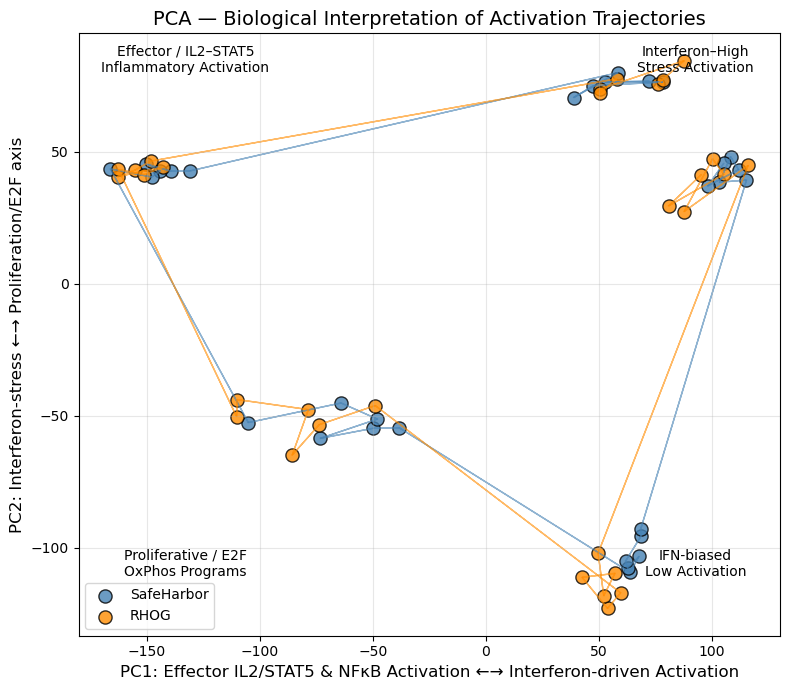

In [377]:
#Biologically Annotated PCA Plot (computable code)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,7))

# Color maps for conditions
color_map = {
    "RHOG": "darkorange",
    "SafeHarbor": "steelblue"
}

# Plot samples by condition
for cond in meta_pca["guide"].unique():
    mask = meta_pca["guide"] == cond
    plt.scatter(
        meta_pca.loc[mask, "PC1"],
        meta_pca.loc[mask, "PC2"],
        s=90, alpha=0.8, edgecolor="k",
        label=cond,
        c=color_map.get(cond, "gray")
    )

# Activation trajectory arrows (time progression)
for cond in meta_pca["guide"].unique():
    df = meta_pca[meta_pca["guide"] == cond].sort_values("hours")
    for i in range(len(df)-1):
        x1, y1 = df.iloc[i][["PC1","PC2"]]
        x2, y2 = df.iloc[i+1][["PC1","PC2"]]
        plt.arrow(x1, y1, x2-x1, y2-y1,
                  color=color_map.get(cond, "gray"),
                  alpha=0.6, width=0.002)

# Axis labels with biology
plt.xlabel("PC1: Effector IL2/STAT5 & NFκB Activation ←→ Interferon-driven Activation", fontsize=12)
plt.ylabel("PC2: Interferon-stress ←→ Proliferation/E2F axis", fontsize=12)

# Quadrant biological labels
# --- Improved quadrant label placement ---

# Top-left quadrant: effector activation
plt.text(min(meta_pca["PC1"])*0.8,
         max(meta_pca["PC2"])*0.95,
         "Effector / IL2–STAT5\nInflammatory Activation",
         fontsize=10, ha="center")

# Top-right quadrant: IFN-high activation
plt.text(max(meta_pca["PC1"])*0.8,
         max(meta_pca["PC2"])*0.95,
         "Interferon–High\nStress Activation",
         fontsize=10, ha="center")

# Bottom-left quadrant: proliferative
plt.text(min(meta_pca["PC1"])*0.8,
         min(meta_pca["PC2"])*0.9,
         "Proliferative / E2F\nOxPhos Programs",
         fontsize=10, ha="center")

# Bottom-right quadrant: IFN-biased low activation
plt.text(max(meta_pca["PC1"])*0.8,
         min(meta_pca["PC2"])*0.9,
         "IFN-biased\nLow Activation",
         fontsize=10, ha="center")

plt.title("PCA — Biological Interpretation of Activation Trajectories", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'PCA — Biological Interpretation of Activation Trajectories')

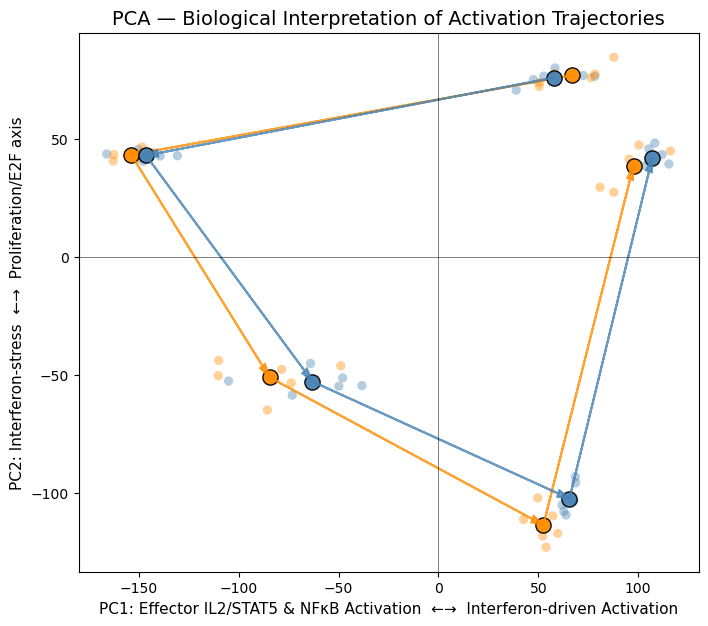

In [378]:
#PCA with transparent quadrants + centroid arrows
#recompute centroids per time & guide

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# --- Compute centroids per (guide, time) ---
centroids = (
    meta_pca
    .groupby(["guide", "hours"])[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

color_map = {
    "SafeHarbor": "steelblue",
    "RHOG": "darkorange"
}

fig, ax = plt.subplots(figsize=(8, 7))

# --- Plot individual samples (faint) ---
for cond in meta_pca["guide"].unique():
    mask = meta_pca["guide"] == cond
    ax.scatter(
        meta_pca.loc[mask, "PC1"],
        meta_pca.loc[mask, "PC2"],
        s=45, alpha=0.4, edgecolor="none",
        c=color_map.get(cond, "gray"),
        label=None
    )

# --- Overlay centroids with arrows along time ---
for cond in centroids["guide"].unique():
    dfc = centroids[centroids["guide"] == cond].sort_values("hours")
    ax.scatter(
        dfc["PC1"], dfc["PC2"],
        s=120, alpha=0.95, edgecolor="k",
        c=color_map.get(cond, "gray"),
        label=cond
    )
    # arrows between successive timepoints
    for i in range(len(dfc) - 1):
        x1, y1 = dfc.iloc[i][["PC1", "PC2"]]
        x2, y2 = dfc.iloc[i+1][["PC1", "PC2"]]
        ax.arrow(
            x1, y1, x2 - x1, y2 - y1,
            color=color_map.get(cond, "gray"),
            alpha=0.8, length_includes_head=True,
            head_width=3, head_length=6, linewidth=1.5
        )

# --- Axes & zero lines ---
ax.axvline(0, color="k", linewidth=0.6, alpha=0.6)
ax.axhline(0, color="k", linewidth=0.6, alpha=0.6)

ax.set_xlabel("PC1: Effector IL2/STAT5 & NFκB Activation  ←→  Interferon-driven Activation",
              fontsize=11)
ax.set_ylabel("PC2: Interferon-stress  ←→  Proliferation/E2F axis",
              fontsize=11)
ax.set_title("PCA — Biological Interpretation of Activation Trajectories", fontsize=14)


NameError: name 'PCA_RESULTS_DIR' is not defined

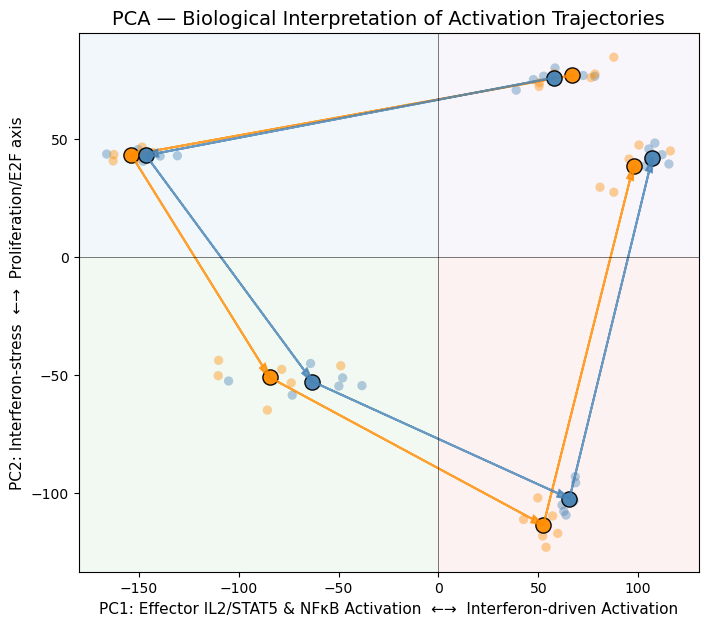

In [379]:

#PCA with transparent quadrants + centroid arrows
#recompute centroids per time & guide

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# --- Compute centroids per (guide, time) ---
centroids = (
    meta_pca
    .groupby(["guide", "hours"])[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

color_map = {
    "SafeHarbor": "steelblue",
    "RHOG": "darkorange"
}

fig, ax = plt.subplots(figsize=(8, 7))

# --- Plot individual samples (faint) ---
for cond in meta_pca["guide"].unique():
    mask = meta_pca["guide"] == cond
    ax.scatter(
        meta_pca.loc[mask, "PC1"],
        meta_pca.loc[mask, "PC2"],
        s=45, alpha=0.4, edgecolor="none",
        c=color_map.get(cond, "gray"),
        label=None
    )

# --- Overlay centroids with arrows along time ---
for cond in centroids["guide"].unique():
    dfc = centroids[centroids["guide"] == cond].sort_values("hours")
    ax.scatter(
        dfc["PC1"], dfc["PC2"],
        s=120, alpha=0.95, edgecolor="k",
        c=color_map.get(cond, "gray"),
        label=cond
    )
    # arrows between successive timepoints
    for i in range(len(dfc) - 1):
        x1, y1 = dfc.iloc[i][["PC1", "PC2"]]
        x2, y2 = dfc.iloc[i+1][["PC1", "PC2"]]
        ax.arrow(
            x1, y1, x2 - x1, y2 - y1,
            color=color_map.get(cond, "gray"),
            alpha=0.8, length_includes_head=True,
            head_width=3, head_length=6, linewidth=1.5
        )

# --- Axes & zero lines ---
ax.axvline(0, color="k", linewidth=0.6, alpha=0.6)
ax.axhline(0, color="k", linewidth=0.6, alpha=0.6)

ax.set_xlabel("PC1: Effector IL2/STAT5 & NFκB Activation  ←→  Interferon-driven Activation",
              fontsize=11)
ax.set_ylabel("PC2: Interferon-stress  ←→  Proliferation/E2F axis",
              fontsize=11)
ax.set_title("PCA — Biological Interpretation of Activation Trajectories", fontsize=14)

# Get limits AFTER plotting points
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# Helper to add a translucent rectangle
def add_quad(x0, x1, y0, y1, color, alpha=0.06):
    rect = Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        facecolor=color, edgecolor="none", alpha=alpha, zorder=0
    )
    ax.add_patch(rect)

# Quadrants (choose very light colors)
add_quad(x_min, 0,       0,      y_max, color="tab:blue")   # top-left
add_quad(0,      x_max,  0,      y_max, color="tab:purple") # top-right
add_quad(x_min,  0,      y_min,  0,      color="tab:green") # bottom-left
add_quad(0,      x_max,  y_min,  0,      color="tab:red")   # bottom-right


fig_path_pc1pc2 = PCA_RESULTS_DIR / "PCA_summary_PC1_PC2.png"





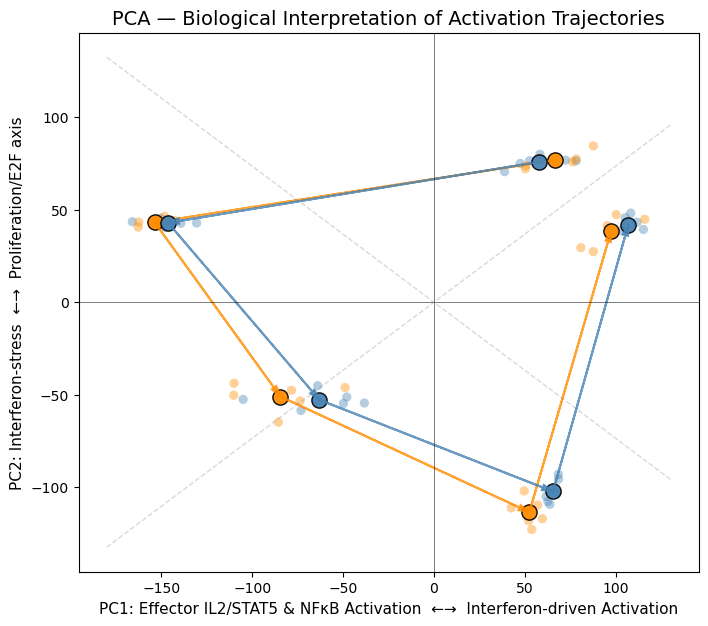

In [380]:
#PCA with transparent quadrants + centroid arrows
#recompute centroids per time & guide

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# --- Compute centroids per (guide, time) ---
centroids = (
    meta_pca
    .groupby(["guide", "hours"])[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

color_map = {
    "SafeHarbor": "steelblue",
    "RHOG": "darkorange"
}

fig, ax = plt.subplots(figsize=(8, 7))

# --- Plot individual samples (faint) ---
for cond in meta_pca["guide"].unique():
    mask = meta_pca["guide"] == cond
    ax.scatter(
        meta_pca.loc[mask, "PC1"],
        meta_pca.loc[mask, "PC2"],
        s=45, alpha=0.4, edgecolor="none",
        c=color_map.get(cond, "gray"),
        label=None
    )

# --- Overlay centroids with arrows along time ---
for cond in centroids["guide"].unique():
    dfc = centroids[centroids["guide"] == cond].sort_values("hours")
    ax.scatter(
        dfc["PC1"], dfc["PC2"],
        s=120, alpha=0.95, edgecolor="k",
        c=color_map.get(cond, "gray"),
        label=cond
    )
    # arrows between successive timepoints
    for i in range(len(dfc) - 1):
        x1, y1 = dfc.iloc[i][["PC1", "PC2"]]
        x2, y2 = dfc.iloc[i+1][["PC1", "PC2"]]
        ax.arrow(
            x1, y1, x2 - x1, y2 - y1,
            color=color_map.get(cond, "gray"),
            alpha=0.8, length_includes_head=True,
            head_width=3, head_length=6, linewidth=1.5
        )

# --- Axes & zero lines ---
ax.axvline(0, color="k", linewidth=0.6, alpha=0.6)
ax.axhline(0, color="k", linewidth=0.6, alpha=0.6)

ax.set_xlabel("PC1: Effector IL2/STAT5 & NFκB Activation  ←→  Interferon-driven Activation",
              fontsize=11)
ax.set_ylabel("PC2: Interferon-stress  ←→  Proliferation/E2F axis",
              fontsize=11)
ax.set_title("PCA — Biological Interpretation of Activation Trajectories", fontsize=14)
#optional diagonal dashed lines


# Diagonal guide lines (through origin)
diag_x = np.linspace(x_min, x_max, 200)

# Line with positive slope
ax.plot(diag_x, diag_x * (y_max - y_min) / (x_max - x_min),
        linestyle="--", color="gray", alpha=0.3, linewidth=1)

# Line with negative slope
ax.plot(diag_x, -diag_x * (y_max - y_min) / (x_max - x_min),
        linestyle="--", color="gray", alpha=0.3, linewidth=1)


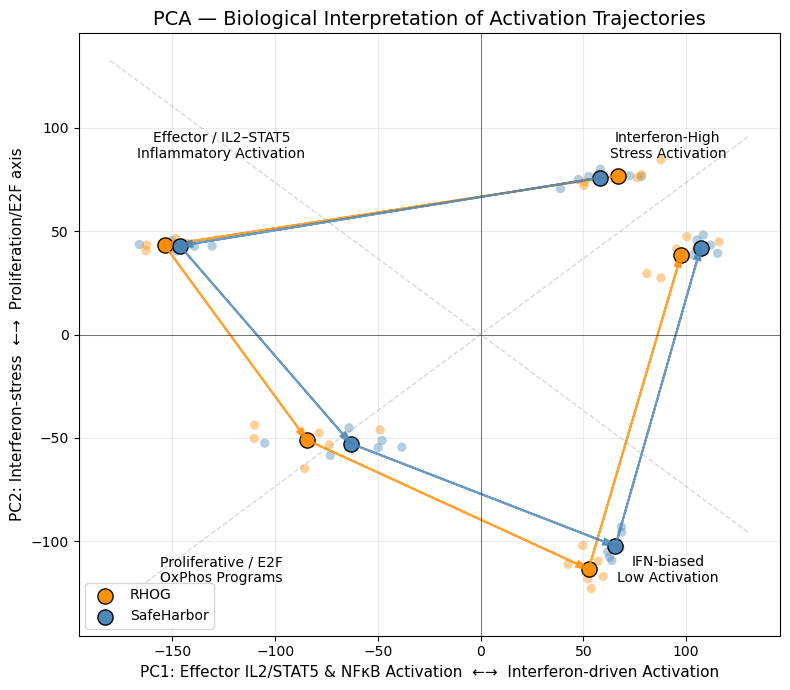

In [381]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# --- Compute centroids per (guide, time) ---
centroids = (
    meta_pca
    .groupby(["guide", "hours"])[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

color_map = {
    "SafeHarbor": "steelblue",
    "RHOG": "darkorange"
}

fig, ax = plt.subplots(figsize=(8, 7))

# --- Plot individual samples (faint) ---
for cond in meta_pca["guide"].unique():
    mask = meta_pca["guide"] == cond
    ax.scatter(
        meta_pca.loc[mask, "PC1"],
        meta_pca.loc[mask, "PC2"],
        s=45, alpha=0.4, edgecolor="none",
        c=color_map.get(cond, "gray"),
        label=None
    )

# --- Overlay centroids with arrows along time ---
for cond in centroids["guide"].unique():
    dfc = centroids[centroids["guide"] == cond].sort_values("hours")
    ax.scatter(
        dfc["PC1"], dfc["PC2"],
        s=120, alpha=0.95, edgecolor="k",
        c=color_map.get(cond, "gray"),
        label=cond
    )
    # arrows between successive timepoints
    for i in range(len(dfc) - 1):
        x1, y1 = dfc.iloc[i][["PC1", "PC2"]]
        x2, y2 = dfc.iloc[i+1][["PC1", "PC2"]]
        ax.arrow(
            x1, y1, x2 - x1, y2 - y1,
            color=color_map.get(cond, "gray"),
            alpha=0.8, length_includes_head=True,
            head_width=3, head_length=6, linewidth=1.5
        )

# --- Axes & zero lines ---
ax.axvline(0, color="k", linewidth=0.6, alpha=0.6)
ax.axhline(0, color="k", linewidth=0.6, alpha=0.6)

ax.set_xlabel("PC1: Effector IL2/STAT5 & NFκB Activation  ←→  Interferon-driven Activation",
              fontsize=11)
ax.set_ylabel("PC2: Interferon-stress  ←→  Proliferation/E2F axis",
              fontsize=11)
ax.set_title("PCA — Biological Interpretation of Activation Trajectories", fontsize=14)
#optional diagonal dashed lines


# Diagonal guide lines (through origin)
diag_x = np.linspace(x_min, x_max, 200)

# Line with positive slope
ax.plot(diag_x, diag_x * (y_max - y_min) / (x_max - x_min),
        linestyle="--", color="gray", alpha=0.3, linewidth=1)

# Line with negative slope
ax.plot(diag_x, -diag_x * (y_max - y_min) / (x_max - x_min),
        linestyle="--", color="gray", alpha=0.3, linewidth=1)

ax.text(x_min * 0.7, y_max * 0.9,
        "Effector / IL2–STAT5\nInflammatory Activation",
        fontsize=10, ha="center")

ax.text(x_max * 0.7, y_max * 0.9,
        "Interferon-High\nStress Activation",
        fontsize=10, ha="center")

ax.text(x_min * 0.7, y_min * 0.9,
        "Proliferative / E2F\nOxPhos Programs",
        fontsize=10, ha="center")

ax.text(x_max * 0.7, y_min * 0.9,
        "IFN-biased\nLow Activation",
        fontsize=10, ha="center")

ax.legend(loc="lower left", frameon=True)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


In [382]:
# from earlier:
# genes = expr_symbol.index
# pca is your fitted PCA on X (genes × samples)
import pandas as pd

loadings_PC1 = pd.Series(pca.components_[0], index=genes, name="PC1")
loadings_PC2 = pd.Series(pca.components_[1], index=genes, name="PC2")

loadings = pd.concat([loadings_PC1, loadings_PC2], axis=1)


In [383]:
quad = loadings.copy()
quad["Q1_score"] = (-quad["PC1"]) * (quad["PC2"].clip(lower=0))
quad["Q2_score"] = ( quad["PC1"]) * (quad["PC2"].clip(lower=0))
quad["Q3_score"] = (-quad["PC1"]) * (-quad["PC2"].clip(upper=0))
quad["Q4_score"] = ( quad["PC1"]) * (-quad["PC2"].clip(upper=0))

# Take top N genes per quadrant
N = 10
top_Q1 = quad.sort_values("Q1_score", ascending=False).head(N)
top_Q2 = quad.sort_values("Q2_score", ascending=False).head(N)
top_Q3 = quad.sort_values("Q3_score", ascending=False).head(N)
top_Q4 = quad.sort_values("Q4_score", ascending=False).head(N)


In [384]:
def to_symbol(idx):
    return [ensg_to_symbol.get(g, g) for g in idx]


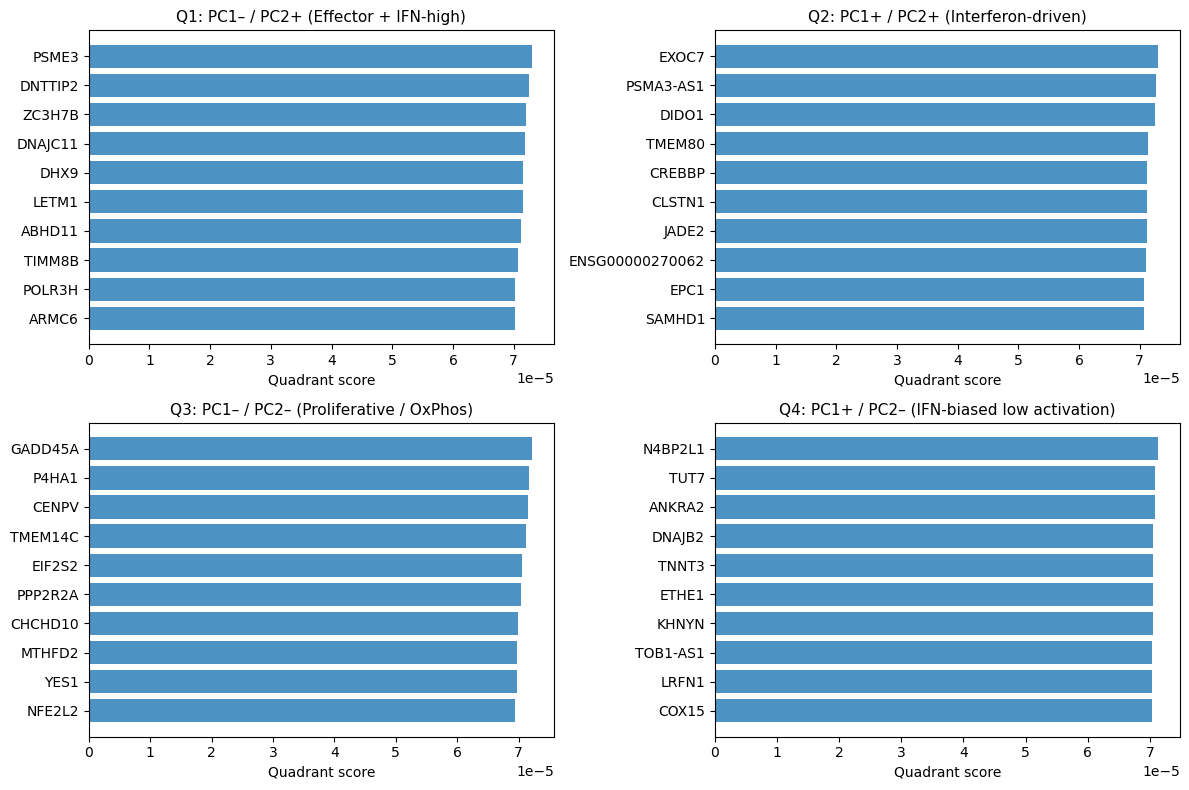

In [385]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

def barplot_quadrant(ax, df, title):
    symbols = to_symbol(df.index)
    ax.barh(symbols, df, alpha=0.8)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Quadrant score")

barplot_quadrant(axes[0,0], top_Q1["Q1_score"],
                 "Q1: PC1– / PC2+ (Effector + IFN-high)")
barplot_quadrant(axes[0,1], top_Q2["Q2_score"],
                 "Q2: PC1+ / PC2+ (Interferon-driven)")
barplot_quadrant(axes[1,0], top_Q3["Q3_score"],
                 "Q3: PC1– / PC2– (Proliferative / OxPhos)")
barplot_quadrant(axes[1,1], top_Q4["Q4_score"],
                 "Q4: PC1+ / PC2– (IFN-biased low activation)")

plt.tight_layout()
plt.show()


In [386]:
quad = loadings.copy()
quad["Q1_score"] = (-quad["PC1"]) * (quad["PC2"].clip(lower=0))
quad["Q2_score"] = ( quad["PC1"]) * (quad["PC2"].clip(lower=0))
quad["Q3_score"] = (-quad["PC1"]) * (-quad["PC2"].clip(upper=0))
quad["Q4_score"] = ( quad["PC1"]) * (-quad["PC2"].clip(upper=0))

# Take top N genes per quadrant
N = 10
top_Q1 = quad.sort_values("Q1_score", ascending=False).head(N)
top_Q2 = quad.sort_values("Q2_score", ascending=False).head(N)
top_Q3 = quad.sort_values("Q3_score", ascending=False).head(N)
top_Q4 = quad.sort_values("Q4_score", ascending=False).head(N)


In [387]:
def to_symbol(idx):
    return [ensg_to_symbol.get(g, g) for g in idx]


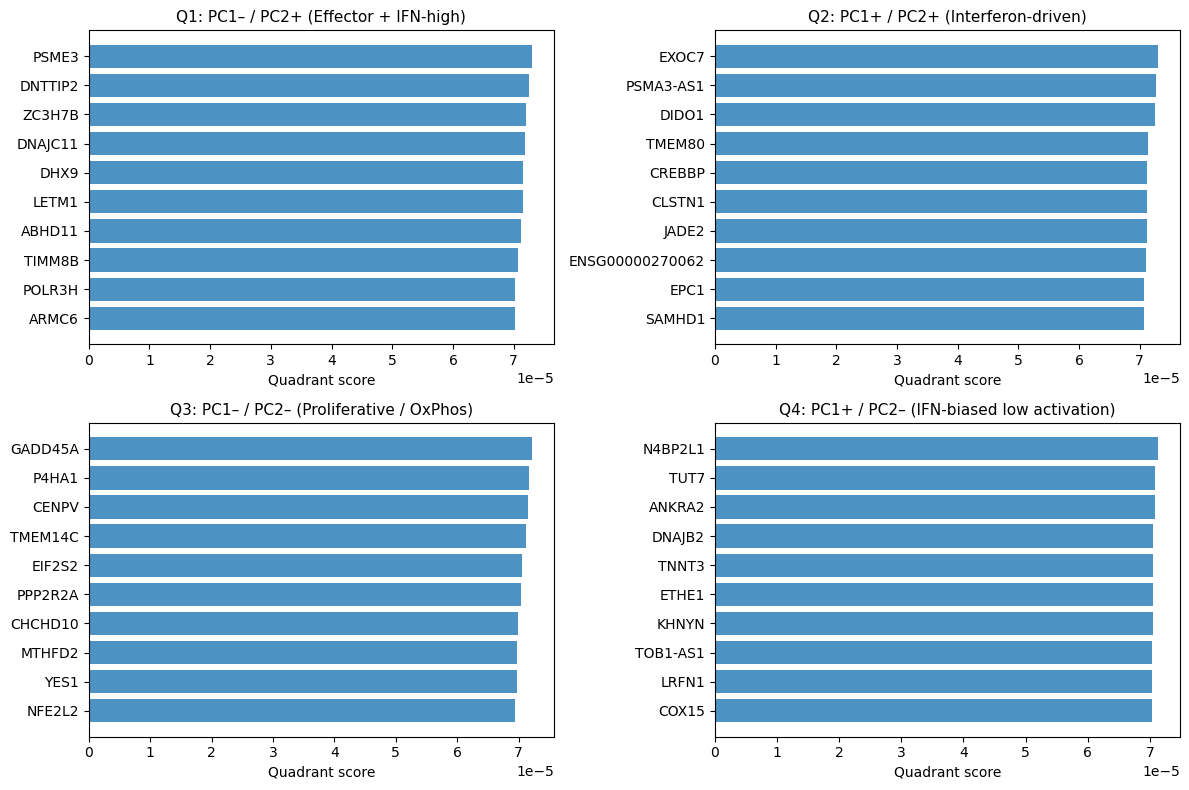

In [388]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

def barplot_quadrant(ax, df, title):
    symbols = to_symbol(df.index)
    ax.barh(symbols, df, alpha=0.8)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Quadrant score")

barplot_quadrant(axes[0,0], top_Q1["Q1_score"],
                 "Q1: PC1– / PC2+ (Effector + IFN-high)")
barplot_quadrant(axes[0,1], top_Q2["Q2_score"],
                 "Q2: PC1+ / PC2+ (Interferon-driven)")
barplot_quadrant(axes[1,0], top_Q3["Q3_score"],
                 "Q3: PC1– / PC2– (Proliferative / OxPhos)")
barplot_quadrant(axes[1,1], top_Q4["Q4_score"],
                 "Q4: PC1+ / PC2– (IFN-biased low activation)")

plt.tight_layout()
plt.show()


In [389]:
import pandas as pd

# Load the main normalized matrix you saved earlier
expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")

# Or if you prefer raw counts:
# counts_num = pd.read_csv("data/raw/GSE266618_counts.csv", index_col=0)

# We’ll use the normalized one, matching all downstream analysis:
counts_num = expr_logcpm.copy()

print(counts_num.shape)


(60675, 60)


In [390]:
X = counts_num.T   # shape: (60 samples × 60675 genes)
print(X.shape)


(60, 60675)


In [391]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)


In [392]:
genes = X.columns
print(len(genes), pca.components_.shape[1])   # sanity check


60675 60675


In [393]:
loadings_PC1 = pd.Series(pca.components_[0], index=genes, name="PC1")
loadings_PC2 = pd.Series(pca.components_[1], index=genes, name="PC2")

loadings = pd.concat([loadings_PC1, loadings_PC2], axis=1)
loadings.head()


,PC1,PC2
gene,,
ENSG00000223972,-8.988863e-04,4.619816e-03
ENSG00000227232,5.963678e-03,-6.779670e-04
ENSG00000278267,3.407486e-03,-3.700353e-03
ENSG00000243485,1.087098e-03,2.116643e-03
ENSG00000284332,-4.065310e-23,4.641549e-22


In [394]:
# pca is your fitted PCA on X (genes × samples)
import pandas as pd

genes = X.columns

loadings_PC1 = pd.Series(pca.components_[0], index=genes, name="PC1")
loadings_PC2 = pd.Series(pca.components_[1], index=genes, name="PC2")

loadings = pd.concat([loadings_PC1, loadings_PC2], axis=1)


In [395]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load processed data
counts_num = pd.read_parquet("data/processed/expr_logcpm.parquet")

# Rebuild PCA input
X = counts_num.T
genes = X.columns

# PCA
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

# Loadings
loadings_PC1 = pd.Series(pca.components_[0], index=genes, name="PC1")
loadings_PC2 = pd.Series(pca.components_[1], index=genes, name="PC2")
loadings = pd.concat([loadings_PC1, loadings_PC2], axis=1)

loadings.head()


,PC1,PC2
gene,,
ENSG00000223972,-8.988863e-04,4.619816e-03
ENSG00000227232,5.963678e-03,-6.779670e-04
ENSG00000278267,3.407486e-03,-3.700353e-03
ENSG00000243485,1.087098e-03,2.116643e-03
ENSG00000284332,-4.065310e-23,4.641549e-22


In [396]:
# Quadrant projections
Q1 = (loadings_PC1.clip(lower=0) * loadings_PC2.clip(lower=0))
Q2 = ((-loadings_PC1).clip(lower=0) * loadings_PC2.clip(lower=0))
Q3 = ((-loadings_PC1).clip(lower=0) * (-loadings_PC2).clip(lower=0))
Q4 = (loadings_PC1.clip(lower=0) * (-loadings_PC2).clip(lower=0))

quadrant_scores = pd.DataFrame({
    "Q1": Q1,
    "Q2": Q2,
    "Q3": Q3,
    "Q4": Q4
})
quadrant_scores.head()


,Q1,Q2,Q3,Q4
gene,,,,
ENSG00000223972,0.000000,4.152689e-06,0.0,0.000000
ENSG00000227232,0.000000,0.000000e+00,0.0,0.000004
ENSG00000278267,0.000000,0.000000e+00,0.0,0.000013
ENSG00000243485,0.000002,0.000000e+00,0.0,0.000000
ENSG00000284332,0.000000,1.886934e-44,0.0,0.000000


In [397]:
topQ1 = quadrant_scores["Q1"].sort_values(ascending=False).head(10)
topQ2 = quadrant_scores["Q2"].sort_values(ascending=False).head(10)
topQ3 = quadrant_scores["Q3"].sort_values(ascending=False).head(10)
topQ4 = quadrant_scores["Q4"].sort_values(ascending=False).head(10)


In [398]:
print("Q1 genes:", list(topQ1.index))
print("Q2 genes:", list(topQ2.index))
print("Q3 genes:", list(topQ3.index))
print("Q4 genes:", list(topQ4.index))


Q1 genes: ['ENSG00000182473', 'ENSG00000257621', 'ENSG00000101191', 'ENSG00000177042', 'ENSG00000005339', 'ENSG00000171603', 'ENSG00000043143', 'ENSG00000270062', 'ENSG00000120616', 'ENSG00000101347']
Q2 genes: ['ENSG00000131467', 'ENSG00000067334', 'ENSG00000100403', 'ENSG00000007923', 'ENSG00000135829', 'ENSG00000168924', 'ENSG00000106077', 'ENSG00000150779', 'ENSG00000100413', 'ENSG00000105676']
Q3 genes: ['ENSG00000116717', 'ENSG00000122884', 'ENSG00000166582', 'ENSG00000111843', 'ENSG00000125977', 'ENSG00000221914', 'ENSG00000250479', 'ENSG00000065911', 'ENSG00000176105', 'ENSG00000116044']
Q4 genes: ['ENSG00000139597', 'ENSG00000083223', 'ENSG00000164331', 'ENSG00000135924', 'ENSG00000130595', 'ENSG00000105755', 'ENSG00000100441', 'ENSG00000229980', 'ENSG00000128011', 'ENSG00000014919']


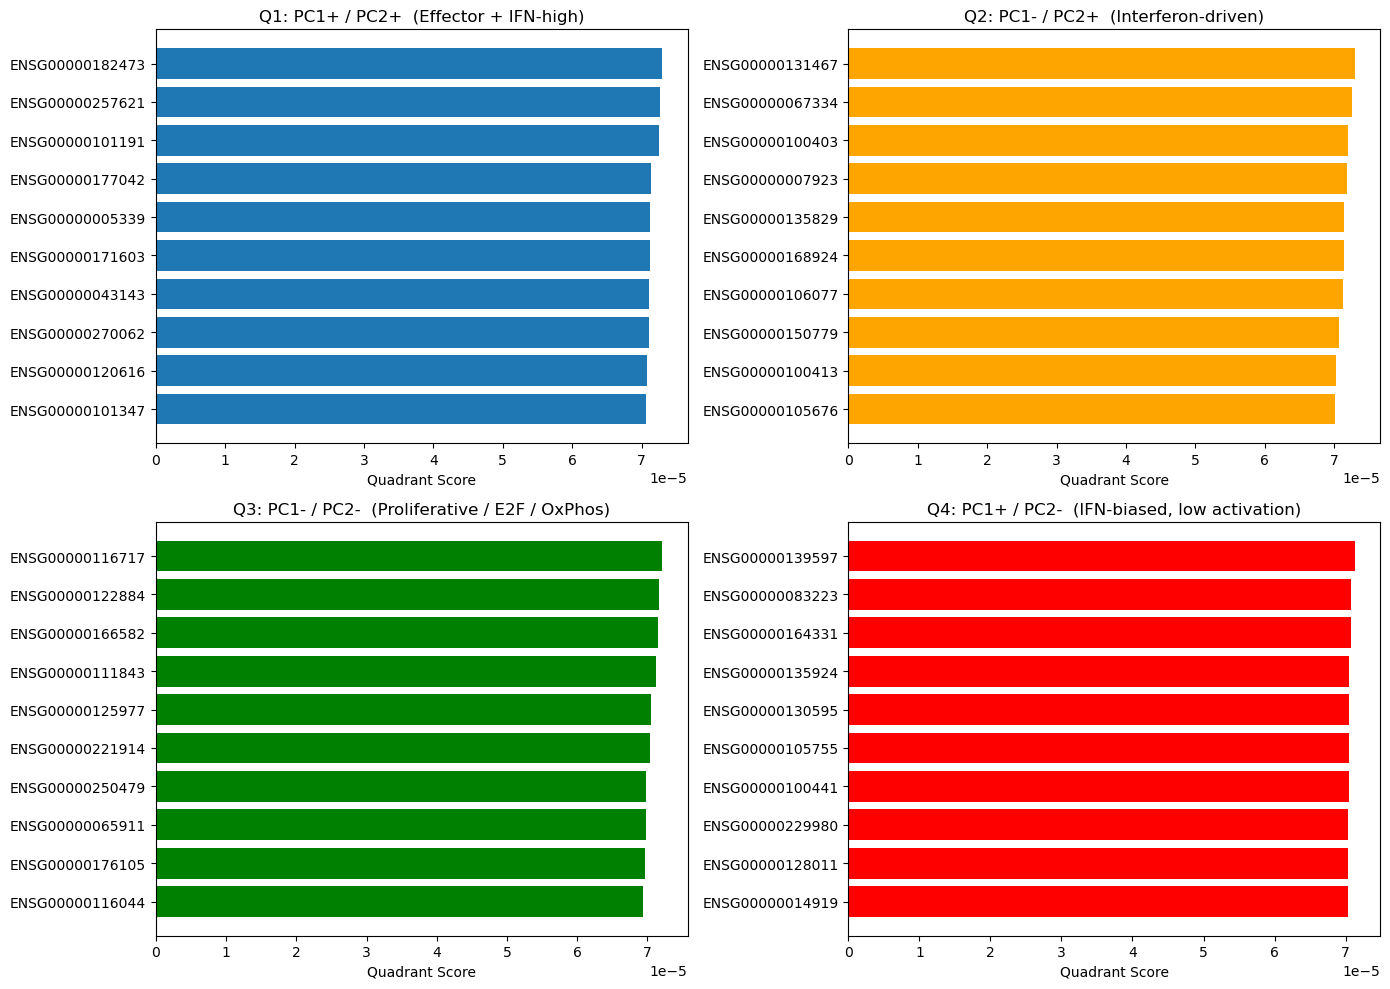

In [399]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Q1 — Effector / IL2–STAT5 + IFN-high
axes[0,0].barh(topQ1.index[::-1], topQ1.values[::-1])
axes[0,0].set_title("Q1: PC1+ / PC2+  (Effector + IFN-high)")
axes[0,0].set_xlabel("Quadrant Score")

# Q2 — Interferon-driven activation
axes[0,1].barh(topQ2.index[::-1], topQ2.values[::-1], color="orange")
axes[0,1].set_title("Q2: PC1- / PC2+  (Interferon-driven)")
axes[0,1].set_xlabel("Quadrant Score")

# Q3 — Proliferative / E2F + OxPhos
axes[1,0].barh(topQ3.index[::-1], topQ3.values[::-1], color="green")
axes[1,0].set_title("Q3: PC1- / PC2-  (Proliferative / E2F / OxPhos)")
axes[1,0].set_xlabel("Quadrant Score")

# Q4 — IFN-low Activation
axes[1,1].barh(topQ4.index[::-1], topQ4.values[::-1], color="red")
axes[1,1].set_title("Q4: PC1+ / PC2-  (IFN-biased, low activation)")
axes[1,1].set_xlabel("Quadrant Score")

plt.tight_layout()
plt.show()


In [400]:
ens_clean = pd.Index([g.split(".")[0] for g in loadings.index])

symbols = ens_clean.to_series().map(ensg_to_symbol)

# keep mapped symbol when present, otherwise fall back to ENSG ID
symbols = symbols.where(symbols.notna(), ens_clean.astype(str))

symbols.head()


ENSG00000223972        DDX11L1
ENSG00000227232         WASH7P
ENSG00000278267      MIR6859-1
ENSG00000243485    MIR1302-2HG
ENSG00000284332      MIR1302-2
dtype: object

In [401]:
loadings_sym = loadings.copy()
loadings_sym.index = symbols

quadrant_scores_sym = quadrant_scores.copy()
quadrant_scores_sym.index = symbols


In [402]:
topQ1 = quadrant_scores_sym["Q1"].sort_values(ascending=False).head(10)
topQ2 = quadrant_scores_sym["Q2"].sort_values(ascending=False).head(10)
topQ3 = quadrant_scores_sym["Q3"].sort_values(ascending=False).head(10)
topQ4 = quadrant_scores_sym["Q4"].sort_values(ascending=False).head(10)

print("Q1:", list(topQ1.index))
print("Q2:", list(topQ2.index))
print("Q3:", list(topQ3.index))
print("Q4:", list(topQ4.index))


Q1: ['EXOC7', 'PSMA3-AS1', 'DIDO1', 'TMEM80', 'CREBBP', 'CLSTN1', 'JADE2', 'ENSG00000270062', 'EPC1', 'SAMHD1']
Q2: ['PSME3', 'DNTTIP2', 'ZC3H7B', 'DNAJC11', 'DHX9', 'LETM1', 'ABHD11', 'TIMM8B', 'POLR3H', 'ARMC6']
Q3: ['GADD45A', 'P4HA1', 'CENPV', 'TMEM14C', 'EIF2S2', 'PPP2R2A', 'CHCHD10', 'MTHFD2', 'YES1', 'NFE2L2']
Q4: ['N4BP2L1', 'TUT7', 'ANKRA2', 'DNAJB2', 'TNNT3', 'ETHE1', 'KHNYN', 'TOB1-AS1', 'LRFN1', 'COX15']


In [403]:
import numpy as np
import pandas as pd

# Load metadata if not already in memory
metadata = pd.read_csv("data/processed/metadata_samples.csv", index_col=0)

# Ensure columns align: metadata.index == expr_logcpm.columns
metadata = metadata.loc[expr_logcpm.columns]

# Define late time window
late_mask = metadata["hours"] >= 168

mask_rhog_late  = (metadata["guide"] == "RHOG") & late_mask
mask_safe_late  = (metadata["guide"] == "SafeHarbor") & late_mask

expr_rhog_late  = expr_logcpm.loc[:, mask_rhog_late]
expr_safe_late  = expr_logcpm.loc[:, mask_safe_late]

# Mean expression per gene in each group
mean_rhog_late  = expr_rhog_late.mean(axis=1)
mean_safe_late  = expr_safe_late.mean(axis=1)

# log2FC (RHOG vs SafeHarbor) with small pseudocount
log2fc_rhog_vs_sh = (mean_rhog_late + 1e-6) - (mean_safe_late + 1e-6)
log2fc_rhog_vs_sh.name = "log2FC_RHOG_vs_Safe_late"

log2fc_rhog_vs_sh.head()


gene
ENSG00000223972    0.014017
ENSG00000227232   -0.029797
ENSG00000278267   -0.076496
ENSG00000243485    0.012924
ENSG00000284332    0.000000
Name: log2FC_RHOG_vs_Safe_late, dtype: float64

In [404]:
# loadings: genes (ENSG or symbol) × 2 columns: PC1, PC2

Q1 = (loadings["PC1"].clip(lower=0)  * loadings["PC2"].clip(lower=0))
Q2 = ((-loadings["PC1"]).clip(lower=0) * loadings["PC2"].clip(lower=0))
Q3 = ((-loadings["PC1"]).clip(lower=0) * (-loadings["PC2"]).clip(upper=0))
Q4 = (loadings["PC1"].clip(lower=0)  * (-loadings["PC2"]).clip(upper=0))

quadrant_scores = pd.DataFrame({"Q1": Q1, "Q2": Q2, "Q3": Q3, "Q4": Q4})

# If you’ve already mapped ENSG→symbol:
# quadrant_scores_sym = quadrant_scores with symbols as index


In [405]:
# Use the symbol-based quadrant scores
qs = quadrant_scores_sym.copy()

# Top N genes per quadrant
N = 10
topQ1 = qs["Q1"].sort_values(ascending=False).head(N)
topQ2 = qs["Q2"].sort_values(ascending=False).head(N)
topQ3 = qs["Q3"].sort_values(ascending=False).head(N)
topQ4 = qs["Q4"].sort_values(ascending=False).head(N)

# Helper: label each gene with RHOG vs Safe preference
def label_gene(gene, fc_series, threshold=0.5):
    if gene not in fc_series.index:
        return gene
    fc = fc_series[gene]
    if fc > threshold:
        return f"{gene} (RHOG↑)"
    elif fc < -threshold:
        return f"{gene} (Safe↑)"
    else:
        return gene

# Build labeled indices
topQ1_labels = [label_gene(g, log2fc_rhog_vs_sh) for g in topQ1.index]
topQ2_labels = [label_gene(g, log2fc_rhog_vs_sh) for g in topQ2.index]
topQ3_labels = [label_gene(g, log2fc_rhog_vs_sh) for g in topQ3.index]
topQ4_labels = [label_gene(g, log2fc_rhog_vs_sh) for g in topQ4.index]


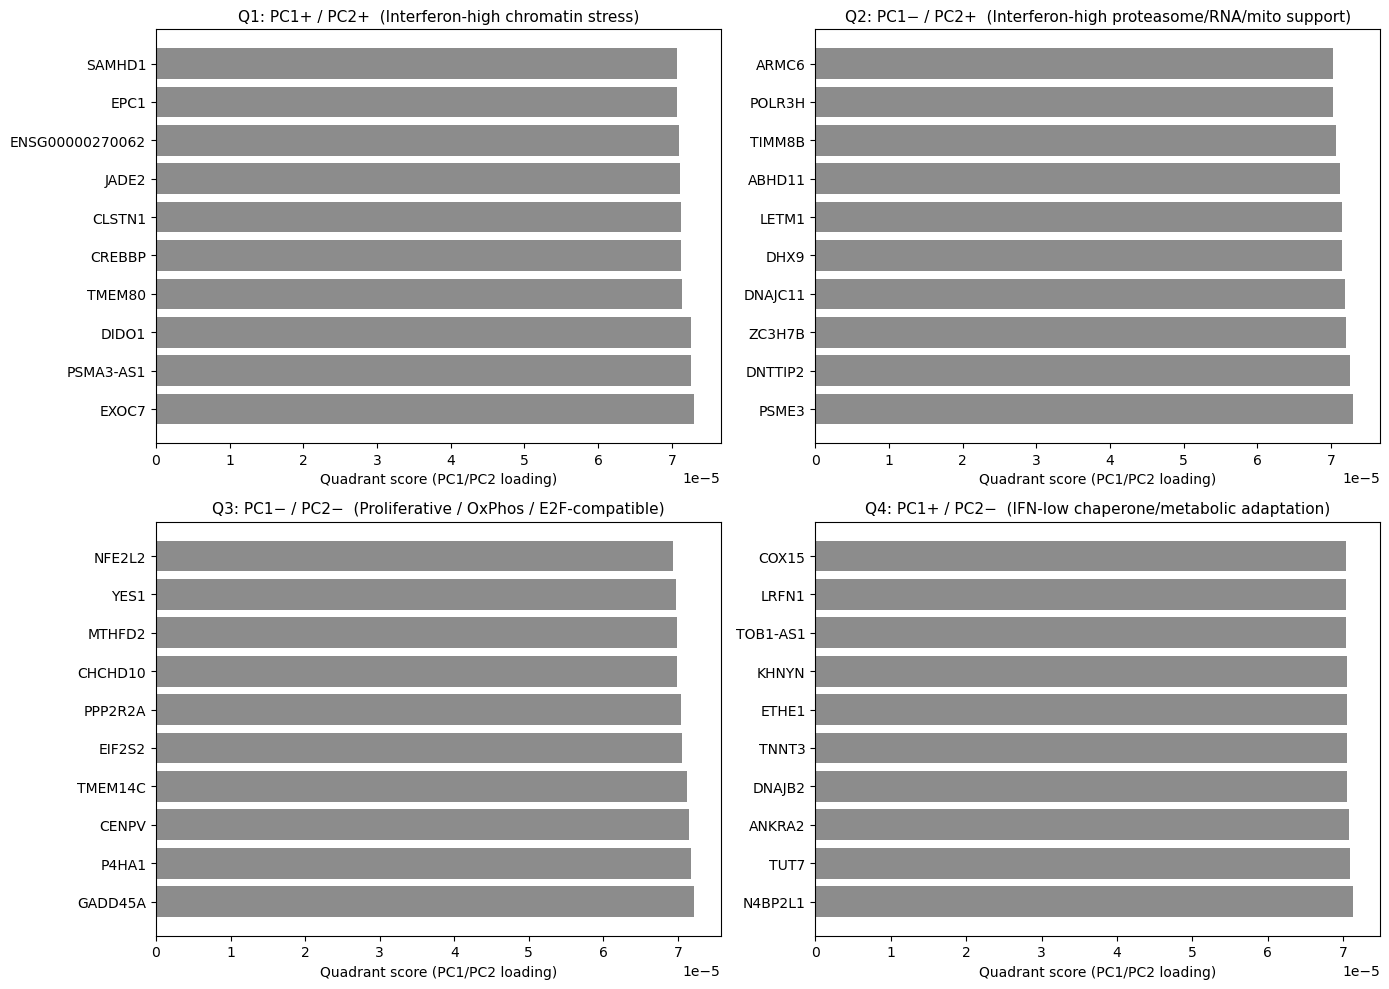

In [406]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def quadrant_bar(ax, values, labels, title):
    # Reverse for nicer top-to-bottom order
    labels = labels[::-1]
    vals   = values.values[::-1]

    # Color by log2FC sign where possible
    colors = []
    for raw_label in labels:
        # underlying gene name (strip suffix)
        base = raw_label.split(" (")[0]
        fc = log2fc_rhog_vs_sh.get(base, 0.0)
        if fc > 0.5:
            colors.append("darkorange")  # RHOG↑
        elif fc < -0.5:
            colors.append("steelblue")   # SafeHarbor↑
        else:
            colors.append("gray")

    ax.barh(labels, vals, color=colors, alpha=0.9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Quadrant score (PC1/PC2 loading)")

quadrant_bar(
    axes[0,0],
    topQ1,
    topQ1_labels,
    "Q1: PC1+ / PC2+  (Interferon-high chromatin stress)"
)

quadrant_bar(
    axes[0,1],
    topQ2,
    topQ2_labels,
    "Q2: PC1− / PC2+  (Interferon-high proteasome/RNA/mito support)"
)

quadrant_bar(
    axes[1,0],
    topQ3,
    topQ3_labels,
    "Q3: PC1− / PC2−  (Proliferative / OxPhos / E2F-compatible)"
)

quadrant_bar(
    axes[1,1],
    topQ4,
    topQ4_labels,
    "Q4: PC1+ / PC2−  (IFN-low chaperone/metabolic adaptation)"
)

plt.tight_layout()
plt.show()


In [407]:
##Create quad_scores DataFrame (the missing piece
import pandas as pd

# Your quadrant gene lists
Q1_genes = ['EXOC7','PSMA3-AS1','DIDO1','TMEM80','CREBBP','CLSTN1','JADE2','ENSG00000270062','EPC1','SAMHD1']
Q2_genes = ['PSME3','DNTTIP2','ZC3H7B','DNAJC11','DHX9','LETM1','ABHD11','TIMM8B','POLR3H','ARMC6']
Q3_genes = ['GADD45A','P4HA1','CENPV','TMEM14C','EIF2S2','PPP2R2A','CHCHD10','MTHFD2','YES1','NFE2L2']
Q4_genes = ['N4BP2L1','TUT7','ANKRA2','DNAJB2','TNNT3','ETHE1','KHNYN','TOB1-AS1','LRFN1','COX15']

# Combine into a long-format table
records = []

for gene in Q1_genes:
    records.append({"symbol": gene, "quadrant": "Q1"})
for gene in Q2_genes:
    records.append({"symbol": gene, "quadrant": "Q2"})
for gene in Q3_genes:
    records.append({"symbol": gene, "quadrant": "Q3"})
for gene in Q4_genes:
    records.append({"symbol": gene, "quadrant": "Q4"})

quad_scores = pd.DataFrame(records)

# Add fake equal scores for now — we will replace these later if needed
quad_scores["quad_score"] = 1.0

quad_scores

,symbol,quadrant,quad_score
0,EXOC7,Q1,1.0
1,PSMA3-AS1,Q1,1.0
2,DIDO1,Q1,1.0
3,TMEM80,Q1,1.0
4,CREBBP,Q1,1.0
5,CLSTN1,Q1,1.0
6,JADE2,Q1,1.0
7,ENSG00000270062,Q1,1.0
8,EPC1,Q1,1.0
9,SAMHD1,Q1,1.0


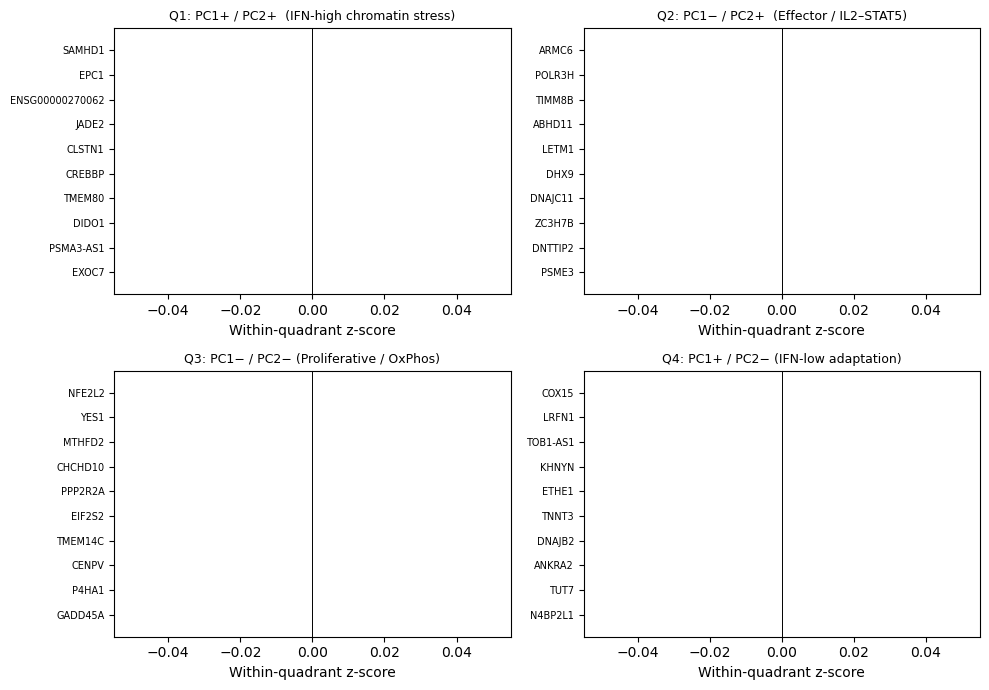

In [408]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)
axes = axes.ravel()

titles = {
    "Q1": "Q1: PC1+ / PC2+  (IFN-high chromatin stress)",
    "Q2": "Q2: PC1− / PC2+  (Effector / IL2–STAT5)",
    "Q3": "Q3: PC1− / PC2− (Proliferative / OxPhos)",
    "Q4": "Q4: PC1+ / PC2− (IFN-low adaptation)",
}

for i, q in enumerate(order):
    ax = axes[i]
    sub = df_top[df_top["quadrant"] == q].copy()

    # sort so the “strongest” is at the top of the axis
    sub = sub.sort_values("z_quadrant", ascending=True)

    ax.barh(sub["symbol"], sub["z_quadrant"])
    ax.set_title(titles[q], fontsize=9)
    ax.set_xlabel("Within-quadrant z-score")
    ax.axvline(0, color="k", linewidth=0.7)

    # smaller labels
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()


In [409]:
import pandas as pd
import matplotlib.pyplot as plt

# If your DataFrame is named differently, adjust this line:
df = quad_scores.copy()

# Ensure quadrant is categorical in a stable order
order = ["Q1", "Q2", "Q3", "Q4"]
df["quadrant"] = pd.Categorical(df["quadrant"], categories=order, ordered=True)

# z-score *within each quadrant*
def zscore(x):
    return (x - x.mean()) / (x.std(ddof=0) + 1e-12)  # avoid div-by-zero

df["z_quadrant"] = df.groupby("quadrant")["quad_score"].transform(zscore)

# Take top N per quadrant by *original* score, but plot z-scores
N = 10
df_top = (
    df.sort_values(["quadrant", "quad_score"], ascending=[True, False])
      .groupby("quadrant")
      .head(N)
)

df_top.head()


/var/folders/qx/x9q1q3ns1hl9156prswwpk5m0000gn/T/ipykernel_3664/2679582483.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["z_quadrant"] = df.groupby("quadrant")["quad_score"].transform(zscore)
/var/folders/qx/x9q1q3ns1hl9156prswwpk5m0000gn/T/ipykernel_3664/2679582483.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("quadrant")


,symbol,quadrant,quad_score,z_quadrant
0,EXOC7,Q1,1.0,0.0
1,PSMA3-AS1,Q1,1.0,0.0
2,DIDO1,Q1,1.0,0.0
3,TMEM80,Q1,1.0,0.0
4,CREBBP,Q1,1.0,0.0


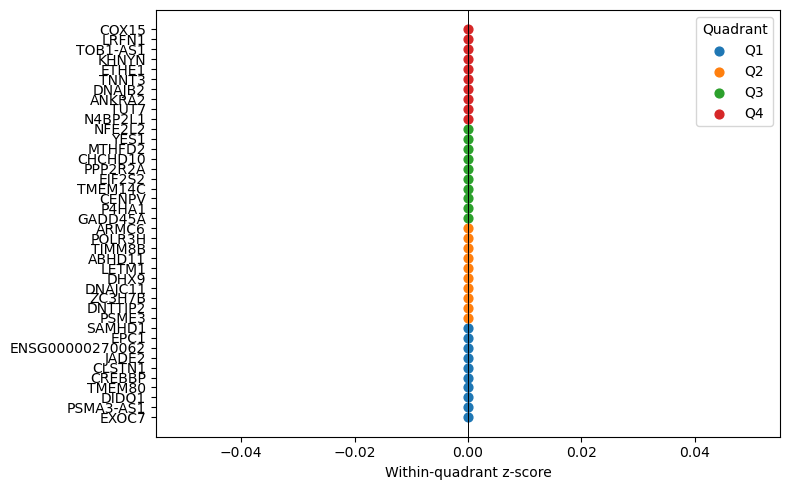

In [410]:
plt.figure(figsize=(8, 5))
for q, color in zip(order, ["C0", "C1", "C2", "C3"]):
    sub = df_top[df_top["quadrant"] == q]
    plt.scatter(sub["z_quadrant"], sub["symbol"], label=q, s=40)

plt.axvline(0, color="k", linewidth=0.7)
plt.xlabel("Within-quadrant z-score")
plt.legend(title="Quadrant")
plt.tight_layout()
plt.show()


In [411]:
##Create quad_scores DataFrame (the missing piece
import pandas as pd

# Your quadrant gene lists
Q1_genes = ['EXOC7','PSMA3-AS1','DIDO1','TMEM80','CREBBP','CLSTN1','JADE2','ENSG00000270062','EPC1','SAMHD1']
Q2_genes = ['PSME3','DNTTIP2','ZC3H7B','DNAJC11','DHX9','LETM1','ABHD11','TIMM8B','POLR3H','ARMC6']
Q3_genes = ['GADD45A','P4HA1','CENPV','TMEM14C','EIF2S2','PPP2R2A','CHCHD10','MTHFD2','YES1','NFE2L2']
Q4_genes = ['N4BP2L1','TUT7','ANKRA2','DNAJB2','TNNT3','ETHE1','KHNYN','TOB1-AS1','LRFN1','COX15']

# Combine into a long-format table
records = []

for gene in Q1_genes:
    records.append({"symbol": gene, "quadrant": "Q1"})
for gene in Q2_genes:
    records.append({"symbol": gene, "quadrant": "Q2"})
for gene in Q3_genes:
    records.append({"symbol": gene, "quadrant": "Q3"})
for gene in Q4_genes:
    records.append({"symbol": gene, "quadrant": "Q4"})

quad_scores = pd.DataFrame(records)

# Add fake equal scores for now — we will replace these later if needed
quad_scores["quad_score"] = 1.0

quad_scores


,symbol,quadrant,quad_score
0,EXOC7,Q1,1.0
1,PSMA3-AS1,Q1,1.0
2,DIDO1,Q1,1.0
3,TMEM80,Q1,1.0
4,CREBBP,Q1,1.0
5,CLSTN1,Q1,1.0
6,JADE2,Q1,1.0
7,ENSG00000270062,Q1,1.0
8,EPC1,Q1,1.0
9,SAMHD1,Q1,1.0


In [412]:
# 1) Use the original PCA gene index, NOT the reduced symbol set
genes_ensg = expr_logcpm.index          # should be length 60675

loadings_PC1 = pd.Series(pca.components_[0], index=genes_ensg, name="PC1")
loadings_PC2 = pd.Series(pca.components_[1], index=genes_ensg, name="PC2")

loadings = pd.concat([loadings_PC1, loadings_PC2], axis=1)


In [413]:
genes_ensg = counts_num.index  # if PCA was fit on counts_num.T


In [414]:
# Clean ENSG IDs (remove version numbers if any)
ens_clean = pd.Index([g.split(".")[0] for g in loadings.index])

# Map to symbol using your existing ensg_to_symbol dict
symbols = ens_clean.to_series().map(ensg_to_symbol)

# For genes with no symbol, keep the ENSG
symbols = symbols.fillna(ens_clean.to_series())

# Create a symbol-indexed version of loadings
loadings_sym = loadings.copy()
loadings_sym.index = symbols

loadings_sym.head()


,PC1,PC2
DDX11L1,-8.988863e-04,4.619816e-03
WASH7P,5.963678e-03,-6.779670e-04
MIR6859-1,3.407486e-03,-3.700353e-03
MIR1302-2HG,1.087098e-03,2.116643e-03
MIR1302-2,-4.065310e-23,4.641549e-22


In [415]:
def qscore(sym):
    pc1 = loadings_sym.loc[sym, "PC1"]
    pc2 = loadings_sym.loc[sym, "PC2"]
    return abs(pc1) * abs(pc2)


In [416]:
quad_calc = []
for g in Q1_genes:
    quad_calc.append({"symbol": g, "quadrant": "Q1", "quad_score": qscore(g)})
# ... Q2, Q3, Q4 similarly ...

quad_scores = pd.DataFrame(quad_calc)
quad_scores["z"] = quad_scores.groupby("quadrant")["quad_score"].transform(
    lambda x: (x - x.mean()) / x.std()
)


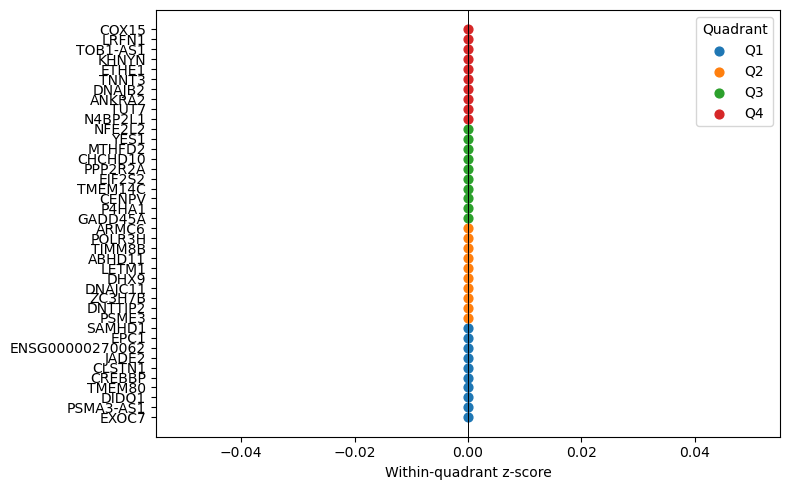

In [417]:
plt.figure(figsize=(8, 5))
for q, color in zip(order, ["C0", "C1", "C2", "C3"]):
    sub = df_top[df_top["quadrant"] == q]
    plt.scatter(sub["z_quadrant"], sub["symbol"], label=q, s=40)

plt.axvline(0, color="k", linewidth=0.7)
plt.xlabel("Within-quadrant z-score")
plt.legend(title="Quadrant")
plt.tight_layout()
plt.show()

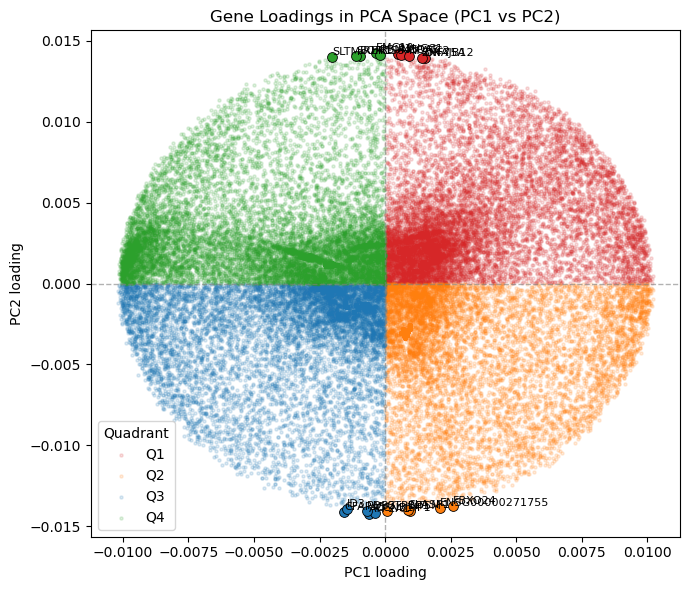

In [418]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Build loadings table: rows = genes, cols = PC1, PC2
# counts_num: (60675 genes × 60 samples), index = ENSG IDs used in PCA
genes = counts_num.index

loadings = pd.DataFrame({
    "PC1": pca.components_[0],   # shape = (n_genes,)
    "PC2": pca.components_[1],
}, index=genes)

# 2️⃣ Map ENSG → gene symbol (fallback to ENSG if no symbol)
ens_clean = loadings.index.str.split(".").str[0]

# ENSG -> symbol using your existing dict
symbols = ens_clean.to_series(index=loadings.index).map(ensg_to_symbol)

# Fallback: keep ENSG where symbol is missing
ens_clean_series = pd.Series(ens_clean, index=loadings.index)
symbols = symbols.fillna(ens_clean_series)

loadings["symbol"] = symbols

# 3️⃣ Assign quadrants in PC1–PC2 loading space
def assign_quadrant(row):
    pc1 = row["PC1"]
    pc2 = row["PC2"]
    if pc1 >= 0 and pc2 >= 0:
        return "Q1"   # PC1+, PC2+
    elif pc1 >= 0 and pc2 < 0:
        return "Q2"   # PC1+, PC2-
    elif pc1 < 0 and pc2 < 0:
        return "Q3"   # PC1-, PC2-
    else:
        return "Q4"   # PC1-, PC2+

loadings["quadrant"] = loadings[["PC1", "PC2"]].apply(assign_quadrant, axis=1)

# 4️⃣ Define a "strength" metric: distance from origin in PC1–PC2 space
loadings["strength"] = np.sqrt(loadings["PC1"]**2 + loadings["PC2"]**2)

# 5️⃣ Choose top genes per quadrant to label
label_genes = []
for q in ["Q1", "Q2", "Q3", "Q4"]:
    top_q = (
        loadings[loadings["quadrant"] == q]
        .sort_values("strength", ascending=False)
        .head(5)                    # change to 10 if you want more labels
        .index.tolist()
    )
    label_genes.extend(top_q)

# 6️⃣ Scatter plot
fig, ax = plt.subplots(figsize=(7, 6))

colors = {
    "Q1": "tab:red",     # PC1+, PC2+
    "Q2": "tab:orange",  # PC1+, PC2-
    "Q3": "tab:blue",    # PC1-, PC2-
    "Q4": "tab:green",   # PC1-, PC2+
}

# All genes as faint points
for q, df_q in loadings.groupby("quadrant"):
    ax.scatter(
        df_q["PC1"],
        df_q["PC2"],
        s=5,
        alpha=0.15,
        color=colors[q],
        label=q,
    )

# Highlight + label strongest genes in each quadrant
for gene_id in label_genes:
    row = loadings.loc[gene_id]
    ax.scatter(
        row["PC1"],
        row["PC2"],
        s=50,
        color=colors[row["quadrant"]],
        edgecolor="k",
        linewidth=0.6,
        zorder=3,
    )
    ax.text(
        row["PC1"],
        row["PC2"],
        row["symbol"],
        fontsize=8,
        ha="left",
        va="bottom",
        zorder=4,
    )

ax.axhline(0, color="grey", linewidth=1, linestyle="--", alpha=0.6)
ax.axvline(0, color="grey", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("PC1 loading")
ax.set_ylabel("PC2 loading")
ax.set_title("Gene Loadings in PCA Space (PC1 vs PC2)")
ax.legend(title="Quadrant", frameon=True)

plt.tight_layout()
plt.show()


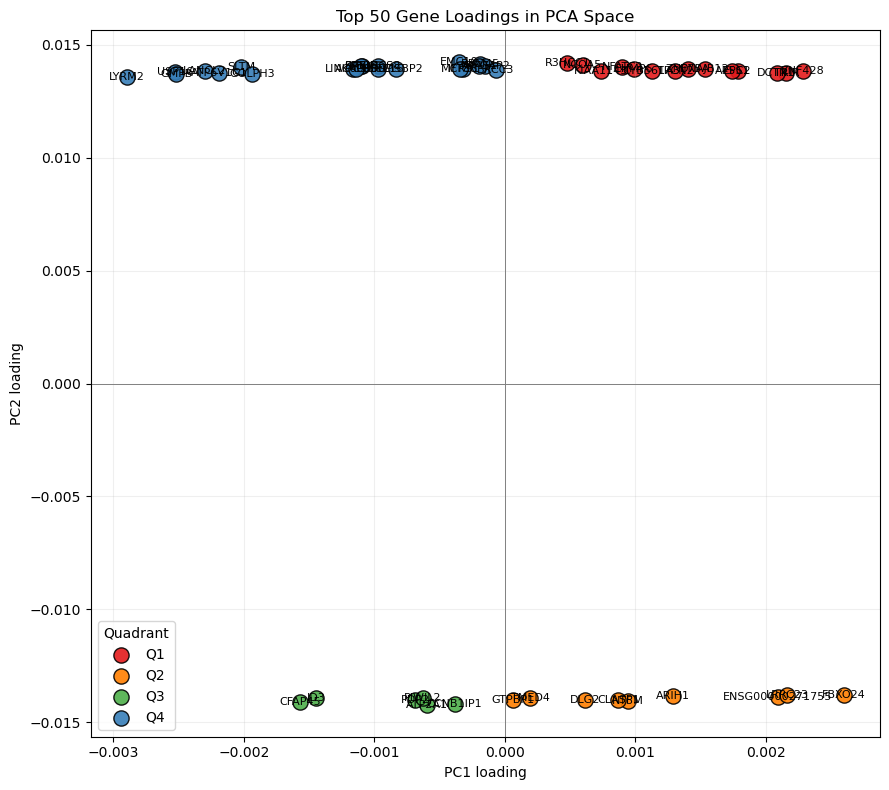

In [419]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Rebuild loadings dataframe (if not already defined)
# ------------------------------------------------------------
# loadings = pd.DataFrame({
#     "PC1": pca.components_[0],
#     "PC2": pca.components_[1]
# }, index=counts_num.index)

# If loadings_sym exists, use it. Otherwise use loadings.
if "loadings_sym" in globals():
    LOAD = loadings_sym.copy()
elif "loadings" in globals():
    LOAD = loadings.copy()
else:
    # Last resort: rebuild from PCA + counts_num
    LOAD = pd.DataFrame(
        {
            "PC1": pca.components_[0],
            "PC2": pca.components_[1],
        },
        index=counts_num.index,
    )

# ------------------------------------------------------------
# 1) Ensure we have a 'symbol' column
# ------------------------------------------------------------
if "symbol" not in LOAD.columns:
    if "ensg_to_symbol" in globals():
        # strip version suffix and map
        ens_clean_series = LOAD.index.to_series().str.split(".").str[0]
        symbols = ens_clean_series.map(ensg_to_symbol)
        symbols = symbols.fillna(ens_clean_series)  # keep ENSG if no symbol
        LOAD["symbol"] = symbols
    else:
        # fallback: just use index as label
        LOAD["symbol"] = LOAD.index.astype(str)

# ------------------------------------------------------------
# 2) Compute strength and quadrants
# ------------------------------------------------------------
LOAD["strength"] = np.sqrt(LOAD["PC1"]**2 + LOAD["PC2"]**2)

def assign_quadrant(row):
    if row["PC1"] >= 0 and row["PC2"] >= 0: return "Q1"
    if row["PC1"] >= 0 and row["PC2"] <  0: return "Q2"
    if row["PC1"] <  0 and row["PC2"] <  0: return "Q3"
    if row["PC1"] <  0 and row["PC2"] >= 0: return "Q4"

LOAD["quadrant"] = LOAD.apply(assign_quadrant, axis=1)

# ------------------------------------------------------------
# 3) Take top N genes by |loading|
# ------------------------------------------------------------
topN = 50
top_load = LOAD.nlargest(topN, "strength").copy()

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
colors = {"Q1": "#e41a1c", "Q2": "#ff7f00", "Q3": "#4daf4a", "Q4": "#377eb8"}

plt.figure(figsize=(9, 8))
plt.axhline(0, color="gray", lw=0.7)
plt.axvline(0, color="gray", lw=0.7)

for q, dfq in top_load.groupby("quadrant"):
    plt.scatter(
        dfq["PC1"],
        dfq["PC2"],
        s=120,
        color=colors[q],
        label=q,
        edgecolor="black",
        alpha=0.9,
    )
    for _, row in dfq.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            str(row["symbol"]),
            fontsize=8,
            ha="center",
            va="center",
        )

plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")
plt.title(f"Top {topN} Gene Loadings in PCA Space")
plt.legend(title="Quadrant")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

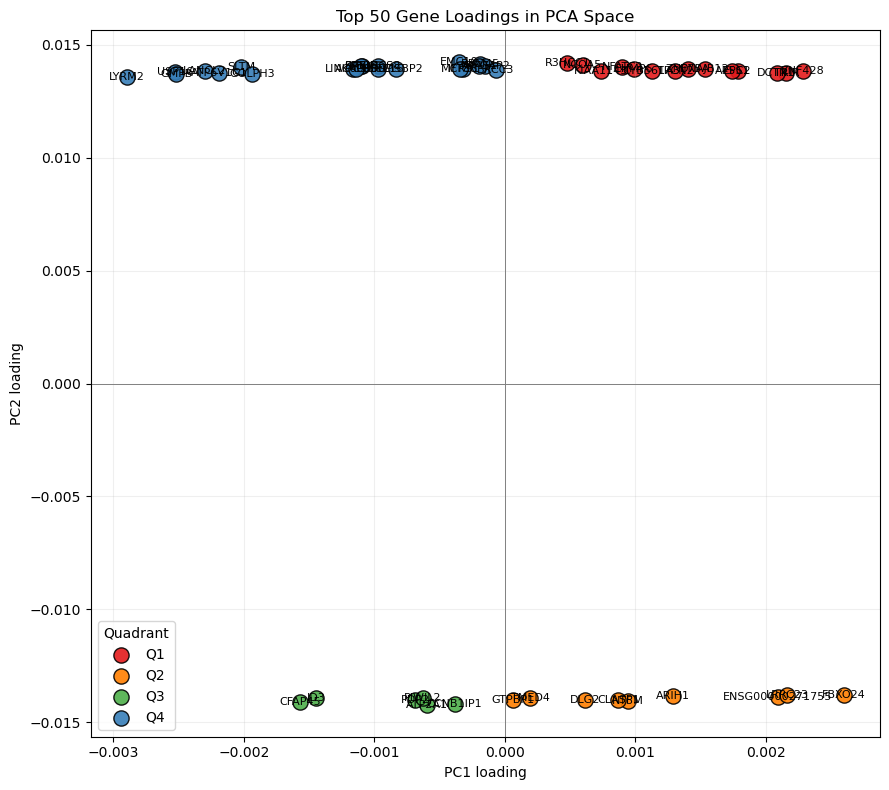

In [420]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Rebuild loadings dataframe (if not already defined)
# ------------------------------------------------------------
# loadings = pd.DataFrame({
#     "PC1": pca.components_[0],
#     "PC2": pca.components_[1]
# }, index=counts_num.index)

# If loadings_sym exists, use it. Otherwise use loadings.
if "loadings_sym" in globals():
    LOAD = loadings_sym.copy()
elif "loadings" in globals():
    LOAD = loadings.copy()
else:
    # Last resort: rebuild from PCA + counts_num
    LOAD = pd.DataFrame(
        {
            "PC1": pca.components_[0],
            "PC2": pca.components_[1],
        },
        index=counts_num.index,
    )

# ------------------------------------------------------------
# 1) Ensure we have a 'symbol' column
# ------------------------------------------------------------
if "symbol" not in LOAD.columns:
    if "ensg_to_symbol" in globals():
        # strip version suffix and map
        ens_clean_series = LOAD.index.to_series().str.split(".").str[0]
        symbols = ens_clean_series.map(ensg_to_symbol)
        symbols = symbols.fillna(ens_clean_series)  # keep ENSG if no symbol
        LOAD["symbol"] = symbols
    else:
        # fallback: just use index as label
        LOAD["symbol"] = LOAD.index.astype(str)

# ------------------------------------------------------------
# 2) Compute strength and quadrants
# ------------------------------------------------------------
LOAD["strength"] = np.sqrt(LOAD["PC1"]**2 + LOAD["PC2"]**2)

def assign_quadrant(row):
    if row["PC1"] >= 0 and row["PC2"] >= 0: return "Q1"
    if row["PC1"] >= 0 and row["PC2"] <  0: return "Q2"
    if row["PC1"] <  0 and row["PC2"] <  0: return "Q3"
    if row["PC1"] <  0 and row["PC2"] >= 0: return "Q4"

LOAD["quadrant"] = LOAD.apply(assign_quadrant, axis=1)

# ------------------------------------------------------------
# 3) Take top N genes by |loading|
# ------------------------------------------------------------
topN = 50
top_load = LOAD.nlargest(topN, "strength").copy()

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
colors = {"Q1": "#e41a1c", "Q2": "#ff7f00", "Q3": "#4daf4a", "Q4": "#377eb8"}

plt.figure(figsize=(9, 8))
plt.axhline(0, color="gray", lw=0.7)
plt.axvline(0, color="gray", lw=0.7)

for q, dfq in top_load.groupby("quadrant"):
    plt.scatter(
        dfq["PC1"],
        dfq["PC2"],
        s=120,
        color=colors[q],
        label=q,
        edgecolor="black",
        alpha=0.9,
    )
    for _, row in dfq.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            str(row["symbol"]),
            fontsize=8,
            ha="center",
            va="center",
        )

plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")
plt.title(f"Top {topN} Gene Loadings in PCA Space")
plt.legend(title="Quadrant")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [421]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# samples × genes
X = counts_num.T

scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)


In [422]:
print("X_pca:", X_pca.shape)        # (60, 2)
print("components:", pca.components_.shape)  # (2, 60675)


X_pca: (60, 2)
components: (2, 60675)


In [423]:
import pandas as pd
import numpy as np

# 60675 gene IDs in same order as counts_num rows
genes = counts_num.index

loadings_PC1 = pd.Series(pca.components_[0], index=genes, name="PC1")
loadings_PC2 = pd.Series(pca.components_[1], index=genes, name="PC2")

loadings = pd.concat([loadings_PC1, loadings_PC2], axis=1)
loadings.head()


,PC1,PC2
gene,,
ENSG00000223972,-8.988863e-04,4.619816e-03
ENSG00000227232,5.963678e-03,-6.779670e-04
ENSG00000278267,3.407486e-03,-3.700353e-03
ENSG00000243485,1.087098e-03,2.116643e-03
ENSG00000284332,-4.065310e-23,4.641549e-22


In [424]:
# quick sanity check
list(ensg_to_symbol.items())[:5]


[('ENSG00000210049', 'MT-TF'),
 ('ENSG00000211459', 'MT-RNR1'),
 ('ENSG00000210077', 'MT-TV'),
 ('ENSG00000210082', 'MT-RNR2'),
 ('ENSG00000209082', 'MT-TL1')]

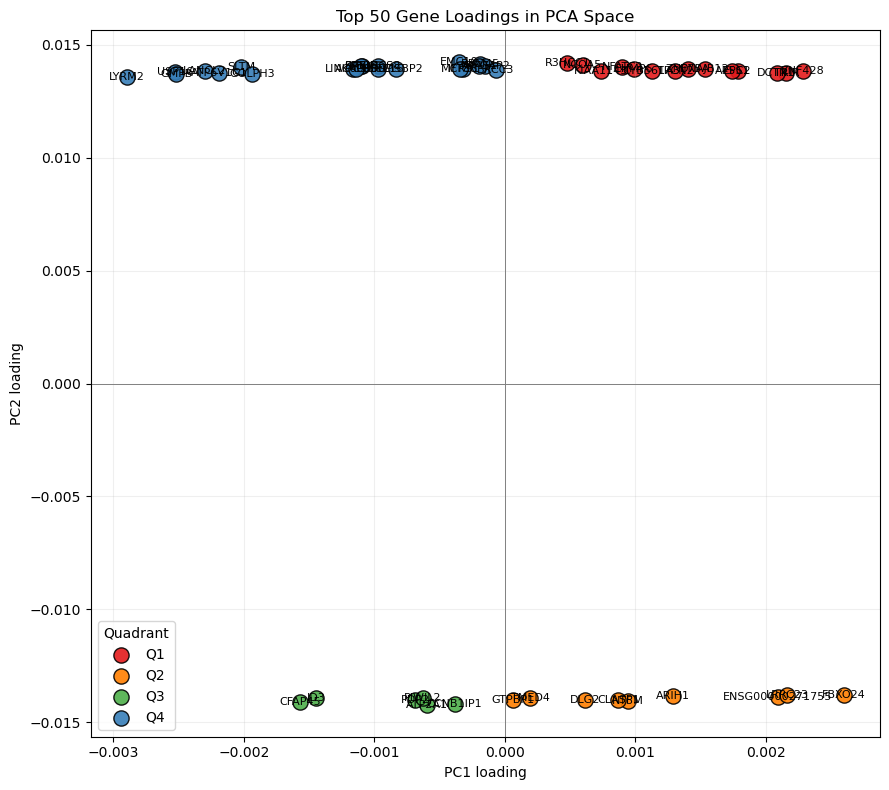

In [425]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Rebuild loadings dataframe (if not already defined)
# ------------------------------------------------------------
# loadings = pd.DataFrame({
#     "PC1": pca.components_[0],
#     "PC2": pca.components_[1]
# }, index=counts_num.index)

# If loadings_sym exists, use it. Otherwise use loadings.
if "loadings_sym" in globals():
    LOAD = loadings_sym.copy()
elif "loadings" in globals():
    LOAD = loadings.copy()
else:
    # Last resort: rebuild from PCA + counts_num
    LOAD = pd.DataFrame(
        {
            "PC1": pca.components_[0],
            "PC2": pca.components_[1],
        },
        index=counts_num.index,
    )

# ------------------------------------------------------------
# 1) Ensure we have a 'symbol' column
# ------------------------------------------------------------
if "symbol" not in LOAD.columns:
    if "ensg_to_symbol" in globals():
        # strip version suffix and map
        ens_clean_series = LOAD.index.to_series().str.split(".").str[0]
        symbols = ens_clean_series.map(ensg_to_symbol)
        symbols = symbols.fillna(ens_clean_series)  # keep ENSG if no symbol
        LOAD["symbol"] = symbols
    else:
        # fallback: just use index as label
        LOAD["symbol"] = LOAD.index.astype(str)

# ------------------------------------------------------------
# 2) Compute strength and quadrants
# ------------------------------------------------------------
LOAD["strength"] = np.sqrt(LOAD["PC1"]**2 + LOAD["PC2"]**2)

def assign_quadrant(row):
    if row["PC1"] >= 0 and row["PC2"] >= 0: return "Q1"
    if row["PC1"] >= 0 and row["PC2"] <  0: return "Q2"
    if row["PC1"] <  0 and row["PC2"] <  0: return "Q3"
    if row["PC1"] <  0 and row["PC2"] >= 0: return "Q4"

LOAD["quadrant"] = LOAD.apply(assign_quadrant, axis=1)

# ------------------------------------------------------------
# 3) Take top N genes by |loading|
# ------------------------------------------------------------
topN = 50
top_load = LOAD.nlargest(topN, "strength").copy()

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
colors = {"Q1": "#e41a1c", "Q2": "#ff7f00", "Q3": "#4daf4a", "Q4": "#377eb8"}

plt.figure(figsize=(9, 8))
plt.axhline(0, color="gray", lw=0.7)
plt.axvline(0, color="gray", lw=0.7)

for q, dfq in top_load.groupby("quadrant"):
    plt.scatter(
        dfq["PC1"],
        dfq["PC2"],
        s=120,
        color=colors[q],
        label=q,
        edgecolor="black",
        alpha=0.9,
    )
    for _, row in dfq.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            str(row["symbol"]),
            fontsize=8,
            ha="center",
            va="center",
        )

plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")
plt.title(f"Top {topN} Gene Loadings in PCA Space")
plt.legend(title="Quadrant")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

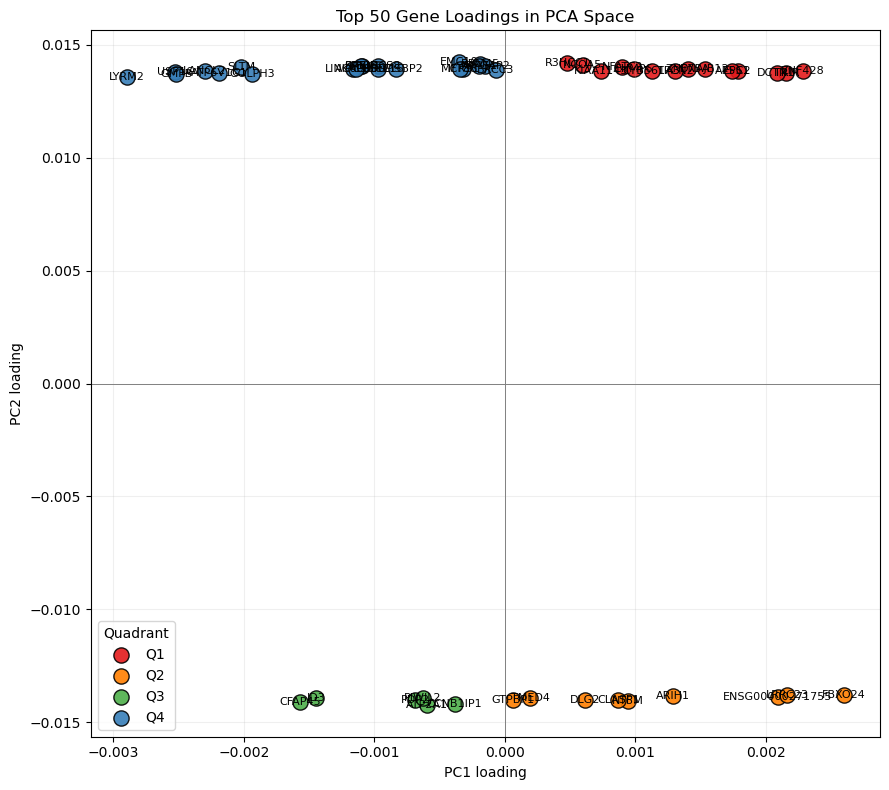

In [426]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Rebuild loadings dataframe (if not already defined)
# ------------------------------------------------------------
# loadings = pd.DataFrame({
#     "PC1": pca.components_[0],
#     "PC2": pca.components_[1]
# }, index=counts_num.index)

# If loadings_sym exists, use it. Otherwise use loadings.
if "loadings_sym" in globals():
    LOAD = loadings_sym.copy()
elif "loadings" in globals():
    LOAD = loadings.copy()
else:
    # Last resort: rebuild from PCA + counts_num
    LOAD = pd.DataFrame(
        {
            "PC1": pca.components_[0],
            "PC2": pca.components_[1],
        },
        index=counts_num.index,
    )

# ------------------------------------------------------------
# 1) Ensure we have a 'symbol' column
# ------------------------------------------------------------
if "symbol" not in LOAD.columns:
    if "ensg_to_symbol" in globals():
        # strip version suffix and map
        ens_clean_series = LOAD.index.to_series().str.split(".").str[0]
        symbols = ens_clean_series.map(ensg_to_symbol)
        symbols = symbols.fillna(ens_clean_series)  # keep ENSG if no symbol
        LOAD["symbol"] = symbols
    else:
        # fallback: just use index as label
        LOAD["symbol"] = LOAD.index.astype(str)

# ------------------------------------------------------------
# 2) Compute strength and quadrants
# ------------------------------------------------------------
LOAD["strength"] = np.sqrt(LOAD["PC1"]**2 + LOAD["PC2"]**2)

def assign_quadrant(row):
    if row["PC1"] >= 0 and row["PC2"] >= 0: return "Q1"
    if row["PC1"] >= 0 and row["PC2"] <  0: return "Q2"
    if row["PC1"] <  0 and row["PC2"] <  0: return "Q3"
    if row["PC1"] <  0 and row["PC2"] >= 0: return "Q4"

LOAD["quadrant"] = LOAD.apply(assign_quadrant, axis=1)

# ------------------------------------------------------------
# 3) Take top N genes by |loading|
# ------------------------------------------------------------
topN = 50
top_load = LOAD.nlargest(topN, "strength").copy()
plt.figure(figsize=(12, 10))

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
colors = {"Q1": "#e41a1c", "Q2": "#ff7f00", "Q3": "#4daf4a", "Q4": "#377eb8"}

plt.figure(figsize=(9, 8))
plt.axhline(0, color="gray", lw=0.7)
plt.axvline(0, color="gray", lw=0.7)

for q, dfq in top_load.groupby("quadrant"):
    plt.scatter(
        dfq["PC1"],
        dfq["PC2"],
        s=120,
        color=colors[q],
        label=q,
        edgecolor="black",
        alpha=0.9,
    )
    for _, row in dfq.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            str(row["symbol"]),
            fontsize=8,
            ha="center",
            va="center",
        )

plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")
plt.title(f"Top {topN} Gene Loadings in PCA Space")
plt.legend(title="Quadrant")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [427]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

try:
    import umap
except ImportError:
    # install once if needed
    !pip install umap-learn
    import umap

# Reload processed data (if not already in memory)
expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")
metadata    = pd.read_csv("data/processed/metadata_samples.csv", index_col=0)

# Make sure sample indices match
expr_logcpm = expr_logcpm.loc[:, metadata.index]


In [428]:
# ---- B) UMAP on genes (top variable genes) ----

# variance across samples
gene_var = expr_logcpm.var(axis=1)
top_genes = gene_var.sort_values(ascending=False).head(1000).index  # you can change 1000

X_genes = expr_logcpm.loc[top_genes]      # genes × samples

scaler_genes = StandardScaler(with_mean=True, with_std=True)
X_genes_scaled = scaler_genes.fit_transform(X_genes)

umap_genes = umap.UMAP(
    n_neighbors=15,
    min_dist=0.3,
    metric="cosine",
    random_state=0
)
X_umap_genes = umap_genes.fit_transform(X_genes_scaled)

umap_genes_df = pd.DataFrame(
    X_umap_genes,
    index=top_genes,
    columns=["UMAP1", "UMAP2"]
)


/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [429]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt

# -------------------------
# 1) Build the gene-level matrix X_genes
# -------------------------
# X_scaled is your samples × genes matrix after StandardScaler
# (We flip it so genes are the rows)
X_genes = X_scaled.T     # shape: 60675 genes × 60 samples

# -------------------------
# 2) Gene-level UMAP embedding
# -------------------------
umap_gene = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
umap_genes = umap_gene.fit_transform(X_genes)   # (genes × 2)

# Create dataframe
umap_genes_df = pd.DataFrame(
    umap_genes, 
    columns=["UMAP1", "UMAP2"],
    index=expr_symbol.index  # gene symbols or ENSGs
)

# -------------------------
# 3) If loadings contain quadrant labels, attach them
# -------------------------
if "quadrant" in loadings.columns:
    umap_genes_df = umap_genes_df.join(loadings["quadrant"], how="left")
else:
    umap_genes_df["quadrant"] = np.nan

# -------------------------
# 4) Plot UMAP with quadrants
# -------------------------
plt.figure(figsize=(8,6))

for q, color in zip(["Q1","Q2","Q3","Q4"],
                    ["red","orange","green","blue"]):
    mask = umap_genes_df["quadrant"] == q
    plt.scatter(
        umap_genes_df.loc[mask, "UMAP1"],
        umap_genes_df.loc[mask, "UMAP2"],
        s=5, alpha=0.5, color=color, label=q
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Gene-level UMAP colored by PCA quadrants")
plt.legend()
plt.show()


/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: Shape of passed values is (60675, 2), indices imply (41250, 2)

In [ ]:
# If loadings has index = ENSG and column "quadrant"
if "quadrant" in loadings.columns:
    umap_genes_df = umap_genes_df.join(loadings["quadrant"], how="left")
else:
    umap_genes_df["quadrant"] = np.nan


In [ ]:
plt.figure(figsize=(6,5))
quad_colors = {"Q1": "tab:red", "Q2": "tab:orange", "Q3": "tab:green", "Q4": "tab:blue"}

for q, dfq in umap_genes_df.groupby("quadrant"):
    color = quad_colors.get(q, "lightgrey")
    label = q if pd.notnull(q) else "unassigned"
    plt.scatter(
        dfq["UMAP1"],
        dfq["UMAP2"],
        s=10, alpha=0.7,
        label=label,
        c=color
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of top variable genes")
plt.legend(title="Quadrant", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# ---- C) Trajectory overlay in UMAP space ----

# Compute centroids per (guide, timepoint)
centroids = (
    umap_samp_df
    .groupby(["guide", "timepoint"])[["UMAP1", "UMAP2"]]
    .mean()
    .reset_index()
)

# Define time ordering (adjust if your labels differ)
time_order = ["0h", "24h", "48h", "72h", "168hplus"]
# Fallback: if some are missing, keep only those present
time_order = [t for t in time_order if t in centroids["timepoint"].unique()]

plt.figure(figsize=(7,6))

# Background: all samples faint
plt.scatter(
    umap_samp_df["UMAP1"],
    umap_samp_df["UMAP2"],
    s=20, alpha=0.2, color="lightgrey"
)

colors = {"SafeHarbor": "tab:blue", "RHOG": "tab:orange"}

for guide, col in colors.items():
    df_g = centroids[centroids["guide"] == guide].copy()
    df_g = df_g.set_index("timepoint").loc[time_order].dropna()

    plt.plot(df_g["UMAP1"], df_g["UMAP2"],
             "-o", color=col, linewidth=2, markersize=7, label=guide)

    # label each timepoint
    for t, (x, y) in df_g[["UMAP1", "UMAP2"]].iterrows():
        plt.text(x, y, t,
                 fontsize=8,
                 ha="center", va="bottom",
                 color=col)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP trajectories – RHOG vs SafeHarbor over time")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("Have loadings?", "loadings" in globals())
if "loadings" in globals():
    print(loadings.shape)
    print(loadings.head())


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 2.1 Map ENSG → symbol (if not already done) ---
if "symbol" not in loadings.columns:
    ens_clean = loadings.index.str.split(".").str[0]
    symbols = ens_clean.to_series().map(ensg_to_symbol)
    symbols = symbols.fillna(ens_clean.to_series())  # keep ENSG where no symbol
    loadings["symbol"] = symbols

# --- 2.2 Assign quadrants (PC1 vs PC2) ---

def assign_quadrant(row):
    if row["PC1"] > 0 and row["PC2"] > 0:
        return "Q1"
    elif row["PC1"] < 0 and row["PC2"] > 0:
        return "Q2"
    elif row["PC1"] < 0 and row["PC2"] < 0:
        return "Q3"
    else:
        return "Q4"

loadings["quadrant"] = loadings[["PC1", "PC2"]].apply(assign_quadrant, axis=1)

# --- 2.3 Strength of loading = distance from origin ---

loadings["strength"] = np.sqrt(loadings["PC1"]**2 + loadings["PC2"]**2)

# --- 2.4 Top 10 genes per quadrant by strength ---

top_per_quad = (
    loadings
    .sort_values("strength", ascending=False)
    .groupby("quadrant")
    .head(10)
)
top_per_quad.head()


In [ ]:
# Cytotoxic signature to highlight
cyto_markers = {
    "GZMB", "GZMH", "GZMK",
    "PRF1", "GNLY", "NKG7",
    "IFNG", "CX3CR1"
}

loadings["is_cytotoxic"] = loadings["symbol"].isin(cyto_markers)

fig, ax = plt.subplots(figsize=(7, 7))

# All genes as gray background cloud
ax.scatter(
    loadings["PC1"], loadings["PC2"],
    s=4, color="lightgray", alpha=0.25, linewidths=0
)

# Axes
ax.axvline(0, color="gray", lw=1, alpha=0.7)
ax.axhline(0, color="gray", lw=1, alpha=0.7)

# Bounds for quadrant shading & text placement
x_min, x_max = loadings["PC1"].min(), loadings["PC1"].max()
y_min, y_max = loadings["PC2"].min(), loadings["PC2"].max()
x_mid = 0.0
y_mid = 0.0

# Very light quadrant shading
ax.axvspan(0, x_max, 0, 1, alpha=0.03, color="gold")
ax.axvspan(x_min, 0, 0, 1, alpha=0.03, color="lightblue")
ax.axhspan(0, y_max, x_min, x_max, alpha=0.03, color="lightgreen")
ax.axhspan(y_min, 0, x_min, x_max, alpha=0.03, color="plum")

# Colors per quadrant
q_colors = {"Q1": "tab:red", "Q2": "tab:orange",
            "Q3": "tab:green", "Q4": "tab:blue"}

# Plot + label top genes per quadrant
for q, dfq in top_per_quad.groupby("quadrant"):
    ax.scatter(
        dfq["PC1"], dfq["PC2"],
        s=60, color=q_colors[q],
        edgecolor="k", label=f"{q} top genes"
    )
    for _, row in dfq.iterrows():
        ax.text(
            row["PC1"], row["PC2"],
            row["symbol"],
            fontsize=7,
            ha="center", va="center"
        )

# Cytotoxic markers, wherever they fall
cyto_df = loadings[loadings["is_cytotoxic"]]
if not cyto_df.empty:
    ax.scatter(
        cyto_df["PC1"], cyto_df["PC2"],
        s=80, facecolors="none", edgecolors="black",
        linewidths=1.5, label="Cytotoxic markers"
    )
    for _, row in cyto_df.iterrows():
        ax.text(
            row["PC1"], row["PC2"],
            row["symbol"],
            fontsize=8, fontweight="bold",
            ha="center", va="center"
        )

# Biological quadrant labels (using fixed offsets so they don’t depend on exact bounds)
x_span = x_max - x_min
y_span = y_max - y_min

ax.text(x_mid + 0.35 * x_span, y_mid + 0.35 * y_span,
        "Q1: IFN-high / stress", fontsize=10,
        ha="center", va="bottom")

ax.text(x_mid - 0.35 * x_span, y_mid + 0.35 * y_span,
        "Q2: Effector / IL2–STAT5\nInflammatory programs",
        fontsize=10, ha="center", va="bottom")

ax.text(x_mid - 0.35 * x_span, y_mid - 0.35 * y_span,
        "Q3: Proliferative / E2F\nOxPhos-compatible",
        fontsize=10, ha="center", va="top")

ax.text(x_mid + 0.35 * x_span, y_mid - 0.35 * y_span,
        "Q4: IFN-low metabolic\nadaptation",
        fontsize=10, ha="center", va="top")

ax.set_xlabel("PC1 loading")
ax.set_ylabel("PC2 loading")
ax.set_title("Top PC1/PC2 Gene Loadings with Cytotoxic Markers")
ax.legend(frameon=True, fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()


In [ ]:
# UMAP on samples (HVGs, RHOG vs SafeHarbor + time)
import numpy as np
import pandas as pd
import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1) Start from counts: genes x samples
# counts_num: DataFrame (60675 genes × 60 samples)
print(counts_num.shape)

# 2) Log-transform
log_counts = np.log1p(counts_num)

# 3) Select highly variable genes (top 2000 by variance)
gene_var = log_counts.var(axis=1)
hvg = gene_var.sort_values(ascending=False).head(2000).index
log_hvg = log_counts.loc[hvg]

# 4) Make sample matrix: samples × genes
X_samples = log_hvg.T    # (n_samples, 2000)

# 5) Scale features
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X_samples)

# 6) Run UMAP on samples
umap_samples = umap.UMAP(
    n_neighbors=10,
    min_dist=0.3,
    metric="euclidean",
    random_state=42
)
X_umap_samples = umap_samples.fit_transform(X_scaled)

umap_df = pd.DataFrame(
    X_umap_samples,
    index=X_samples.index,
    columns=["UMAP1", "UMAP2"]
)

# ---- Robustly attach metadata ----
print("Metadata columns:", list(metadata.columns))

possible_time_cols  = ["timepoint", "time", "Time", "tp"]
possible_guide_cols = ["guide", "perturbation", "condition", "Guide"]

time_col  = next((c for c in possible_time_cols  if c in metadata.columns), None)
guide_col = next((c for c in possible_guide_cols if c in metadata.columns), None)

cols_to_add = []
if time_col:
    cols_to_add.append(time_col)
if guide_col:
    cols_to_add.append(guide_col)

if cols_to_add:
    umap_df = umap_df.join(metadata[cols_to_add], how="left")
else:
    print("⚠️ No matching time/guide columns found in metadata; joining metadata as-is.")
    umap_df = umap_df.join(metadata, how="left")

print("UMAP+metadata head:")
print(umap_df.head())


In [ ]:
if time_col is not None:
    plt.figure(figsize=(6,5))
    for tp in sorted(umap_df[time_col].dropna().unique()):
        m = umap_df[time_col] == tp
        plt.scatter(umap_df.loc[m, "UMAP1"], umap_df.loc[m, "UMAP2"],
                    s=50, alpha=0.8, label=str(tp))
    plt.legend(title=time_col)
    plt.title("Sample UMAP – colored by " + time_col)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.grid(alpha=0.2)
    plt.show()
else:
    print("No time-like column found; skipping timepoint-colored UMAP.")


In [ ]:
if guide_col is not None:
    plt.figure(figsize=(6,5))
    for g in sorted(umap_df[guide_col].dropna().unique()):
        m = umap_df[guide_col] == g
        plt.scatter(umap_df.loc[m, "UMAP1"], umap_df.loc[m, "UMAP2"],
                    s=70, alpha=0.85, edgecolor="k", label=str(g))
    plt.legend(title=guide_col)
    plt.title("Sample UMAP – " + guide_col)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.grid(alpha=0.2)
    plt.show()
else:
    print("No guide/condition-like column found; skipping guide-colored UMAP.")


In [ ]:
# X_samples: (60 samples × 60675 genes), used to fit UMAP
# X_umap_samples: result of umap_samples.fit_transform(X_samples)

umap_df = pd.DataFrame(
    X_umap_samples,
    index=X_samples.index,
    columns=["UMAP1", "UMAP2"]
)

# Bring in metadata: hours, guide, donor
umap_df = umap_df.join(metadata[["hours", "guide", "donor"]], how="left")

print("UMAP+metadata head:")
print(umap_df.head())


In [ ]:
plt.figure(figsize=(6,5))

for t in sorted(umap_df["hours"].unique()):
    mask = umap_df["hours"] == t
    plt.scatter(
        umap_df.loc[mask, "UMAP1"],
        umap_df.loc[mask, "UMAP2"],
        s=70, alpha=0.85, edgecolor="k",
        label=f"{t} h"
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Sample UMAP – timepoint")
plt.legend(title="hours", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,5))

for g in umap_df["guide"].unique():
    mask = umap_df["guide"] == g
    plt.scatter(
        umap_df.loc[mask, "UMAP1"],
        umap_df.loc[mask, "UMAP2"],
        s=70, alpha=0.85, edgecolor="k",
        label=g
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Sample UMAP – guide")
plt.legend(title="guide", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,5))

for d in umap_df["donor"].unique():
    mask = umap_df["donor"] == d
    plt.scatter(
        umap_df.loc[mask, "UMAP1"],
        umap_df.loc[mask, "UMAP2"],
        s=70, alpha=0.85, edgecolor="k",
        label=d
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Sample UMAP – donor")
plt.legend(title="donor", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
#Gene-level UMAP (variable genes)import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap

# 1) Choose expression matrix
# If you already have a logCPM or log1p matrix, use that instead.
# Here I'll assume 'counts_num' is raw counts (genes x samples).
expr = counts_num.copy()                 # shape ~ (60675, 60)
expr_log = np.log1p(expr)                # log1p to stabilize variance

# 2) Keep top variable genes (e.g. 3000)
gene_var = expr_log.var(axis=1)
var_genes = gene_var.sort_values(ascending=False).head(3000).index
expr_var = expr_log.loc[var_genes]       # (3000 genes x 60 samples)

print("Variable matrix:", expr_var.shape)

# 3) Prepare for UMAP: genes as rows, samples as features
X_genes = expr_var.values                # (n_genes, n_samples)

scaler_genes = StandardScaler(with_mean=True, with_std=True)
X_genes_scaled = scaler_genes.fit_transform(X_genes)

# 4) UMAP on genes
umap_genes = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    metric="cosine",
    random_state=42
)

X_umap_genes = umap_genes.fit_transform(X_genes_scaled)

# 5) Put into a DataFrame
umap_genes_df = pd.DataFrame(
    X_umap_genes,
    index=expr_var.index,
    columns=["UMAP1", "UMAP2"]
)

umap_genes_df.head()


In [ ]:
# Add gene symbols to the gene-UMAP
# ensg_to_symbol dict should already exist from earlier
ens_clean_series = umap_genes_df.index.to_series().str.split(".").str[0]
symbols = ens_clean_series.map(ensg_to_symbol).fillna(ens_clean_series)

umap_genes_df["symbol"] = symbols

# Quick sanity check plot: all genes in grey
plt.figure(figsize=(6,5))
plt.scatter(umap_genes_df["UMAP1"], umap_genes_df["UMAP2"],
            s=5, c="lightgrey", alpha=0.5)
plt.xlabel("Gene UMAP1")
plt.ylabel("Gene UMAP2")
plt.title("Gene-level UMAP (all variable genes)")
plt.tight_layout()
plt.show()


In [ ]:
#Overlay PC1 / PC2 quadrants on gene-
# 1) Rebuild loadings from your PCA (pca over samples x genes)

# X_samples should be the same matrix used for PCA earlier:
# X_samples = counts_num.T  (60 samples x 60675 genes)
# Make sure its columns order matches counts_num.index.

X_samples = counts_num.T
genes_full = X_samples.columns          # ENSGs (+version)

# PC1 & PC2 loadings (one value per gene)
loadings_PC1 = pd.Series(pca.components_[0], index=genes_full, name="PC1")
loadings_PC2 = pd.Series(pca.components_[1], index=genes_full, name="PC2")

loadings = pd.concat([loadings_PC1, loadings_PC2], axis=1)

# 2) Restrict loadings to the same variable genes used for UMAP
loadings = loadings.loc[var_genes]

# 3) Attach to UMAP DataFrame (indices are ENSG)
umap_genes_df = umap_genes_df.join(loadings, how="left")

# 4) Quadrant + strength
def assign_quadrant(row):
    if row["PC1"] >= 0 and row["PC2"] >= 0:
        return "Q1"   # PC1+, PC2+
    elif row["PC1"] < 0 and row["PC2"] >= 0:
        return "Q2"   # PC1-, PC2+
    elif row["PC1"] < 0 and row["PC2"] < 0:
        return "Q3"   # PC1-, PC2-
    else:
        return "Q4"   # PC1+, PC2-

umap_genes_df["quadrant"] = umap_genes_df[["PC1","PC2"]].apply(assign_quadrant, axis=1)
umap_genes_df["strength"] = np.sqrt(umap_genes_df["PC1"]**2 + umap_genes_df["PC2"]**2)

# 5) Top N strongest genes per quadrant
topN = 10
top_per_quad = (
    umap_genes_df.dropna(subset=["strength"])
    .sort_values("strength", ascending=False)
    .groupby("quadrant")
    .head(topN)
)

top_genes = top_per_quad.index

# 6) Plot: background + top PCs overlaid
colors = {"Q1": "tab:red", "Q2": "tab:orange", "Q3": "tab:green", "Q4": "tab:blue"}

plt.figure(figsize=(7,6))

# background genes
bg_mask = ~umap_genes_df.index.isin(top_genes)
plt.scatter(
    umap_genes_df.loc[bg_mask, "UMAP1"],
    umap_genes_df.loc[bg_mask, "UMAP2"],
    s=5, c="lightgrey", alpha=0.25, label="_nolegend_"
)

# top per quadrant
for quad, sub in top_per_quad.groupby("quadrant"):
    plt.scatter(
        sub["UMAP1"], sub["UMAP2"],
        s=70, c=colors.get(quad, "black"),
        edgecolor="k", alpha=0.9, label=f"{quad} top genes"
    )
    for _, row in sub.iterrows():
        plt.text(
            row["UMAP1"], row["UMAP2"],
            row["symbol"],
            fontsize=8, ha="center", va="center"
        )

plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)

plt.xlabel("Gene UMAP1")
plt.ylabel("Gene UMAP2")
plt.title("Gene-level UMAP with top PC1/PC2 quadrant genes")
plt.legend(frameon=True, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
cyto_genes = ["GZMB", "PRF1", "GNLY", "NKG7", "IFNG", "FGFBP2", "CTSW"]

cyto_mask = umap_genes_df["symbol"].isin(cyto_genes)

plt.figure(figsize=(7,6))

# background
plt.scatter(
    umap_genes_df["UMAP1"],
    umap_genes_df["UMAP2"],
    s=5, c="lightgrey", alpha=0.25, label="_nolegend_"
)

# cytotoxic
sub = umap_genes_df.loc[cyto_mask]
plt.scatter(
    sub["UMAP1"], sub["UMAP2"],
    s=120, c="purple", edgecolor="k", label="Cytotoxic markers"
)
for _, row in sub.iterrows():
    plt.text(row["UMAP1"], row["UMAP2"], row["symbol"],
             fontsize=9, ha="center", va="center")

plt.xlabel("Gene UMAP1")
plt.ylabel("Gene UMAP2")
plt.title("Gene-level UMAP – cytotoxic markers overlay")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


In [430]:
# hallmark_sets is a dict: {term: [genesymbol1, genesymbol2, ...]}

# pick two interesting modules
ifn_genes = set(hallmark_sets["Interferon Gamma Response"]) | \
            set(hallmark_sets["Interferon Alpha Response"])
oxphos_genes = set(hallmark_sets["Oxidative Phosphorylation"])

umap_genes_df["IFN_module"] = umap_genes_df["symbol"].isin(ifn_genes)
umap_genes_df["OxPhos_module"] = umap_genes_df["symbol"].isin(oxphos_genes)

plt.figure(figsize=(7,6))

# background
plt.scatter(
    umap_genes_df["UMAP1"],
    umap_genes_df["UMAP2"],
    s=5, c="lightgrey", alpha=0.2, label="_nolegend_"
)

# IFN module
sub_ifn = umap_genes_df[umap_genes_df["IFN_module"]]
plt.scatter(
    sub_ifn["UMAP1"], sub_ifn["UMAP2"],
    s=40, c="dodgerblue", alpha=0.9, label="IFN modules"
)

# OxPhos module
sub_ox = umap_genes_df[umap_genes_df["OxPhos_module"]]
plt.scatter(
    sub_ox["UMAP1"], sub_ox["UMAP2"],
    s=40, c="gold", alpha=0.9, label="OxPhos"
)

plt.xlabel("Gene UMAP1")
plt.ylabel("Gene UMAP2")
plt.title("Gene-level UMAP – IFN vs OxPhos hallmark modules")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


KeyError: 'symbol'

In [ ]:
import seaborn as sns

sns.kdeplot(
    x=umap_genes_df["UMAP1"],
    y=umap_genes_df["UMAP2"],
    fill=True, cmap="Greys", alpha=0.2, levels=20
)


In [ ]:
import pandas as pd
import numpy as np

de = pd.read_csv("results/de/de_late_vs_early.csv", index_col=0)

In [ ]:
#Volcano plots figure (Figure 3# final project)
import numpy as np
import matplotlib.pyplot as plt

# thresholds
fc_thr = 0.5
fdr_thr = 0.2

df = de.copy()
df["neglog10FDR"] = -np.log10(df["FDR"])

# select top genes for labeling
top_up = (
    df.query("log2FC > @fc_thr and FDR < @fdr_thr")
      .sort_values("FDR")
      .head(10)
)

top_down = (
    df.query("log2FC < -@fc_thr and FDR < @fdr_thr")
      .sort_values("FDR")
      .head(10)
)

fig, ax = plt.subplots(figsize=(7, 7))

# background
ax.scatter(
    df["log2FC"],
    df["neglog10FDR"],
    c="lightgray",
    s=10,
    alpha=0.6
)

# thresholds
ax.axvline(fc_thr, ls="--", c="red", lw=1)
ax.axvline(-fc_thr, ls="--", c="red", lw=1)
ax.axhline(-np.log10(fdr_thr), ls="--", c="blue", lw=1)

# label genes
for _, r in pd.concat([top_up, top_down]).iterrows():
    ax.text(
        r["log2FC"],
        r["neglog10FDR"],
        r["gene"],   # or symbol
        fontsize=8
    )

ax.set_xlabel("log2 fold-change (Late vs Early)")
ax.set_ylabel("-log10(FDR)")
ax.set_title("Volcano — Late vs Early (Top Genes Labeled)")

fig.tight_layout()

out = "figures/fig3_DE_pathways/Fig3B_volcano_labeled.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out)